# Основы биостатистики с Python: разбор основных концепций и кейсов




## **Кейс №1**

### Препарат Х, снижающий уровень гликемии



Библиотеки:

In [1]:
import pandas as pd
import numpy as np
from itertools import product
from math import ceil
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import norm, t as t_dist, nct
from scipy.optimize import brentq     # root-finder
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

import missingno as msno

Константы:

In [2]:
RS = 1000

# **Планирование исследования**
---

In [3]:
###############################################################################
# 0. UNIVERSAL HELPER FUNCTIONS                                               #
###############################################################################

def conv_d_to_r(d: np.ndarray | float) -> np.ndarray | float:
    """
    Convert Cohen's d to Pearson's r.
    """
    return d / np.sqrt(d**2 + 4)


def conv_r_to_d(r: np.ndarray | float) -> np.ndarray | float:
    """
    Convert Pearson's r to Cohen's d.
    """
    return 2 * r / np.sqrt(1 - r**2)


def conv_d_to_or(d: np.ndarray | float) -> np.ndarray | float:
    """
    Convert Cohen's d to an odds ratio (OR).
    """
    return np.exp(np.pi / np.sqrt(3) * d)


def conv_or_to_d(or_: np.ndarray | float) -> np.ndarray | float:
    """
    Convert an odds ratio (OR) to Cohen's d.
    """
    return np.log(or_) * np.sqrt(3) / np.pi


def zcrit(conf: float = 0.95) -> float:
    """
    Two-tailed critical z value for a given confidence level.
    """
    return norm.ppf(1 - (1 - conf) / 2)


###############################################################################
# Fisher-Z confidence interval for Pearson's r                                #
###############################################################################

def r_ci(r: float | np.ndarray, n: int, conf: float = 0.95) -> dict:
    """
    Fisher Z-transformed confidence interval for Pearson's r.
    
    Parameters
    ----------
    r    : correlation coefficient (scalar or array)
    n    : sample size
    conf : confidence level (default 0.95)
    
    Returns
    -------
    dict with keys 'lo' and 'hi'
    """
    z      = 0.5 * np.log((1 + r) / (1 - r))
    se     = 1 / np.sqrt(n - 3)
    zc     = zcrit(conf)
    
    lo_z   = z - zc * se
    hi_z   = z + zc * se
    
    lo_r   = (np.exp(2 * lo_z) - 1) / (np.exp(2 * lo_z) + 1)
    hi_r   = (np.exp(2 * hi_z) - 1) / (np.exp(2 * hi_z) + 1)
    
    return {"lo": lo_r, "hi": hi_r}


###############################################################################
# Log-ratio (OR / RR) Wald confidence interval                                #
###############################################################################

def ratio_ci(est: float | np.ndarray,
             se: float | np.ndarray,
             conf: float = 0.95) -> dict:
    """
    Wald confidence interval for a ratio measure (OR or RR).
    
    Parameters
    ----------
    est  : point estimate of the ratio (e.g., odds ratio)
    se   : standard error of log(est)
    conf : confidence level (default 0.95)
    
    Returns
    -------
    dict with keys 'lo' and 'hi'
    """
    zc = zcrit(conf)
    lo = np.exp(np.log(est) - zc * se)
    hi = np.exp(np.log(est) + zc * se)
    return {"lo": lo, "hi": hi}

###############################################################################
# Cohen's D for 2 groups (independent / paired) from known mean, sd, n        #
###############################################################################

def cohens_d(mean1, mean2,
             sd1, sd2,
             n1, n2=None,
             *,
             paired=False,
             r=None,          # required for paired if sd_diff not supplied
             sd_diff=None,    # supply if you already have SD of differences
             conf_level=.95,
             ci_method="wald"   # "wald" | "none"   (can add "exact" later)
             ):
    """
    Cohen's d for independent or paired samples + Wald confidence interval.
    
    Returns
    -------
    dict with keys: {'d', 'ci_low', 'ci_high'}
    """

    # ------------------------------------------------------------------ #
    # 1. Point estimate                                                  #
    # ------------------------------------------------------------------ #
    if not paired:                               # Independent groups
        if n2 is None:
            raise ValueError("Need n2 for independent samples.")
        # pooled SD
        s_pooled = np.sqrt(((n1 - 1) * sd1**2 + (n2 - 1) * sd2**2)
                           / (n1 + n2 - 2))
        d = (mean1 - mean2) / s_pooled
    else:                                        # Paired / repeated
        if sd_diff is None:
            if r is None:
                raise ValueError("Need either `sd_diff` or correlation `r` "
                                 "for paired samples.")
            sd_diff = np.sqrt(sd1**2 + sd2**2 - 2 * r * sd1 * sd2)
        d = (mean1 - mean2) / sd_diff
        n2 = n1                                  # for consistency later

    # ------------------------------------------------------------------ #
    # 2. Standard error & Wald CI                                         #
    # ------------------------------------------------------------------ #
    if ci_method.lower() == "none":
        return {"d": d, "ci_low": np.nan, "ci_high": np.nan}

    z = norm.ppf(1 - (1 - conf_level) / 2)

    if not paired:
        # Hedges & Olkin (1985) variance of d
        se_d = np.sqrt((n1 + n2) / (n1 * n2) +
                       (d**2) / (2 * (n1 + n2 - 2)))
    else:
        # Approximate variance for paired d ("dz")
        # Var(d) ≈ 1/n + d²/(2n)   (see e.g. Morris & DeShon, 2002)
        se_d = np.sqrt(1 / n1 + d**2 / (2 * n1))

    ci_low = d - z * se_d
    ci_high = d + z * se_d

    return {"d": d,
            "ci_low": ci_low,
            "ci_high": ci_high}

In [4]:
# ────────────────────────────────────────────────────────────────────────────
# 1. EFFECT-SIZE CONVERTER
# ────────────────────────────────────────────────────────────────────────────
def effect_convert(
    *,
    groups       = "one",       # "one" | "two"
    paired       = False,       # актуально только для two-sample
    # -- ровно один из этих параметров ---------------------------------------
    rho          = None,
    proportion   = None,
    prop1        = None, prop2 = None,
    OR           = None, OR_lo = None, OR_hi = None,
    RR           = None, RR_lo = None, RR_hi = None,
    d            = None,
    mean         = None, sd = None,              # one-sample или diff
    mean1        = None, mean2 = None,
    sd1          = None,  sd2  = None,
    rho_paired   = None,
    # -- размеры выборок ------------------------------------------------------
    n            = None,
    n1           = None, n2 = None,
    conf_level   = 0.95
):
    # --- проверки входа -----------------------------------------------------
    if groups not in ("one", "two"):
        raise ValueError("`groups` must be 'one' or 'two'")
    
    primary = [rho, proportion, prop1, OR, RR, d, mean, mean1]
    if sum(x is not None for x in primary) != 1:
        raise ValueError("Supply exactly ONE primary statistic")

    # --- согласовать n, n1, n2 ---------------------------------------------
    if groups == "one":
        if n is None and n1 is None:
            raise ValueError("Need `n` (or `n1`) for one-group input")
        n1 = n if n1 is None else n1
        n2 = np.nan
    else:  # two groups
        if n1 is None or n2 is None:
            raise ValueError("Need both `n1` and `n2` for two-group input")

    Ntot  = n1 if np.isnan(n2) else n1 + n2
    ratio = np.nan if np.isnan(n2) else n2 / n1
    zc    = zcrit(conf_level)
    
    rows = []                      # будем аккумулировать строки таблицы

    # ── a) корреляция -------------------------------------------------------
    if rho is not None:
        r   = rho
        d_  = conv_r_to_d(r)
        or_ = conv_d_to_or(d_)
        R2  = r**2; eta2 = R2

        if n1 is not None and n1 > 3:
            ci_r = r_ci(r, n1, conf_level)
            ci_d = {k: conv_r_to_d(v) for k, v in ci_r.items()}
            ci_o = {k: conv_d_to_or(v) for k, v in ci_d.items()}
        else:
            ci_r = ci_d = ci_o = {"lo": np.nan, "hi": np.nan}

        rows += [
            dict(effect="r",   est=r,   ci_lo=ci_r["lo"], ci_hi=ci_r["hi"]),
            dict(effect="d",   est=d_,  ci_lo=ci_d["lo"], ci_hi=ci_d["hi"]),
            dict(effect="OR",  est=or_, ci_lo=ci_o["lo"], ci_hi=ci_o["hi"]),
            dict(effect="R2",  est=R2,  ci_lo=np.nan,     ci_hi=np.nan),
            dict(effect="eta2",est=eta2,ci_lo=np.nan,     ci_hi=np.nan),
        ]

    # ── b) одна доля --------------------------------------------------------
    if proportion is not None:
        if groups != "one":
            raise ValueError("`proportion` only valid for one group")
        p = proportion; q = 1 - p
        h = 2*np.arcsin(np.sqrt(p)) - 2*np.arcsin(np.sqrt(.5))
        se_p = np.sqrt(p*q/n1)
        ci_p = np.clip(p + np.array([-1, 1]) * zc * se_p, 0, 1)

        rows += [
            dict(effect="proportion", est=p, ci_lo=ci_p[0], ci_hi=ci_p[1]),
            dict(effect="h",          est=h, ci_lo=np.nan,  ci_hi=np.nan),
        ]

    # ── c) две доли ---------------------------------------------------------
    if prop1 is not None:
        if groups != "two":
            raise ValueError("`prop1`/`prop2` require two groups")
        p1, p2 = prop1, prop2
        q1, q2 = 1 - p1, 1 - p2

        rd = p1 - p2
        rr = p1 / p2
        or_ = (p1/q1) / (p2/q2)
        h   = 2*np.arcsin(np.sqrt(p1)) - 2*np.arcsin(np.sqrt(p2))

        # ---------- доверительные интервалы --------------------------------
        se_rd   = np.sqrt(p1*q1/n1 + p2*q2/n2)
        ci_rd   = rd + np.array([-1, 1]) * zc * se_rd

        se_lnrr = np.sqrt(q1/(n1*p1) + q2/(n2*p2))
        ci_rr   = ratio_ci(rr, se_lnrr, conf_level)

        a,b,c,d_ = p1*n1, p2*n2, q1*n1, q2*n2
        se_lnor  = np.sqrt(1/a + 1/b + 1/c + 1/d_)
        ci_or    = ratio_ci(or_, se_lnor, conf_level)

        # ---------- новый расчёт Cohen's d ---------------------------------
        d_prop   = conv_or_to_d(or_)
        ci_dprop = {k: conv_or_to_d(v) for k, v in ci_or.items()}
        # -------------------------------------------------------------------

        rows += [
            dict(effect="risk_diff", est=rd,   ci_lo=ci_rd[0],   ci_hi=ci_rd[1]),
            dict(effect="RR",        est=rr,   ci_lo=ci_rr["lo"],ci_hi=ci_rr["hi"]),
            dict(effect="OR",        est=or_,  ci_lo=ci_or["lo"],ci_hi=ci_or["hi"]),
            dict(effect="d",         est=d_prop,                 
                                    ci_lo=ci_dprop["lo"],
                                    ci_hi=ci_dprop["hi"]),
            dict(effect="h",         est=h,    ci_lo=np.nan,     ci_hi=np.nan),
        ]

    # ── d) задан OR ---------------------------------------------------------
    if OR is not None and prop1 is None:
        or_ = OR
        d_  = conv_or_to_d(or_)
        r   = conv_d_to_r(d_)
        R2  = r**2; eta2 = R2

        ci_or = {"lo": OR_lo, "hi": OR_hi} if OR_lo is not None else {"lo": np.nan, "hi": np.nan}
        if not np.isnan(ci_or["lo"]):
            ci_d  = {k: conv_or_to_d(v) for k, v in ci_or.items()}
            ci_r  = {k: conv_d_to_r(v)  for k, v in ci_d.items()}
        else:
            ci_d = ci_r = {"lo": np.nan, "hi": np.nan}

        rows += [
            dict(effect="OR",  est=or_, ci_lo=ci_or["lo"], ci_hi=ci_or["hi"]),
            dict(effect="d",   est=d_,  ci_lo=ci_d["lo"],  ci_hi=ci_d["hi"]),
            dict(effect="r",   est=r,   ci_lo=ci_r["lo"],  ci_hi=ci_r["hi"]),
            dict(effect="R2",  est=R2,  ci_lo=np.nan,      ci_hi=np.nan),
            dict(effect="eta2",est=eta2,ci_lo=np.nan,      ci_hi=np.nan),
        ]

    # ── e) задан RR ---------------------------------------------------------
    if RR is not None and OR is None and prop1 is None:
        rr = RR
        # приближение через функцию для OR – как в R-коде
        d_  = conv_or_to_d(rr)
        r   = conv_d_to_r(d_)
        R2  = r**2; eta2 = R2

        ci_rr = {"lo": RR_lo, "hi": RR_hi} if RR_lo is not None else {"lo": np.nan, "hi": np.nan}
        if not np.isnan(ci_rr["lo"]):
            ci_d = {k: conv_or_to_d(v) for k, v in ci_rr.items()}
            ci_r = {k: conv_d_to_r(v)  for k, v in ci_d.items()}
        else:
            ci_d = ci_r = {"lo": np.nan, "hi": np.nan}

        rows += [
            dict(effect="RR",  est=rr, ci_lo=ci_rr["lo"], ci_hi=ci_rr["hi"]),
            dict(effect="d",   est=d_,  ci_lo=ci_d["lo"], ci_hi=ci_d["hi"]),
            dict(effect="r",   est=r,   ci_lo=ci_r["lo"], ci_hi=ci_r["hi"]),
            dict(effect="R2",  est=R2,  ci_lo=np.nan,     ci_hi=np.nan),
            dict(effect="eta2",est=eta2,ci_lo=np.nan,     ci_hi=np.nan),
        ]

    # ── f) d или сырые средние/SD ------------------------------------------
    if (mean is not None) or (mean1 is not None) or (d is not None):
        # вычислить d_calc
        if d is not None:
            d_calc = d
        elif groups == "one":
            if mean is None or sd is None:
                raise ValueError("Need mean & sd for one-sample effect")
            d_calc = mean / sd
        elif paired:
            if None in (mean1, mean2, sd1, sd2):
                raise ValueError("Need mean1/2 & sd1/2 for paired design")
            if rho_paired is None:
                raise ValueError("Provide `rho_paired` for paired design")
            sd_diff = np.sqrt(sd1**2 + sd2**2 - 2 * rho_paired * sd1 * sd2)
            d_calc  = (mean1 - mean2) / sd_diff
        else:  # two-sample, независимые
            if None in (mean1, mean2, sd1, sd2):
                raise ValueError("Need mean1/2 & sd1/2 for two-sample design")
            sp = np.sqrt((sd1**2 + sd2**2) / 2)
            d_calc = (mean1 - mean2) / sp

        r   = conv_d_to_r(d_calc)
        or_ = conv_d_to_or(d_calc)
        R2  = r**2; eta2 = R2

        rows += [
            dict(effect="d",    est=d_calc, ci_lo=np.nan, ci_hi=np.nan),
            dict(effect="r",    est=r,      ci_lo=np.nan, ci_hi=np.nan),
            dict(effect="OR",   est=or_,    ci_lo=np.nan, ci_hi=np.nan),
            dict(effect="R2",   est=R2,     ci_lo=np.nan, ci_hi=np.nan),
            dict(effect="eta2", est=eta2,   ci_lo=np.nan, ci_hi=np.nan),
        ]

    # --- итоговая таблица ----------------------------------------------------
    effects_df = (pd.DataFrame(rows)
                    .drop_duplicates(subset=["effect"])        # на всякий
                    .sort_values("effect")
                    .reset_index(drop=True))

    return {
        "input":  dict(groups=groups, paired=paired,
                       n1=n1, n2=n2, total_N=Ntot, ratio=ratio),
        "effects": effects_df
    }

In [5]:
# ────────────────────────────────────────────────────────────────────────────
# Предыдущие конвертеры дублировать не нужно, предполагаем, что они уже есть
# (conv_d_to_or и др.) – см. предыдущие ответы.
# ────────────────────────────────────────────────────────────────────────────

##############################################################################
# 1.  MEANS AND NUMERICS                                                     #
##############################################################################

# ---------------------------------------------------------------------------
# 1A. Восстановление среднего / SD по 5-числовому резюме
# ---------------------------------------------------------------------------
def summary_mean_sd(n, median, q1=None, q3=None,
                    min_=None, max_=None, conf_level=.95):
    """
    Оценка mean / SD из медианы, квартилей и/или min/max
    (Wan et al., 2014; Hozo et al., 2005).

    Возвращает pandas.DataFrame с колонками:
    metric ∈ {"mean", "sd", "cohen_d"}, estimate, ci_low, ci_high
    """

    # --- определить, какие числа доступны
    have_quart = (q1 is not None) and (q3 is not None)
    have_minmax = (min_ is not None) and (max_ is not None)

    if have_quart:
        if n >= 25:
            mean_est = (q1 + median + q3) / 3
        elif have_minmax:                       # n < 25  +  есть min/max
            mean_est = (min_ + 2*median + max_) / 4
        else:
            mean_est = (q1 + median + q3) / 3
        sd_est = (q3 - q1) / 1.35               # IQR / 1.35
    elif have_minmax:                           # только min/max
        mean_est = (min_ + 2*median + max_) / 4
        sd_est = (max_ - min_) / 4
    else:
        raise ValueError("Need at least (q1 & q3) or (min & max)")

    # --- доверительный интервал для mean
    tcrit = t_dist.ppf(1 - (1 - conf_level) / 2, df=n-1)
    se_m  = sd_est / np.sqrt(n)
    ci_m  = mean_est + np.array([-1, 1]) * tcrit * se_m

    # --- Cohen's d (среднее против нуля, дескриптивно)
    d_est = mean_est / sd_est

    df_out = pd.DataFrame({
        "metric":   ["mean", "sd", "cohen_d"],
        "estimate": [mean_est, sd_est, d_est],
        "ci_low":   [ci_m[0],  np.nan, np.nan],
        "ci_high":  [ci_m[1],  np.nan, np.nan]
    })

    return df_out

**Кейс 1: Сравнение риска инсульта (Новый эндопротез vs. Эндартерэктомия)**
---

**Исходные данные**: Сравнение долей (рисков) между двумя группами.

- Группа 1 (Новый эндопротез): 15 инсультов из 200 пациентов (p1 = 0.075)

- Группа 2 (Эндартерэктомия): 25 инсультов из 200 пациентов (p2 = 0.125)

**Цель**: Преобразовать разницу в риске в Odds Ratio (OR) и Cohen's d.

**Решение**:
Используем функцию effect_convert с параметрами для двух долей (prop1, prop2).

In [6]:
# Данные
n1 = 200
n2 = 200
p1 = 15 / 200  # 0.075
p2 = 25 / 200  # 0.125

# Расчет
result = effect_convert(
    groups="two",
    prop1=p1,
    prop2=p2,
    n1=n1,
    n2=n2,
    conf_level=0.95
)


print(result['effects'].round(3))

print(conv_or_to_d(result['effects'].loc[0, 'est']))
print(conv_or_to_d(0.568))

      effect    est  ci_lo  ci_hi
0         OR  0.568  0.290  1.112
1         RR  0.600  0.326  1.104
2          d -0.312 -0.683  0.059
3          h -0.168    NaN    NaN
4  risk_diff -0.050 -0.109  0.009
-0.3122701915599868
-0.3118502913908536


**Интерпретация:**

OR = 0.568: Это означает, что odds инсульта в группе с новым эндопротезом примерно в 0.57 раз ниже, чем в группе с эндартерэктомией. Или, проще говоря, риск инсульта снижается примерно на 43% (1 - 0.57). Доверительный интервал включает 1.0, что указывает на то, что разница может быть статистически не значима при выбранном уровне альфа (что согласуется с p=0.1 из исходного условия).

Cohen's d = -0.312: Небольшой отрицательный размер эффекта, указывающий на снижение частоты событий в экспериментальной группе. Его можно интерпретировать согласно общепринятым рамкам: d≈0.2 - малый, d≈0.5 - средний, d≈0.8 - большой эффект.

**Кейс 2: Снижение уровня гликемии (Новый препарат)**
---

**Исходные данные:** Сравнение средних значений между двумя независимыми группами.

- Группа 1 (Новый препарат): Снижение на 2.0 ммоль/л (mean1 = -2.0). Предположим SD₁ = 1.2 ммоль/л.

- Группа 2 (Контроль): Снижение на 0.1 ммоль/л (mean2 = -0.1). Предположим SD₂ = 1.0 ммоль/л.

**Размеры выборок:** n1 = 50, n2 = 50.

**Цель:** Рассчитать Cohen's d и преобразовать его в OR.

**Решение:**
Используем функцию cohens_d для независимых выборок, а затем преобразуем полученный d в OR с помощью conv_d_to_or.

In [7]:
# Данные
mean1 = -2.0
mean2 = -0.1
sd1 = 1.2
sd2 = 1.0
n1 = 50
n2 = 50

# 1. Расчет Cohen's d и его доверительного интервала
d_result = cohens_d(mean1, mean2, sd1, sd2, n1, n2, paired=False, conf_level=0.95)
print(f"Cohen's d: {d_result['d']:.3f}, 95% CI: [{d_result['ci_low']:.3f}, {d_result['ci_high']:.3f}]")

# 2. Преобразование точечной оценки d в OR
or_estimate = conv_d_to_or(d_result['d'])
print(f"Odds Ratio (OR): {or_estimate:.3f}")

# (Опционально) Можно получить CI для OR, преобразовав границы CI для d
or_ci_low = conv_d_to_or(d_result['ci_low'])
or_ci_high = conv_d_to_or(d_result['ci_high'])
print(f"OR 95% CI: [{or_ci_low:.3f}, {or_ci_high:.3f}]")



Cohen's d: -1.720, 95% CI: [-2.180, -1.260]
Odds Ratio (OR): 0.044
OR 95% CI: [0.019, 0.102]


**Интерпретация:**

Cohen's d = -1.72: Это очень большой (больше 0.8) отрицательный размер эффекта, показывающий, что снижение гликемии в основной группе значительно больше.

OR = 0.044: Преобразование в OR показывает, что "шансы" достичь клинически значимого снижения гликемии (если бы мы определили такой бинарный исход) в группе лечения крайне низки по сравнению с контрольной группой. На практике OR < 1 указывает на пользу лечения.



**Кейс 3: Доля осложнений после коррекции зрения (Сравнение пропорций, p-value даны)**
---
**Исходные данные:** Сравнение долей осложнений. P-value даны как индикатор "сигнала", но для мета-анализа нужны размеры эффекта.

**Группа 1 (Новый лазер):** 4 осложнения из 150 (p1 = 0.0267)

**Группа 2 (Стандартный лазер):** 12 осложнений из 150 (p2 = 0.08)

**P-value для сравнения:** p=0.02 (условно значимо) vs p=0.1 (не значимо).

**Цель:** Игнорируя p-value, рассчитать OR и Cohen's d для объединения в мета-анализе.

**Решение:**
Аналогично Кейсу 1, используем effect_convert с параметрами для двух долей. P-value здесь не используются в расчетах.

In [8]:
# Данные
n1 = 150
n2 = 150
p1_new = 4 / 150   # ~0.0267
p2_std = 12 / 150  # 0.08

# Расчет
result = effect_convert(
    groups="two",
    prop1=p1_new,
    prop2=p2_std,
    n1=n1,
    n2=n2,
    conf_level=0.95
)

print(result['effects'].round(3))

      effect    est  ci_lo  ci_hi
0         OR  0.315  0.099  1.000
1         RR  0.333  0.110  1.010
2          d -0.637 -1.274  0.000
3          h -0.245    NaN    NaN
4  risk_diff -0.053 -0.104 -0.003


**Интерпретация:**

OR = 0.315: Шансы возникновения осложнения при использовании нового лазера примерно в 3 раза (1 / 0.316) ниже, чем при стандартной процедуре. Верхняя граница ДИ очень близка к 1.

Cohen's d = -0.637: Средний размер эффекта, свидетельствующий о снижении частоты нежелательных явлений в экспериментальной группе. Это количественная мера преимущества, которую можно сравнить с другими исследованиями.

**Кейс 4: Длительность насморка (Сравнение медиан)**
---

Исходные данные: Сравнение медиан длительности болезни. Данные скошены, поэтому используем медианы и квартили.

**Группа 1 (Лечение):** Медиана = 3 дня, Q1 = 2, Q3 = 5, n = 30

**Группа 2 (Контроль):** Медиана = 7 дней, Q1 = 5, Q3 = 9, n = 30

**Цель:** Оценить среднее и стандартное отклонение для каждой группы, затем рассчитать Cohen's d.

**Решение:**

1. Используем summary_mean_sd для восстановления Mean и SD из медиан и квартилей для каждой группы.

1. Используем полученные Mean и SD в функции cohens_d для независимых выборок.

In [9]:
# Шаг 1: Восстановление Mean и SD для Группы 1 (Лечение)
group1_stats = summary_mean_sd(n=30, median=3, q1=2, q3=5)
mean1 = group1_stats.loc[group1_stats['metric'] == 'mean', 'estimate'].values[0]
sd1 = group1_stats.loc[group1_stats['metric'] == 'sd', 'estimate'].values[0]

# Шаг 2: Восстановление Mean и SD для Группы 2 (Контроль)
group2_stats = summary_mean_sd(n=30, median=7, q1=5, q3=9)
mean2 = group2_stats.loc[group2_stats['metric'] == 'mean', 'estimate'].values[0]
sd2 = group2_stats.loc[group2_stats['metric'] == 'sd', 'estimate'].values[0]

print(f"Группа лечения: Mean = {mean1:.2f}, SD = {sd1:.2f}")
print(f"Контрольная группа: Mean = {mean2:.2f}, SD = {sd2:.2f}")

# Шаг 3: Расчет Cohen's d
d_result = cohens_d(mean1, mean2, sd1, sd2, n1=30, n2=30, paired=False, conf_level=0.95)
print(f"\nCohen's d: {d_result['d']:.3f}, 95% CI: [{d_result['ci_low']:.3f}, {d_result['ci_high']:.3f}]")

# Преобразование в OR для интерпретации
or_estimate = conv_d_to_or(d_result['d'])
print(f"Odds Ratio (OR): {or_estimate:.3f}")

Группа лечения: Mean = 3.33, SD = 2.22
Контрольная группа: Mean = 7.00, SD = 2.96

Cohen's d: -1.400, 95% CI: [-1.967, -0.833]
Odds Ratio (OR): 0.079


**Интерпретация:**

Восстановленные средние значения (3.33 и 7.00) примерно соответствуют медианам (3 и 7).

Cohen's d = -1.423: Большой размер эффекта, указывающий на то, что новый препарат Х существенно сокращает длительность насморка.

OR = 0.079: Говорит о крайне низких шансах иметь продолжительное заболевание в группе лечения по сравнению с контрольной группой.


# **Минимально требуемый размер выборки**
---

1. Необходимо определиться с исходом
2. Провести литературный поиск и выяснить, какие варианты имеются по размеру эффекта
3. Рассчитать требуемый объем выборки под данный исход, либо под размер эффекта, который мы пытаемся зафиксировать. 
 

In [10]:
# Функции

# ---------------------------------------------------------------------------
# 1B. Вспомогательная «табличка результата» для sample-size калькуляторов
# ---------------------------------------------------------------------------
def _make_ss_table(method, n1, n2, alpha, power, d):
    return pd.DataFrame({
        "method":    [method],
        "n1":        [int(n1)],
        "n2":        [np.nan if n2 is None else int(n2)],
        "total_N":   [int(n1) if n2 is None else int(n1 + n2)],
        "ratio":     [np.nan if n2 is None else n2 / n1],
        "alpha":     [alpha],
        "power":     [power],
        "cohen_d":   [round(d, 3)],
        "effect_OR": [round(conv_d_to_or(d), 3)]
    })


# ---------------------------------------------------------------------------
# 1C. Нормальная аппроксимация (z-тест)
# ---------------------------------------------------------------------------
def ss_mean_norm(alpha=.05, power=.80,
                 design="one.sample",      # "one.sample" | "paired" | "two.sample"
                 sided="two",              # "two" | "one"
                 tail="upper",             # only if sided == "one"
                 d=None, ratio=1):
    if d is None:
        raise ValueError("Effect size `d` must be provided")

    design  = {"one.sample", "paired", "two.sample"}.intersection([design]).pop()
    sided   = {"two", "one"}.intersection([sided]).pop()
    tail    = {"upper", "lower"}.intersection([tail]).pop()

    # --- критические квантилы
    if sided == "two":
        z_a = norm.ppf(1 - alpha / 2)
    else:  # one-sided
        z_a = norm.ppf(1 - alpha) if tail == "upper" else abs(norm.ppf(alpha))
    z_b = norm.ppf(power)          # положителен

    k   = (1 + ratio) / ratio if design == "two.sample" else 1
    n1  = np.ceil(k * (z_a + z_b)**2 / d**2).astype(int)
    n2  = int(np.ceil(ratio * n1)) if design == "two.sample" else None

    return _make_ss_table("Normal", n1, n2, alpha, power, d)


# ---------------------------------------------------------------------------
# 1D. Точная модель с нецентральным t-распределением
# ---------------------------------------------------------------------------
def ss_mean_t(alpha=.05, power=.80,
              design="one.sample",
              sided="two",
              tail="upper",
              d=None, ratio=1,
              lower=2, upper=128, tol=1e-8):
    """
    Точный расчёт размера выборки через нецентральное t-распределение.
    Ровно те же аргументы, что и у оригинальной R-функции.
    """
    if d is None:
        raise ValueError("Effect size `d` must be provided")

    design  = {"one.sample", "paired", "two.sample"}.intersection([design]).pop()
    sided   = {"two", "one"}.intersection([sided]).pop()
    tail    = {"upper", "lower"}.intersection([tail]).pop()
    beta = 1 - power

    # --- функция нецентральности
    def ncp(n1):
        n1 = float(n1)
        if design == "two.sample":
            n2 = ratio * n1
            return d * np.sqrt(n1 * n2 / (n1 + n2))
        else:
            return d * np.sqrt(n1)

    # --- функция, ноль которой ищем: f(n1) = beta_hat - beta
    def f(n1):
        delta = ncp(n1)
        if design == "two.sample":
            df = (1 + ratio) * n1 - 2
        else:
            df = n1 - 1

        if sided == "one":
            tcrit = t_dist.ppf(1 - alpha, df) if tail == "upper" \
                    else t_dist.ppf(alpha, df)
            if tail == "upper":
                beta_hat = nct.cdf(tcrit, df, nc=delta)
            else:  # lower tail
                beta_hat = 1 - nct.cdf(tcrit, df, nc=delta)
        else:  # two-sided
            tcrit = t_dist.ppf(1 - alpha / 2, df)
            beta_hat = nct.cdf(tcrit, df, nc=delta) - nct.cdf(-tcrit, df, nc=delta)

        return beta_hat - beta

    # --- подобрать интервал, в котором знаки разные
    while np.sign(f(lower)) == np.sign(f(upper)):
        upper *= 2                               # растягиваем диапазон

    # --- корень
    n1_root = brentq(f, lower, upper, xtol=tol)
    n1 = int(np.ceil(n1_root))
    # иногда после округления beta_hat чуть > beta – сделать +1
    while f(n1) > 0:
        n1 += 1

    n2 = int(np.ceil(ratio * n1)) if design == "two.sample" else None
    return _make_ss_table("Exact-t", n1, n2, alpha, power, d)


# conv_or_to_d уже был объявлен ранее
# ---------------------------------------------------------------------------
# 1.  Вспомогательные функции
# ---------------------------------------------------------------------------
def z_alpha_val(alpha: float, sided: str, tail: str) -> float:
    """
    Критическое Z-значение для заданных alpha / sided / tail.
    sided ∈ {"two", "one"}
    tail  ∈ {"upper", "lower"} (используется, если sided == "one")
    """
    if sided == "two":
        return norm.ppf(1 - alpha / 2)          # qnorm(1-α/2)
    else:                                       # one-sided
        return norm.ppf(1 - alpha) if tail == "upper" else abs(norm.ppf(alpha))


def _make_prop_table(method, n1, n2, alpha, power,
                     rd=np.nan, h=np.nan, rr=np.nan, or_=np.nan, d=np.nan):
    """
    Формирует tidy-таблицу (pandas.DataFrame) с результатами.
    """
    total_N = n1 if n2 is None or np.isnan(n2) else n1 + n2
    ratio   = np.nan if n2 is None or np.isnan(n2) else n2 / n1

    return pd.DataFrame({
        "method":          [method],
        "n1":              [int(n1) if not np.isnan(n1) else np.nan],
        "n2":              [np.nan if n2 is None else int(n2)],
        "total_N":         [total_N],
        "ratio":           [ratio],
        "alpha":           [alpha],
        "power":           [power],
        "risk_difference": [rd],
        "cohen_h":         [h],
        "cohen_d":         [d],
        "RR":              [rr],
        "OR":              [or_]
    })


# ---------------------------------------------------------------------------
# 2.  Основная пользовательская функция
# ---------------------------------------------------------------------------
def ss_prop(alpha=.05,
            power=.80,
            sided="two",          # "two" | "one"
            tail="upper",         # "upper" | "lower"  (если sided == "one")
            groups="one",         # "one" | "two"
            # ---- параметры для one-sample ----------------------------------
            p=None,               # ожидаемая пропорция
            epsilon=None,         # |p - p0|
            # ---- параметры для two-sample ----------------------------------
            p1=None, p2=None,
            ratio=1               # n2 / n1
            ) -> pd.DataFrame:

    groups = {"one", "two"}.intersection([groups]).pop()
    sided  = {"two", "one"}.intersection([sided]).pop()
    tail   = {"upper", "lower"}.intersection([tail]).pop()

    z_a = z_alpha_val(alpha, sided, tail)
    z_b = norm.ppf(power)     # положителен, т.к. power > 0.5

    # ------------------------------------------------------------------ #
    # ONE-SAMPLE                                                         #
    # ------------------------------------------------------------------ #
    if groups == "one":
        if (p is None) or (epsilon is None):
            raise ValueError("For a one-sample design supply `p` and `epsilon`.")

        n = np.ceil(((z_a + z_b)**2 * p * (1 - p)) / epsilon**2).astype(int)

        return _make_prop_table("Prop-1sample",
                                n1=n, n2=None,
                                alpha=alpha, power=power,
                                rd=epsilon)

    # ------------------------------------------------------------------ #
    # TWO-SAMPLE                                                         #
    # ------------------------------------------------------------------ #
    else:
        if (p1 is None) or (p2 is None):
            raise ValueError("For a two-sample design supply `p1` and `p2`.")

        rd  = p1 - p2
        eps = abs(rd)

        # сначала n2 (как в оригинальном R-коде), потом n1 = ratio * n2
        n2 = np.ceil(((z_a + z_b)**2 / eps**2) *
                     (p1 * (1 - p1) / ratio + p2 * (1 - p2))).astype(int)
        n1 = int(np.ceil(ratio * n2))

        # дополнительные эффекты
        h  = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
        rr = p1 / p2
        or_ = (p1 / (1 - p1)) / (p2 / (1 - p2))
        d   = conv_or_to_d(or_)

        return _make_prop_table("Prop-2sample",
                                n1=n1, n2=int(n2),
                                alpha=alpha, power=power,
                                rd=rd, h=h, d=d, rr=rr, or_=or_)
    
def ss_or(alpha=.05,
          power=.80,
          sided="two",          # "two" | "one"
          tail="upper",         # "upper" | "lower" (если sided == "one")
          OR=None,              # альтернативное отношение шансов (>0)
          pC=None,              # ожидаемая частота события в контроле (0–1)
          ratio=1               # nT / nC  (treatment : control)
          ):
    """
    Sample-size for detecting a given odds ratio (large-sample Wald test).

    Returns
    -------
    pandas.DataFrame  ( tidy-style, совместимо с предыдущими функциями)
    """

    # ---- проверки аргументов ---------------------------------------------
    if OR is None:
        raise ValueError("`OR` must be provided")
    if OR <= 0:
        raise ValueError("`OR` must be > 0")

    if pC is None:
        raise ValueError("`pC` must be provided")
    if not (0 < pC < 1):
        raise ValueError("`pC` must lie in (0, 1)")

    sided = {"two", "one"}.intersection([sided]).pop()
    tail  = {"upper", "lower"}.intersection([tail]).pop()

    # ---- критические квантилы --------------------------------------------
    z_a = z_alpha_val(alpha, sided, tail)
    z_b = norm.ppf(power)                 # всегда > 0, т.к. power > .5

    # ---- частота события в treatment-группе ------------------------------
    pT = OR * pC / (1 - pC + OR * pC)
    if not (0 < pT < 1):
        raise ValueError("Computed pT out of (0,1); check OR & pC.")

    # ---- основная формула Уолда ------------------------------------------
    logOR = np.log(OR)
    nC = np.ceil(((z_a + z_b)**2 / logOR**2) *
                 (1 / (ratio * pT * (1 - pT)) +
                  1 / (pC * (1 - pC)))).astype(int)
    nT = int(np.ceil(ratio * nC))

    # ---- дополнительные метрики эффекта ----------------------------------
    rd = pT - pC
    h  = 2 * np.arcsin(np.sqrt(pT)) - 2 * np.arcsin(np.sqrt(pC))
    rr = pT / pC
    d  = conv_or_to_d(OR)

    # ---- tidy-вывод -------------------------------------------------------
    return _make_prop_table(method="OR-2sample",
                            n1=nC,         # control = n1
                            n2=nT,         # treatment = n2
                            alpha=alpha,
                            power=power,
                            rd=rd,
                            h=h,
                            rr=rr,
                            or_=OR,
                            d=d)

**Кейс 1. Антигипертензивный препарат – снижение АД**
---

- Показатель: разница двух средних (Δ мм рт. ст.)
- Контроль: 0 мм рт. ст.
- Тест: −5 мм рт. ст.
- Предполагаемые SD обеих групп ≈ 8 мм рт. ст.
- Cohen’s d ≈ −0,63 (большой эффект)
- Дизайн: независимые группы, соотношение Т : С = 1 : 2
- Требуемая мощность: 90 % (α = 0,05, двусторонний)
- Выборка: 86 пациентов Т + 172 пациента С = 258 чел.

In [11]:
print("Сценарий 1: Δ по среднему АД\n" + "-"*40)
# Данные
mean_t, mean_c = -5, 0          # мм рт. ст
sd_t,   sd_c   = 8, 8           # предположим одинаковую дисперсию
ratio          = 1/2              # n_c = 2 · n_t
alpha, power   = .05, .90

eff_1 = effect_convert(
    groups="two",
    mean1=-5, mean2=0,
    sd1=8, sd2=8,
    n1=86, n2=172    # размеры взяты из расчёта мощности
)
print("Кейс 1 – эффекты\n\n", eff_1["effects"], sep="")


ss   = ss_mean_t(alpha=alpha, power=power,
                 design="two.sample", d=abs(eff_1["effects"]['est'][2]), ratio=ratio)
print("\n", ss.to_markdown(index=False))

Сценарий 1: Δ по среднему АД
----------------------------------------
Кейс 1 – эффекты

  effect       est  ci_lo  ci_hi
0     OR  0.321865    NaN    NaN
1     R2  0.088968    NaN    NaN
2      d -0.625000    NaN    NaN
3   eta2  0.088968    NaN    NaN
4      r -0.298275    NaN    NaN

 | method   |   n1 |   n2 |   total_N |   ratio |   alpha |   power |   cohen_d |   effect_OR |
|:---------|-----:|-----:|----------:|--------:|--------:|--------:|----------:|------------:|
| Exact-t  |   82 |   41 |       123 |     0.5 |    0.05 |     0.9 |     0.625 |       3.107 |


**Кейс 2. Онкология – рецидив через 6 мес.**
---

- Показатель: отношение шансов (OR) рецидива
- Контроль: 33 % рецидивов
- Цель: уменьшить шансы в 2 раза → OR = 0,50
- Расчётные эффекты:
-- OR = 0,50 - RR ≈ 0,61 - Cohen’s d ≈ −0,38
- Дизайн: две независимые группы 1 : 1
- Мощность: 80 % α = 0,05
- Выборка: 95 + 95 = 190 пациентов

In [12]:
print("\nСценарий 2: OR для рецидивов\n" + "-"*40)
# входные данные
pC      = .33          # рецидив у контроля
OR_alt  = .5           # «шанс вдвое меньше»
alpha   = .05
power   = .80
ratio   = 1/1            # 1:1

ss = ss_or(alpha=alpha, power=power,
           OR=OR_alt, pC=pC, ratio=ratio)

print(ss.to_markdown(index=False))


Сценарий 2: OR для рецидивов
----------------------------------------
| method     |   n1 |   n2 |   total_N |   ratio |   alpha |   power |   risk_difference |   cohen_h |   cohen_d |       RR |   OR |
|:-----------|-----:|-----:|----------:|--------:|--------:|--------:|------------------:|----------:|----------:|---------:|-----:|
| OR-2sample |  177 |  177 |       354 |       1 |    0.05 |     0.8 |         -0.132395 | -0.302586 | -0.382152 | 0.598802 |  0.5 |


**Кейс 3. Инсульт – послеоперационные осложнения**
---

- Показатель: разница двух пропорций осложнений
- Стандарт: 10 % - Новый метод: ≤ 5 %
- Эффекты:
-- Risk-diff = −5 п.п.
-- OR ≈ 0,47 - Cohen’s d ≈ −0,25
- Дизайн: независимые группы 1 : 1
- Мощность: 90 % α = 0,05
- Выборка: 423 + 423 = 846 пациентов

In [13]:
print("\nСценарий 3: две пропорции, осложнения\n" + "-"*40)
p_standard = .10
p_new      = .05
alpha      = .05
power      = .90
ratio      = 1        # 1:1

ss = ss_prop(alpha=alpha, power=power,
             groups="two",
             p1=p_new, p2=p_standard,
             ratio=ratio)

print(ss.to_markdown(index=False))


Сценарий 3: две пропорции, осложнения
----------------------------------------
| method       |   n1 |   n2 |   total_N |   ratio |   alpha |   power |   risk_difference |   cohen_h |   cohen_d |   RR |       OR |
|:-------------|-----:|-----:|----------:|--------:|--------:|--------:|------------------:|----------:|----------:|-----:|---------:|
| Prop-2sample |  578 |  578 |      1156 |       1 |    0.05 |     0.9 |             -0.05 | -0.192474 | -0.411961 |  0.5 | 0.473684 |


**Кейс 4. Рак молочной железы – «разница эффектов»**
---

**Группа А (контроль + коррекция анемии)**
- Анемия ↓ с 25 % до 10 % → OR ≈ 0,33 → d₁ ≈ −0,73

**Группа B (та же коррекция + препарат X)**
- Гемоглобин у анемичных ↑ с 80 до 120 г/л, SD ≈ 15 → d₂ ≈ +2,67

**Цель исследования**
- Сравнить эффекты: Δ = d₂ − d₁ ≈ 3,4 SD
- Независимые выборки, 1 : 1, мощность 80 %, α = 0,05

**Результат расчёта**
- Требуется минимально по 2 человека в каждую группу
- (На практике ставят ≥ 20 для корректности статистики)

In [14]:
print("\nСценарий 4: разница эффектов\n" + "-"*40)

eff_4_control = effect_convert(
    groups="two",
    prop1=.10, prop2=.25,
    n1=100, n2=100           # произвольные, здесь важна только сама пропорция
)
print("\nКейс 4 – контроль, эффекты\n", eff_4_control["effects"], sep="")

# d_B (подъём Hb 80→120, SD≈15) уже считали раньше:
eff_4_treat = effect_convert(
    groups="two",
    mean1=120, mean2=80,
    sd1=20,  sd2=20,
    n1=150, n2=150
)
print("\nКейс 4 – лечение, эффекты\n", eff_4_treat["effects"], sep="")

# разница эффектов Δ = d_B - d_A
d_A = eff_4_control["effects"].query("effect == 'd'")["est"].values[0]
d_B = eff_4_treat["effects"].query("effect == 'd'")["est"].values[0]
delta = d_B - abs(d_A)
print(f"\nРазница d (Δ) = {delta:.3f}")

# --- объём выборки на эту разницу (точный t, two-sample) --------------
ss = ss_mean_t(alpha=.05, power=.80,
               design="two.sample",
               d=abs(delta), ratio=1)

print(ss.to_markdown(index=False))


Сценарий 4: разница эффектов
----------------------------------------

Кейс 4 – контроль, эффекты
      effect       est     ci_lo     ci_hi
0         OR  0.333333  0.150557  0.737999
1         RR  0.400000  0.202859  0.788724
2          d -0.605697 -1.043893 -0.167501
3          h -0.403696       NaN       NaN
4  risk_diff -0.150000 -0.253248 -0.046752

Кейс 4 – лечение, эффекты
  effect        est  ci_lo  ci_hi
0     OR  37.622367    NaN    NaN
1     R2   0.500000    NaN    NaN
2      d   2.000000    NaN    NaN
3   eta2   0.500000    NaN    NaN
4      r   0.707107    NaN    NaN

Разница d (Δ) = 1.394
| method   |   n1 |   n2 |   total_N |   ratio |   alpha |   power |   cohen_d |   effect_OR |
|:---------|-----:|-----:|----------:|--------:|--------:|--------:|----------:|------------:|
| Exact-t  |   10 |   10 |        20 |       1 |    0.05 |     0.8 |     1.394 |      12.541 |


# **Рандомизация**
---

In [15]:
import numpy as np
import pandas as pd
from itertools import product
from math import ceil

def stratified_randomisation(n_subjects: int,
                             group_ratio,
                             strata_probs: dict | None = None,
                             *,
                             seed: int | None = None):
    """
    Stratified block randomisation with fixed quotas per stratum.

    Parameters
    ----------
    n_subjects   : int
        Общий размер выборки.
    group_ratio  : list/tuple/array
        Например [1, 1] или [2, 1] или [0.4, 0.6].
        Если сумма = 1 → трактуется как вероятности,
        иначе — как целочисленное соотношение.
    strata_probs : dict | None
        Иерархия вида
            {"Sex": {"Male": .5, "Female": .5},
             "Age": {"<40": .6, "≥40": .4}}
        Если None или {}, стратификации нет.
    seed         : int | None
        Фиксация генератора случайных чисел.

    Returns
    -------
    assignments : pd.DataFrame  (по строке на испытуемого)
    summary     : dict          (разрезы по группам/стратам/комбинациям)
    """
    rng = np.random.default_rng(seed)

    # ----------------- блок 1. группы -------------------------------------
    ratio = np.asarray(group_ratio, dtype=float)
    if np.isclose(ratio.sum(), 1.0):
        ratio = ratio / np.min(ratio)          # превратили в целые
    n_groups   = len(ratio)
    grp_labels = [f"Group_{i+1}" for i in range(n_groups)]
    blocksize  = int(ratio.sum())

    # ----------------- блок 2. сетка страт -------------------------------
    if not strata_probs:                       # None или {}
        strata_probs = {"_dummy": {"_all": 1.0}}

    strata_cols   = list(strata_probs.keys())
    strata_levels = [list(d.keys()) for d in strata_probs.values()]

    strata_df = pd.DataFrame(list(product(*strata_levels)),
                             columns=strata_cols)

    # вероятность каждой комбинации
    prob = np.ones(len(strata_df), dtype=float)
    for col in strata_cols:
        prob *= strata_df[col].map(strata_probs[col]).values
    prob /= prob.sum()                         # на всякий случай нормируем
    strata_df["prob"] = prob

    # ----------- точные квоты (Largest-Remainder) ------------------------
    exact_raw = n_subjects * prob
    base      = np.floor(exact_raw).astype(int)
    remainder = exact_raw - base
    missing   = n_subjects - base.sum()
    if missing:
        base[np.argsort(-remainder)[:missing]] += 1
    strata_df["n"] = base
    assert strata_df["n"].sum() == n_subjects

    # ----------------- блок 3. разворачиваем испытуемых ------------------
    subjects = []
    sid = 1
    for _, row in strata_df.iterrows():
        if row["n"] == 0:
            continue
        block = pd.DataFrame({"Subject": np.arange(sid, sid + row["n"])})
        for c in strata_cols:
            block[c] = row[c]
        subjects.append(block)
        sid += row["n"]

    df = pd.concat(subjects, ignore_index=True)

    # ----------------- блок 4. распределение групп -----------------------
    df["Group"] = None
    for combo, idx in df.groupby(strata_cols, sort=False).groups.items():
        n_combo = len(idx)
        n_blocks = ceil(n_combo / blocksize)
        seq = []
        for _ in range(n_blocks):
            blk = np.concatenate([[lab] * int(rep)
                                   for lab, rep in zip(grp_labels, ratio)])
            rng.shuffle(blk)
            seq.extend(blk)
        df.loc[idx, "Group"] = seq[:n_combo]

    # ----------------- блок 5. сводки ------------------------------------
    grp_counts = (df["Group"]
                  .value_counts()
                  .rename_axis("Group")
                  .reset_index(name="n"))
    str_counts = {s: (df[s]
                      .value_counts()
                      .rename_axis(s)
                      .reset_index(name="n"))
                  for s in strata_cols}

    rand_lists = {combo if isinstance(combo, tuple) else (combo,):   # для 1-страты
                  list(df.loc[idx]
                         .sort_values("Subject")["Group"].values)
                  for combo, idx in df.groupby(strata_cols,
                                               sort=False).groups.items()}

    summary = dict(total_n=n_subjects,
                   group_counts=grp_counts,
                   strata_counts=str_counts,
                   rand_lists=rand_lists)

    return df, summary

Задаем произвольные страты

In [16]:
strata = {
    "Sex":        {"Male": .5,  "Female": .5},
    "Age group":  {"18-39": 1/3, "40-65": 1/3, "65+": 1/3}
}

assignments, info = stratified_randomisation(
                       n_subjects = 300,
                       group_ratio= [1, 1],
                       strata_probs={},
                        # strata_probs=strata,
                       seed=2024)


# **Анализ данных**
---

## Чистка данных

1. Удаление дубликатов
2. Поиск и подсчет пропусков

In [17]:
import numpy as np
import pandas as pd
from pandas.api.types import (
    is_numeric_dtype,
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_categorical_dtype,
)
from itertools import product
from math import ceil


# ------------------------------------------------------------------
# 1. Генератор тестовой таблицы                                     #
# ------------------------------------------------------------------
def make_demo_table(n: int = 200,
                    seed: int | None = 42,
                    na_ratio: float = 0.02) -> pd.DataFrame:
    """
    5 количественных и 5 категориальных признаков
    + логичные смещения для диабета / ИМТ / терапии / курения
    + пропуски и дубликаты.
    """
    rng = np.random.default_rng(seed)

    # ---- категориальные ------------------------------------------------
    Sex        = rng.choice(["Male", "Female"], n, p=[.55, .45])
    Smoker     = rng.choice(["Yes", "No"],      n, p=[.20, .80])
    Diabetes   = rng.choice(["Type 1", "Type 2", "No"], n,
                            p=[.05, .15, .80])
    BMI_group  = rng.choice(["<25", "25-30", "≥30"], n,
                            p=[.30, .45, .25])
    Therapy    = rng.choice(["Placebo", "Drug A", "Drug B"], n,
                            p=[.40, .30, .30])

    # ---- Lab_Glucose – визит 1 -----------------------------------------
    glu_base   = rng.normal(5.5, 1.0, n)
    diab_shift = rng.uniform(1, 3, n) * (Diabetes != "No")
    bmi_shift  = np.select(
        [BMI_group == "25-30", BMI_group == "≥30"],
        [rng.uniform(0.5, 1.0, n), rng.uniform(1.0, 2.0, n)],
        default=0.0)
    Lab_Glucose_V1 = (glu_base + diab_shift + bmi_shift).round(2)

    # ---- Lab_Glucose – визит 2 -----------------------------------------
    noise       = rng.normal(0, 0.4, n)
    treat_shift = np.select(
        [Therapy == "Drug A", Therapy == "Drug B"],
        [-1.5, -3.0],
        default=0.0)
    Lab_Glucose_V2 = (Lab_Glucose_V1 + treat_shift + noise).round(2)

    # ---- HDL & LDL ------------------------------------------------------
    Lab_HDL = rng.normal(1.3, 0.3, n).round(2)
    ldl_base  = rng.normal(3.2, 0.8, n)
    ldl_shift = rng.uniform(0.5, 1.5, n) * (Smoker == "Yes")
    Lab_LDL   = (ldl_base + ldl_shift).round(2)

    # ---- ALT ------------------------------------------------------------
    Lab_ALT = rng.gamma(2, 8, n).round(1)

    # ---- Creatinin ------------------------------------------------------
    creat_base = rng.normal(80, 15, n)
    creat_base[creat_base < 70] = 70
    mask_diab_low = (Diabetes != "No") & (creat_base < 90)
    creat_base[mask_diab_low] = rng.uniform(90, 110, size=mask_diab_low.sum())
    Lab_Creatinin = creat_base.round(1)

    # ---- собрать DataFrame ---------------------------------------------
    df = pd.DataFrame({
        "Lab_Glucose_V1": Lab_Glucose_V1,
        "Lab_Glucose_V2": Lab_Glucose_V2,
        "Lab_HDL":        Lab_HDL,
        "Lab_LDL":        Lab_LDL,
        "Lab_ALT":        Lab_ALT,
        "Lab_Creatinin":  Lab_Creatinin,
        "Sex":            Sex,
        "Smoker":         Smoker,
        "Diabetes":       Diabetes,
        "BMI_group":      BMI_group,
        "Therapy":        Therapy
    })

    # ---- случайные пропуски --------------------------------------------
    miss_mask = rng.random(df.shape) < na_ratio
    df = df.mask(miss_mask)

    # ---- 5 дубликатов ---------------------------------------------------
    dup = df.sample(5, random_state=seed).copy()
    df  = pd.concat([df, dup], ignore_index=True)

    return df.reset_index(drop=True)


# ------------------------------------------------------------------
# 2. Слияние/удаление дубликатов                                    #
# ------------------------------------------------------------------
def _merge_block(block: pd.DataFrame) -> pd.Series:
    """Склеивает блок дубликатов."""
    out = {}
    for col in block.columns:
        vals = block[col].dropna()
        if vals.empty:
            out[col] = np.nan
        elif is_numeric_dtype(block[col]):
            out[col] = vals.mean()
        else:
            out[col] = vals.mode(dropna=True).iloc[0]
    return pd.Series(out)


def clean_duplicates(df: pd.DataFrame,
                     subset=None,
                     how: str = "keep_first"  # "keep_first" | "keep_last" | "merge"
                     ) -> pd.DataFrame:
    """
    • keep_first — оставить первое появление  
    • keep_last  — оставить последнее  
    • merge      — «склеить» дубликаты (число → среднее, категория → мода)
    """
    subset = subset or df.columns.tolist()
    how    = {"keep_first", "keep_last", "merge"}.intersection([how]).pop()

    if how in {"keep_first", "keep_last"}:
        keep = "first" if how == "keep_first" else "last"
        return (df
                .drop_duplicates(subset=subset, keep=keep)
                .reset_index(drop=True))

    # merge-режим
    grp = df.groupby(subset, dropna=False, sort=False)
    merged = grp.apply(_merge_block).reset_index(drop=True)
    return merged

# ------------------------------------------------------------------
# 3. Функция-сводка по пропускам и типам данных                    #
# ------------------------------------------------------------------

def describe_missing(df: pd.DataFrame) -> pd.DataFrame:
    """
    Возвращает DataFrame:
      Переменная | Тип данных | Кол-во пропусков | Доля пропусков | Доля валидных
    """
    def _detect_var_type(series: pd.Series) -> str:
        """Классифицирует переменную в человеко-читаемую категорию."""
        if is_datetime64_any_dtype(series):
            return "Дата"
        if is_numeric_dtype(series):
            return "Количественная"
        if is_bool_dtype(series):
            return "Бинарная"
        # object / category
        n_unique = series.dropna().nunique()
        if n_unique == 2:
            return "Бинарная"
        if n_unique > 2:
            return "Номинальная"
        return "Не определен"

    total = len(df)
    records = []
    for col in df.columns:
        missing = df[col].isna().sum()
        records.append(
            {
                "Переменная": col,
                "Тип данных": _detect_var_type(df[col]),
                "Кол-во пропусков": missing,
                "Доля пропусков": round(missing / total * 100, 2),
                "Доля валидных": round((total - missing) / total * 100, 2),
            }
        )
    return pd.DataFrame(records)

In [18]:
df_demo = make_demo_table(seed=50)

df_demo.head(20)

,Lab_Glucose_V1,Lab_Glucose_V2,Lab_HDL,Lab_LDL,Lab_ALT,Lab_Creatinin,Sex,Smoker,Diabetes,BMI_group,Therapy
0,5.52,6.04,1.57,3.38,11.9,70.0,Female,Yes,No,<25,Placebo
1,4.65,1.82,1.21,4.28,34.2,79.1,Female,No,No,25-30,Drug B
2,5.78,3.20,1.43,3.31,5.7,109.5,Male,No,Type 2,25-30,Drug B
3,6.64,6.88,0.67,3.57,14.8,107.8,Female,No,Type 2,25-30,Placebo
4,8.57,5.30,1.17,3.33,4.9,96.4,Male,No,Type 2,25-30,Drug B
5,6.73,6.27,1.03,3.42,14.0,84.6,Female,Yes,No,25-30,Placebo
6,9.17,8.36,0.56,NaN,34.0,100.4,Male,No,Type 2,≥30,Placebo
7,9.47,9.39,NaN,3.65,8.3,96.6,Female,No,Type 1,25-30,Placebo
8,5.97,5.66,1.42,3.70,22.2,73.3,Male,Yes,No,25-30,Placebo
9,6.32,3.86,1.75,3.12,11.1,70.0,Male,No,No,25-30,Drug B


In [19]:
print("Размер с дубликатами:", df_demo.shape)

# удалить все копии кроме первой
df_clean1 = clean_duplicates(df_demo, subset=["Sex", "BMI_group"], how="keep_first")

# слить дубликаты
df_clean2 = clean_duplicates(df_demo, subset=["Sex", "BMI_group"], how="merge")

# создание "контрольной" переменной
df_demo['miss_control'] = df_demo['Lab_Glucose_V1'].astype(str) + \
    df_demo['Lab_Glucose_V2'].astype(str)
df_clean3 = clean_duplicates(df_demo, subset=["miss_control"], how="merge")

print("После keep_first:", df_clean1.shape)
print("После merge:     ", df_clean2.shape)
print("Контрольная переменная:     ", df_clean3.shape)

Размер с дубликатами: (205, 11)
После keep_first: (10, 11)
После merge:      (10, 11)
Контрольная переменная:      (200, 12)


/tmp/ipykernel_70865/3582515779.py:132: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged = grp.apply(_merge_block).reset_index(drop=True)
/tmp/ipykernel_70865/3582515779.py:132: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged = grp.apply(_merge_block).reset_index(drop=True)


In [20]:
summary_na = describe_missing(make_demo_table(seed=50, na_ratio = .1))
summary_na

,Переменная,Тип данных,Кол-во пропусков,Доля пропусков,Доля валидных
0,Lab_Glucose_V1,Количественная,21,10.24,89.76
1,Lab_Glucose_V2,Количественная,20,9.76,90.24
2,Lab_HDL,Количественная,22,10.73,89.27
3,Lab_LDL,Количественная,26,12.68,87.32
4,Lab_ALT,Количественная,17,8.29,91.71
5,Lab_Creatinin,Количественная,19,9.27,90.73
6,Sex,Бинарная,23,11.22,88.78
7,Smoker,Бинарная,16,7.80,92.20
8,Diabetes,Номинальная,20,9.76,90.24
9,BMI_group,Номинальная,15,7.32,92.68


In [21]:
_data = make_demo_table(seed=50, na_ratio = .1)
set(_data['Therapy'])

{'Drug A', 'Drug B', 'Placebo', nan}

## Создание карты пропусков

Такие карты позволяют понять, есть ли закономерности в пропусках в зависимости от групп / подгрупп, а также есть ли включенные, у которых большая часть данных потеряна.

In [22]:
def plot_missing_by_combos(df: pd.DataFrame,
                           cat_cols: list[str] | None = None,
                           *,
                           valid_color: str = "#BDBDBD",
                           na_color: str = "#d62728",
                           figsize=(9, 4),
                           title_prefix="Missing map – ",
                           max_rows_show: int | None = 200,
                           seed: int | None = 0):
    """
    Рисует отдельный heat-map пропусков для каждой уникальной
    комбинации значений в `cat_cols`
    (если `cat_cols=None` → один график для всего DF).
    """
    cat_cols = [c for c in (cat_cols or []) if c in df.columns]
    cmap = ListedColormap([valid_color, na_color])

    # ── строим словарь {комбинация: подтаблица} ---------------------------
    if cat_cols:
        # Альтернативный подход к группировке
        combo_series = df[cat_cols].astype(str).agg('/'.join, axis=1)
        groups = {}
        for combo in combo_series.unique():
            mask = combo_series == combo
            groups[combo] = df.loc[mask].copy()
    else:
        groups = {'ALL': df.copy()}

    for combo_id, block in groups.items():
        # ▸ случайное подвыборка, если нужно
        if max_rows_show and len(block) > max_rows_show:
            block = block.sample(max_rows_show, random_state=seed, replace=False)

        # Убедимся, что у нас есть данные для отображения
        if len(block) == 0:
            print(f"Пустая группа: {combo_id}")
            continue

        # Создаем матрицу пропусков (1 = пропуск, 0 = значение есть)
        miss = block.isna().astype(int)
        
        # Проверяем, есть ли пропуски в этой группе
        total_missing = miss.sum().sum()
        if total_missing == 0:
            print(f"Пропусков нет в группе: {combo_id} (n={len(block)})")
            continue

        # ▸ подпись комбинации
        if combo_id == 'ALL':
            combo_name = "ALL"
        else:
            combo_name = combo_id.replace('/', ', ')

        # Создаем фигуру
        fig, ax = plt.subplots(figsize=figsize)
        
        # Рисуем heatmap с явными параметрами
        sns.heatmap(
            miss,
            cmap=cmap,
            vmin=0,
            vmax=1,
            linewidths=0.2,
            linecolor="lightgray",
            cbar=False,
            yticklabels=False,
            xticklabels=True,
            ax=ax,
            square=False  # Важно: не делать квадратные ячейки
        )
        
        # Настройки осей
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_xlabel("Columns")
        ax.set_ylabel("Rows")
        ax.set_title(f"{title_prefix}{combo_name} (n={len(block)}, пропусков: {total_missing})")
        
        # Добавляем сетку для лучшей видимости
        ax.grid(False)
        
        plt.tight_layout()
        plt.show()

        # Отладочная информация
        print(f"Группа: {combo_name}")
        print(f"Размер: {len(block)} строк")
        print(f"Всего пропусков: {total_missing}")
        print("Пропуски по столбцам:")
        missing_by_col = block.isna().sum()
        for col, count in missing_by_col.items():
            if count > 0:
                print(f"  {col}: {count} пропусков")
        print("-" * 50)


# Альтернативная упрощенная версия для отладки
def plot_missing_by_combos_simple(df: pd.DataFrame,
                                  cat_cols: list[str] | None = None,
                                  figsize=(9, 4)):
    """
    Упрощенная версия для отладки
    """
    cat_cols = [c for c in (cat_cols or []) if c in df.columns]
    
    if cat_cols:
        # Группируем по категориальным переменным
        for combo, group in df.groupby(cat_cols, dropna=False):
            print(f"\nГруппа: {combo}")
            print(f"Размер: {len(group)} строк")
            
            # Создаем матрицу пропусков
            miss = group.isna().astype(int)
            total_missing = miss.sum().sum()
            
            if total_missing > 0:
                fig, ax = plt.subplots(figsize=figsize)
                sns.heatmap(miss, cmap=['#BDBDBD', '#d62728'], 
                           cbar=False, yticklabels=False)
                ax.set_title(f"Group: {combo} (missing: {total_missing})")
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
                
                print("Пропуски по столбцам:")
                print(group.isna().sum())
            else:
                print("Пропусков нет")
    else:
        # Без группировки
        miss = df.isna().astype(int)
        total_missing = miss.sum().sum()
        
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(miss, cmap=['#BDBDBD', '#d62728'], 
                   cbar=False, yticklabels=False)
        ax.set_title(f"All data (missing: {total_missing})")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        print("Пропуски по столбцам:")
        print(df.isna().sum())


=== Группа Therapy ===
Therapy=Drug A: 46 строк, 129 пропусков
Therapy=Drug B: 42 строк, 122 пропусков
Therapy=Placebo: 64 строк, 180 пропусков
Therapy=nan: 53 строк, 198 пропусков


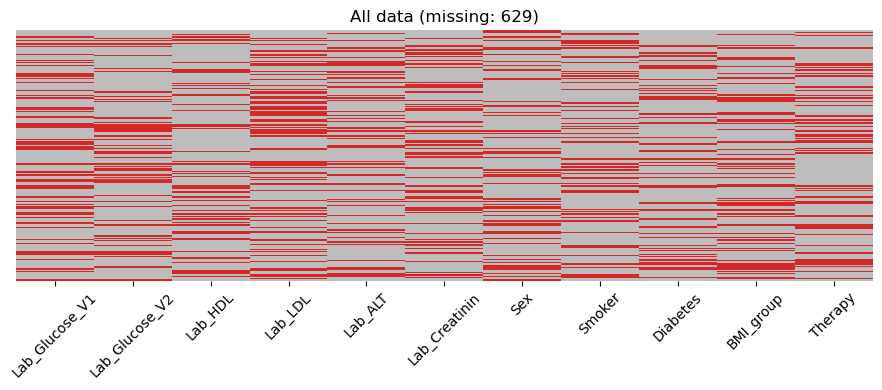

Пропуски по столбцам:
Lab_Glucose_V1    62
Lab_Glucose_V2    53
Lab_HDL           51
Lab_LDL           73
Lab_ALT           54
Lab_Creatinin     60
Sex               56
Smoker            53
Diabetes          54
BMI_group         60
Therapy           53
dtype: int64

Группа: ('Drug A',)
Размер: 46 строк


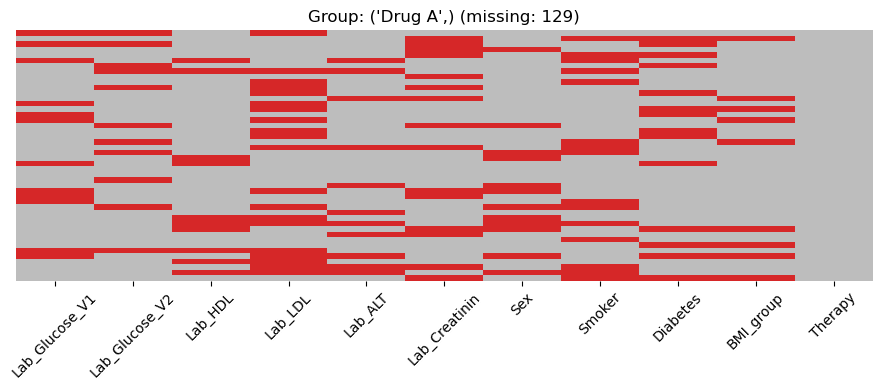

Пропуски по столбцам:
Lab_Glucose_V1    12
Lab_Glucose_V2    11
Lab_HDL           10
Lab_LDL           20
Lab_ALT           11
Lab_Creatinin     15
Sex               12
Smoker            15
Diabetes          14
BMI_group          9
Therapy            0
dtype: int64

Группа: ('Drug B',)
Размер: 42 строк


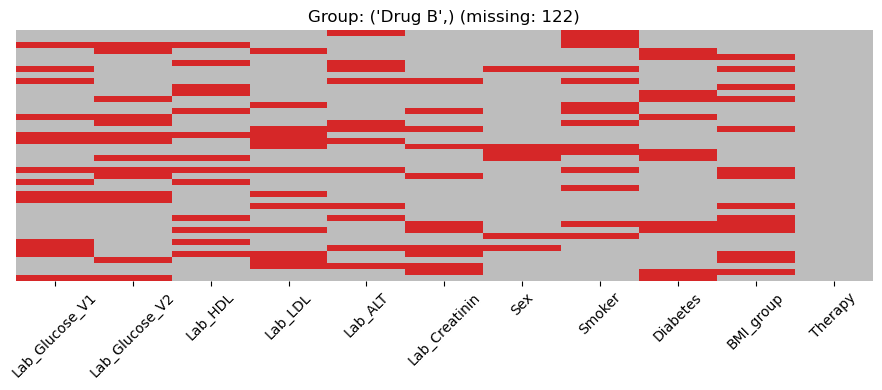

Пропуски по столбцам:
Lab_Glucose_V1    14
Lab_Glucose_V2    14
Lab_HDL           13
Lab_LDL           13
Lab_ALT           12
Lab_Creatinin     11
Sex                6
Smoker            14
Diabetes          11
BMI_group         14
Therapy            0
dtype: int64

Группа: ('Placebo',)
Размер: 64 строк


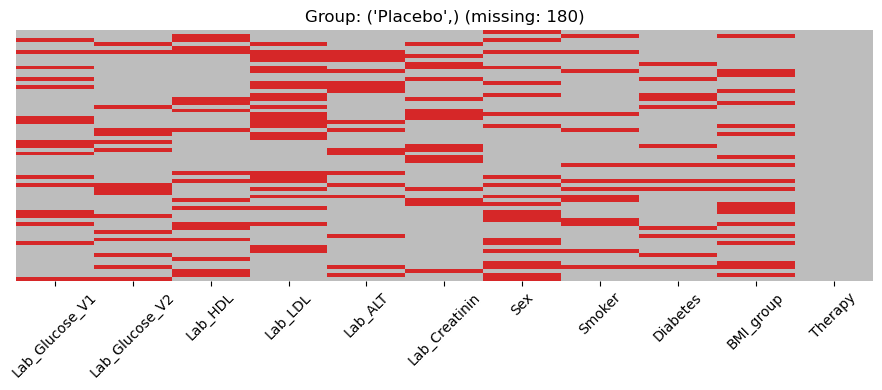

Пропуски по столбцам:
Lab_Glucose_V1    17
Lab_Glucose_V2    16
Lab_HDL           18
Lab_LDL           26
Lab_ALT           17
Lab_Creatinin     17
Sex               22
Smoker            14
Diabetes          13
BMI_group         20
Therapy            0
dtype: int64

Группа: (nan,)
Размер: 53 строк


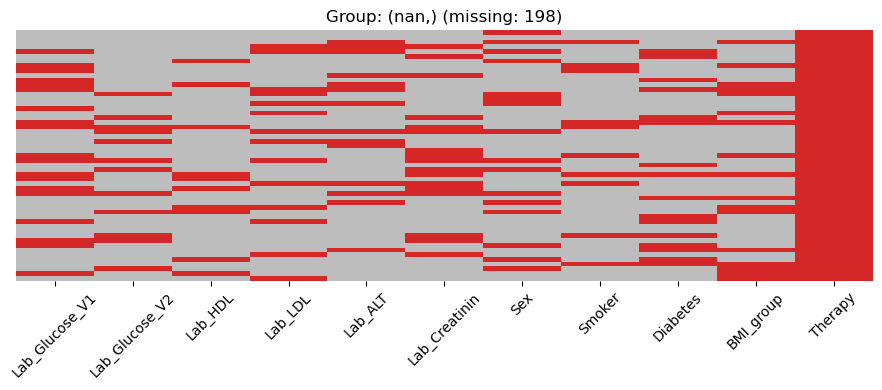

Пропуски по столбцам:
Lab_Glucose_V1    19
Lab_Glucose_V2    12
Lab_HDL           10
Lab_LDL           14
Lab_ALT           14
Lab_Creatinin     17
Sex               16
Smoker            10
Diabetes          16
BMI_group         17
Therapy           53
dtype: int64


In [23]:
df_demo = make_demo_table(seed=50, na_ratio=.30)

# Проверим конкретные группы
print("\n=== Группа Therapy ===")
therapy_groups = df_demo.groupby("Therapy", dropna=False)
for therapy, group in therapy_groups:
    missing_count = group.isna().sum().sum()
    print(f"Therapy={therapy}: {len(group)} строк, {missing_count} пропусков")

# Простая версия для отладки
plot_missing_by_combos_simple(df_demo)
plot_missing_by_combos_simple(df_demo, cat_cols=["Therapy"])
# plot_missing_by_combos_simple(df_demo, cat_cols=["Therapy", "Diabetes"])

Тепловая карта корреляции пропусков в `missingno` измеряет корреляцию отсутствия данных: насколько сильно наличие или отсутствие данных в одной переменной влияет на наличие данных в другой

<Axes: >

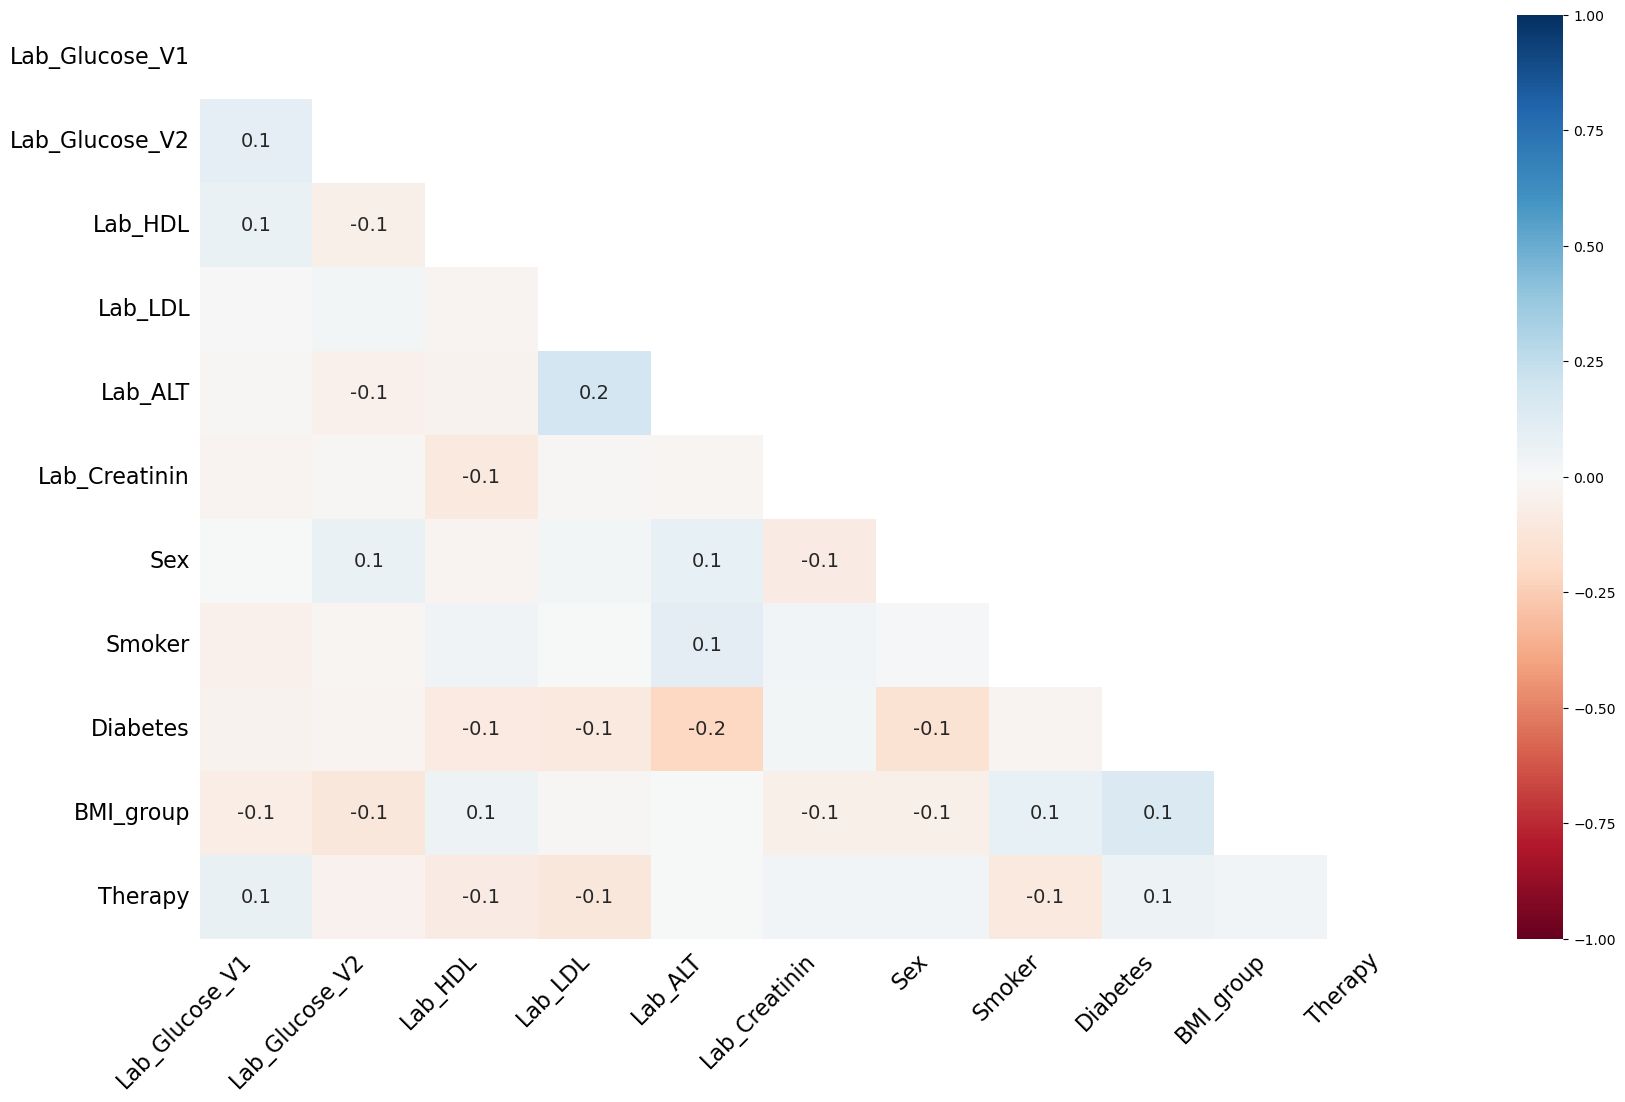

In [24]:
msno.heatmap(df_demo)

<Axes: >

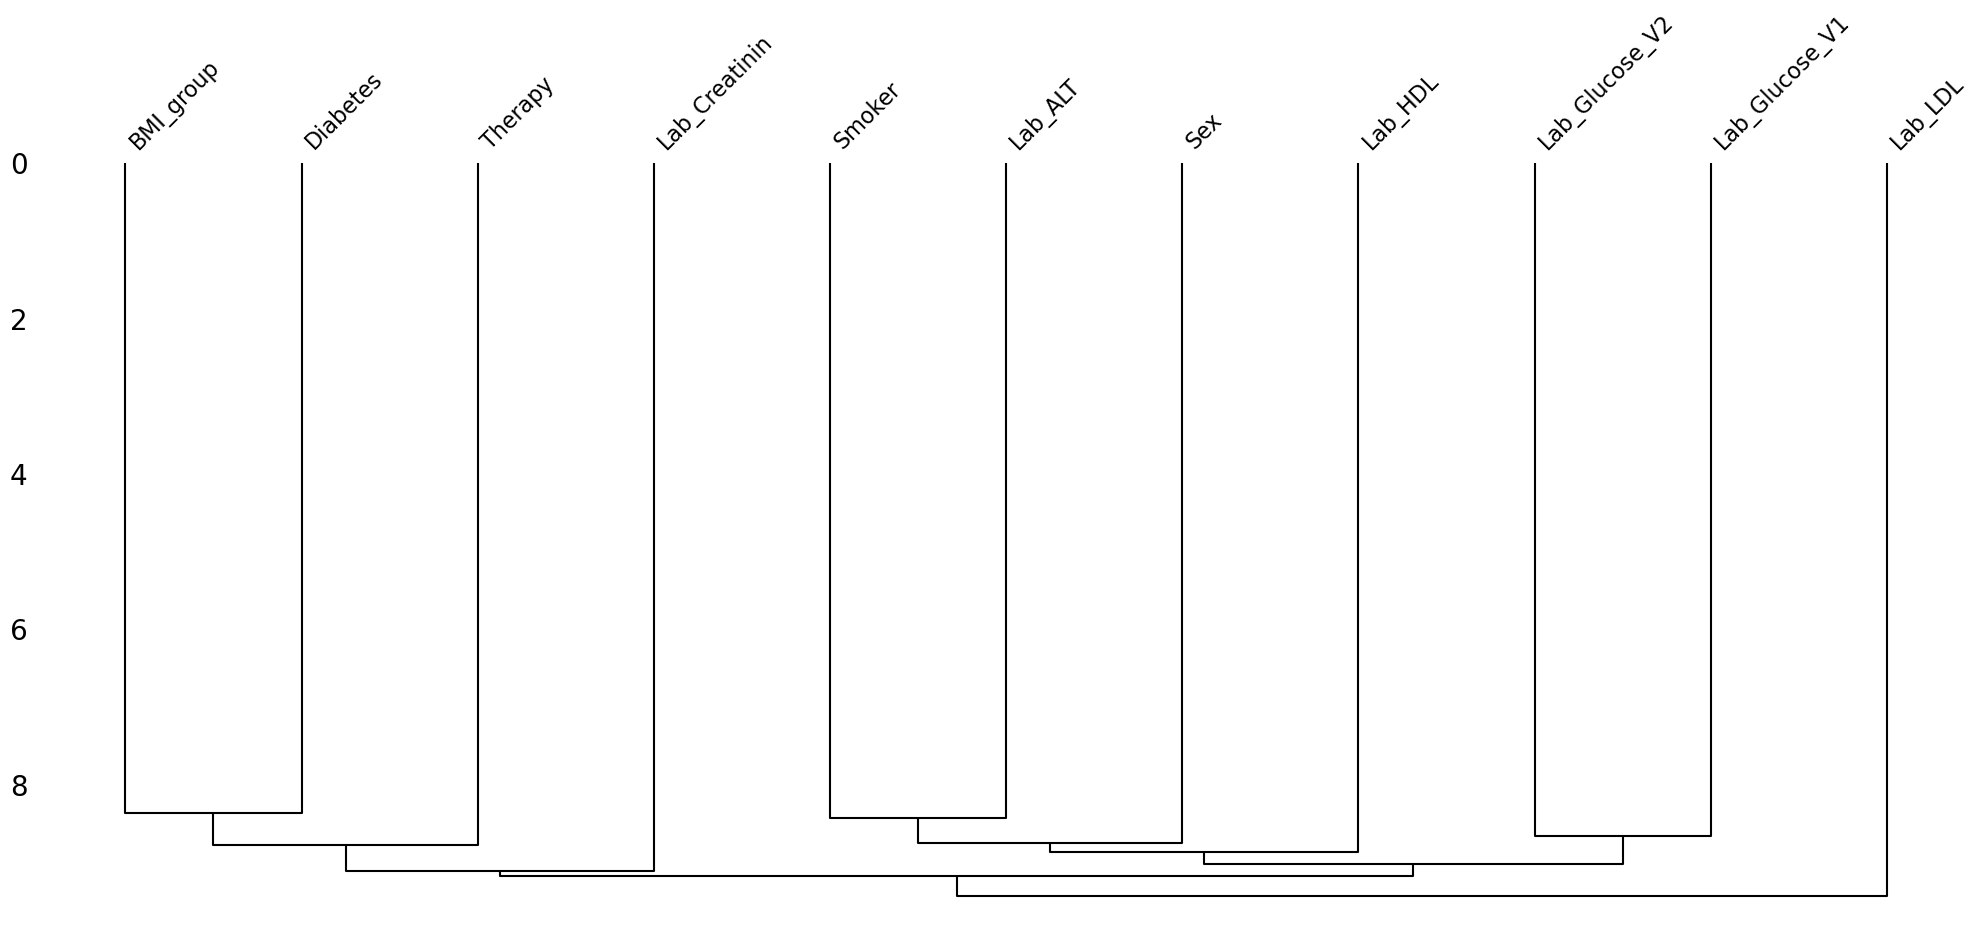

In [25]:
msno.dendrogram(df_demo)

# Описательные статистики

In [26]:
from scipy.stats import shapiro
from scipy import stats
import warnings
from itertools import combinations
from typing import List

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy import stats
from statsmodels.stats import multitest

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge

In [27]:
def factor_transformer(data_frame: pd.DataFrame,
                       min_factor_levels: int = 7) -> pd.DataFrame:
    """
    Convert every column that has ≤ `min_factor_levels` distinct non-NA values
    to pandas 'category' type (using pd.Categorical) and return the new frame.

    Parameters
    ----------
    data_frame : pd.DataFrame
        Source data.
    min_factor_levels : int, default 7
        Upper threshold for the number of distinct levels
        at or below which a column becomes categorical.

    Returns
    -------
    pd.DataFrame
        A copy of `data_frame` with selected columns converted
        to categorical dtype.
    """
    # 1. Count distinct non-missing values per column
    unique_counts = data_frame.nunique(dropna=True)

    # 2. Columns that meet the threshold
    cols_to_convert = unique_counts[unique_counts <= min_factor_levels].index

    # 3. Build and return a copy with those columns cast to category
    return data_frame.assign(
        **{col: pd.Categorical(data_frame[col]) for col in cols_to_convert}
    )



def _table_shapiro(df, digits):
    """Return p-values of Shapiro–Wilk for every numeric column."""
    num_cols = df.select_dtypes(include=[np.number]).columns
    pvals = {
        col: (shapiro(df[col].dropna())[1]          # p-value
              if 3 <= df[col].notna().sum() <= 5000 else np.nan)
        for col in num_cols
    }
    return (
        pd.Series(pvals, name="Тест Ш-У, значимость")
        .round(digits)
        .reset_index()
        .rename(columns={"index": "Показатель"})
    )


def _fmt_mean_sd(series, d):      # mean ± sd
    return f"{series.mean():.{d}f} ± {series.std(ddof=1):.{d}f}" if series.size else "NA"


def _fmt_median_iqr(series, d):   # median [p25; p75]
    if series.size == 0:
        return "NA"
    q25, q75 = np.percentile(series, [25, 75])
    return f"{series.median():.{d}f} [{q25:.{d}f}; {q75:.{d}f}]"


def _fmt_min(series, d):          # min with NA fallback
    return f"{series.min():.{d}f}" if series.size else "NA"


def _fmt_max(series, d):          # max with NA fallback
    return f"{series.max():.{d}f}" if series.size else "NA"


def _fmt_n_pct(n, total, d):
    pct = n / total * 100 if total else 0
    return f"{n} ({pct:.{d}f}%)"


def summary_all(data: pd.DataFrame, digits: int = 1) -> pd.DataFrame:
    """Mimic the R `summary_all()` with per-level rows for categoricals."""
    # 1. Normality test on numeric columns
    shapiro_df = _table_shapiro(data, 3)

    rows = []

    for col in data.columns:
        s = data[col].dropna()
        total_n = s.size
        is_num = pd.api.types.is_numeric_dtype(s)

        # -------- NUMERIC --------------------------------------------------
        if is_num:
            rows.append(
                {
                    "Показатель": col,
                    "Валидные,N": total_n,
                    "Абс,доля,%": "-",
                    "Среднее, ст.откл": _fmt_mean_sd(s, digits),
                    "Медиана и размахи": _fmt_median_iqr(s, digits),
                    "Мин": _fmt_min(s, digits),
                    "Макс": _fmt_max(s, digits),
                }
            )
        # -------- CATEGORICAL ----------------------------------------------
        else:
            # header-like line for the variable itself
            rows.append(
                {
                    "Показатель": col,
                    "Валидные,N": "NA",
                    "Абс,доля,%": "NA",
                    "Среднее, ст.откл": "NA",
                    "Медиана и размахи": "NA",
                    "Мин": "NA",
                    "Макс": "NA",
                }
            )

            # one row per category
            counts = s.value_counts(dropna=False).sort_index()
            for level, n in counts.items():
                level_name = str(level)
                rows.append(
                    {
                        "Показатель": level_name,
                        "Валидные,N": total_n,
                        "Абс,доля,%": _fmt_n_pct(n, total_n, digits),
                        "Среднее, ст.откл": "-",
                        "Медиана и размахи": "-",
                        "Мин": "-",
                        "Макс": "-",
                    }
                )

    # 2. Build DataFrame
    df = pd.DataFrame(rows)

    # 3. Merge with Shapiro p-values → only numeric rows keep the number
    df = df.merge(shapiro_df, on="Показатель", how="left")

    # 4. Add running index & reorder columns
    df.insert(0, "Индекс", range(1, len(df) + 1))
    final_cols = [
        "Индекс",
        "Показатель",
        "Валидные,N",
        "Абс,доля,%",
        "Среднее, ст.откл",
        "Медиана и размахи",
        "Мин",
        "Макс",
        "Тест Ш-У, значимость",
    ]
    return df[final_cols]

In [28]:
def fisher_exact_r(cont: pd.DataFrame, seed=1000) -> tuple[str, float | None]:
    """
    Run Fisher's exact test via R for ANY sized contingency table with sparse cells.
    Uses simulation for larger tables to avoid computational issues.
    
    Parameters
    ----------
    cont : pd.DataFrame - contingency table of any size (m × n)
    seed : int - random seed for reproducibility
    
    Returns
    -------
    (test_name, p_value)
    """
    np.random.seed(seed)
    try:
        import rpy2.robjects as ro
        from rpy2.robjects import pandas2ri
        from rpy2.robjects.packages import importr

        # Activate pandas-to-R conversion
        pandas2ri.activate()
        stats_r = importr('stats')
        
        # Convert the contingency table to an R matrix
        r_matrix = pandas2ri.py2rpy(cont)
        
        # For 2×k tables use exact method
        if cont.shape[0] == 2:
            result = stats_r.fisher_test(r_matrix)
            p_value = result.rx2('p.value')[0]
            return "Точный тест Фишера (R)", float(p_value)
        
        # For larger tables use Monte Carlo simulation
        else:
            ro.r(f'set.seed({seed})')
            result = stats_r.fisher_test(r_matrix, simulate_p_value=True)
            p_value = result.rx2('p.value')[0]
            return "Точный тест Фишера (R, симуляция)", float(p_value)
            
    except Exception as e:
        # Fallback to chi-square with correction
        chi2, p_val, *_ = stats.chi2_contingency(cont, correction=True)
        return f"R не найден → Χ²-тест", p_val


def _shapiro_ok(x: np.ndarray) -> bool:
    """TRUE ⇢ p > .05 (looks Normal) – reproduces R part."""
    x = x[~np.isnan(x)]
    if x.size < 3 or x.size > 5000 or np.unique(x).size < 3:
        return False
    try:
        return stats.shapiro(x).pvalue > 0.05
    except Exception:
        return False


def compare_all(
    df: pd.DataFrame,
    group_var: str,
    digits: int = 1,
    add_minmax: bool = False,
) -> pd.DataFrame:
    """
    Python re-implementation of the R function `compare_all`.

    Parameters
    ----------
    df         : pd.DataFrame
    group_var  : str              – name of the grouping column
    digits     : int, default 1   – decimals in formatted output
    add_minmax : bool, default False
                                   – include 'min-max' row for numerics

    Returns
    -------
    pd.DataFrame – summary table (ready for copy/paste to docs)
    """
    # ------------------------------------------------------------ #
    # 0. Preparation                                               #
    # ------------------------------------------------------------ #
    wk = df.copy(deep=True)   # never touch the caller's frame!

    # keep the original order of groups (factor levels first, else order of appearance)
    if pd.api.types.is_categorical_dtype(wk[group_var]):
        groups = list(wk[group_var].cat.categories)
    else:
        groups = list(pd.unique(wk[group_var]))
    n_groups = len(groups)

    # temporary fix: columns starting with a digit -> prepend 'firstnum_'
    newcols = {
        col: f"firstnum_{col}" if re.match(r"^\d", str(col)) else col
        for col in wk.columns
    }
    wk.rename(columns=newcols, inplace=True)

    # mapping to restore names only for the 'Фактор' column later
    reverse_fix = {v: k for k, v in newcols.items()}

    # helper format strings
    fmt_mean_sd = lambda m, s: f"{m:.{digits}f} ± {s:.{digits}f}"
    fmt_med_iqr = lambda d, q1, q3: f"{d:.{digits}f} [{q1:.{digits}f}, {q3:.{digits}f}]"
    fmt_minmax = lambda mn, mx: f"({mn:.{digits}f}; {mx:.{digits}f})"
    fmt_pval = lambda p: f"{p:.3f}" if p is not None and not np.isnan(p) else ""

    rows = []
    row_id = 1

    # ------------------------------------------------------------ #
    # 1. Iterate over every variable except the group var          #
    # ------------------------------------------------------------ #
    for var in [c for c in wk.columns if c != group_var]:

        col_ser = wk[var]
        # ---------- NUMERIC ------------------------------------------------
        if pd.api.types.is_numeric_dtype(col_ser):

            desc = (
                wk.groupby(group_var)[var]
                .agg(
                    mean="mean",
                    sd="std",
                    median="median",
                    q1=lambda x: x.quantile(0.25),
                    q3=lambda x: x.quantile(0.75),
                    mn="min",
                    mx="max",
                    N=lambda x: x.notna().sum(),
                )
                .reindex(groups)
            )
            desc["N"] = desc["N"].fillna(0).astype(int)

            # global normality decision
            is_normal = all(_shapiro_ok(wk.loc[wk[group_var] == g, var].to_numpy())
                            for g in groups)

            # choose the right inferential test
            p_val = None
            test_name = ""
            # all groups must contain at least 2 distinct values
            valid_groups = [
                wk.loc[wk[group_var] == g, var].dropna().nunique() > 1 for g in groups
            ]

            if not all(valid_groups):
                test_name = "Недостаточно данных (нулевая дисперсия в группе)"
            else:
                try:
                    if n_groups == 2:
                        g1, g2 = [wk.loc[wk[group_var] == g, var].dropna() for g in groups]
                        if is_normal:
                            p_val = stats.ttest_ind(g1, g2, equal_var=False).pvalue
                            test_name = "t-тест Стьюдента"
                        else:
                            p_val = stats.mannwhitneyu(g1, g2, alternative="two-sided").pvalue
                            test_name = "Тест Вилкоксона"
                    else:  # > 2 groups
                        arrays = [wk.loc[wk[group_var] == g, var].dropna() for g in groups]
                        if any(len(a) <= 1 for a in arrays):
                            test_name = "Невозможно выполнить тест: недостаточно наблюдений"
                        elif is_normal:
                            p_val = stats.f_oneway(*arrays).pvalue
                            test_name = "ANOVA"
                        else:
                            p_val = stats.kruskal(*arrays).pvalue
                            test_name = "Тест Краскела-Уоллиса"
                except Exception:
                    test_name = "Ошибка при выполнении теста"
                    p_val = None

            # ---------- assemble rows ----------------------------------
            stat_rows = [
                ("среднее ± СО",
                 [fmt_mean_sd(desc.loc[g, 'mean'], desc.loc[g, 'sd']) for g in groups]),
                ("медиана [25%; 75%]",
                 [fmt_med_iqr(desc.loc[g, 'median'], desc.loc[g, 'q1'], desc.loc[g, 'q3'])
                  for g in groups]),
            ]
            if add_minmax:
                stat_rows.append(
                    ("Мин - Макс",
                     [fmt_minmax(desc.loc[g, 'mn'], desc.loc[g, 'mx']) for g in groups])
                )

            for ix, (stat_name, stat_values) in enumerate(stat_rows):
                row = {
                    "id": row_id,
                    "Фактор": var if ix == 0 else "",
                    "Статистика": stat_name,
                    **{g: stat_values[i] for i, g in enumerate(groups)},
                    **{f"n{i+1}": desc.loc[groups[i], "N"] for i in range(n_groups)},
                    "test_used": test_name if ix == 0 else "",
                    "p_value": fmt_pval(p_val) if ix == 0 else "",
                }
                rows.append(row)
                row_id += 1

        # ---------- CATEGORICAL (factor) -----------------------------------
        else:
            levels = pd.unique(col_ser.dropna())
            cont = pd.crosstab(wk[var], wk[group_var], dropna=True) \
                    .reindex(index=levels, columns=groups, fill_value=0)

            # ------- choose the inferential test -------------------------
            if cont.shape[0] < 2 or cont.shape[1] < 2:
                test_name, p_val = "Недостаточно данных для теста", None

            # Any table with sparse cells - use Fisher's test via R
            elif (cont.values < 5).any():
                test_name, p_val = fisher_exact_r(cont)

            else:
                # Well-populated table - use regular chi-square
                chi2, p_val, *_ = stats.chi2_contingency(cont)
                test_name = "Χ²-тест"

            # group-wise denominators
            valid_n = (wk.groupby(group_var)[var]
                        .count()
                        .reindex(groups)
                        .fillna(0)         # NEW ▶ пропуски → 0
                        .astype(int))      # затем int

            # -------- one output row per category level ------------------
            for j, level in enumerate(levels):
                counts = cont.loc[level]
                row = {
                    "id": row_id,
                    "Фактор": var if j == 0 else "",
                    "Статистика": level,
                    **{
                        g: f"{counts[g]} "
                           f"({(counts[g]/valid_n[g]*100 if valid_n[g] else 0):.{digits}f}%)"
                        for g in groups
                    },
                    **{f"n{i+1}": valid_n[groups[i]] for i in range(n_groups)},
                    "test_used": test_name if j == 0 else "",
                    "p_value": (f"{p_val:.3f}" if j == 0 and p_val is not None else "")
                }
                rows.append(row)
                row_id += 1

    # ------------------------------------------------------------ #
    # 2. Wrap-up                                                  #
    # ------------------------------------------------------------ #
    out = pd.DataFrame(rows)

    # Final column order
    out = out[
        ["id", "Фактор", "Статистика", *groups,
         *[f"n{i+1}" for i in range(n_groups)], "test_used", "p_value"]
    ]

    # polish column headers
    out.rename(columns={
        "test_used": "Статистический тест",
        "p_value": "Значимость, р"
    }, inplace=True)

    # restore original variable names (remove the temporary prefix)
    out["Фактор"] = out["Фактор"].replace(reverse_fix)

    return out

In [29]:
# ---------------------------------------------------------------
#  Pairwise group–wise comparisons (Python version of the R helper)
# ---------------------------------------------------------------
import warnings
from itertools import combinations
from typing import List

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy import stats
from statsmodels.stats import multitest


# ----------------------------------------------------------------
#  We assume the universal Fisher helper is already in memory
#     from fisher_exact_r import fisher_exact_r
# ----------------------------------------------------------------


def _pair_names(groups: List[str]) -> List[str]:
    """Return ``['g1 - g2', 'g1 - g3', …]`` in the order of combinations."""
    return [f"{g1} - {g2}" for g1, g2 in combinations(groups, 2)]


def pairwise_comparisons(
        data: pd.DataFrame,
        group_var: str,
        p_adjust_method: str = "none"
) -> pd.DataFrame:
    """
    Perform pairwise comparisons (numeric & categorical) for every variable
    against a multi-level grouping factor.

    Parameters
    ----------
    data : pd.DataFrame
    group_var : str
        Column name that defines the groups (must contain >2 levels).
    p_adjust_method : str
        'none' (default) or any method accepted by
        statsmodels.stats.multitest.multipletests
        ('bonferroni', 'holm', 'fdr_bh', …).

    Returns
    -------
    pd.DataFrame
        One row per analysed variable, columns = every pair of groups.
        Cells hold raw or adjusted p-values (NaN if test not applicable).
    """
    # 0. sanity ----------------------------------------------------------------

    if group_var not in data.columns:
        raise KeyError(f"'{group_var}' not found in DataFrame")

    groups = data[group_var].dropna().unique()
    if len(groups) <= 2:
        raise ValueError("Grouping variable must have more than 2 levels")

    group_pairs = list(combinations(groups, 2))
    pair_cols = _pair_names(groups)

    # 1. iterate over variables -----------------------------------------------
    out_rows = []
    idx = 1

    for var in [c for c in data.columns if c != group_var]:

        col = data[var]
        if col.isna().all():
            continue                                                   # skip N/A only

        p_raw = [np.nan] * len(pair_cols)                              # placeholder

        # -------- numeric -----------------------------------------------------
        if pd.api.types.is_numeric_dtype(col):
            # single Shapiro on all non-NA values (same as original R helper)
            try:
                vals = col.dropna()
                normal = len(vals) >= 3 and len(vals) <= 5000 \
                         and stats.shapiro(vals).pvalue > .05
            except Exception:
                normal = False

            for ix, (g1, g2) in enumerate(group_pairs):
                x, y = (data.loc[data[group_var] == g, var].dropna() for g in (g1, g2))
                if len(x) < 2 or len(y) < 2:
                    continue

                try:
                    if normal:
                        p = stats.ttest_ind(x, y, equal_var=False).pvalue
                    else:
                        p = stats.mannwhitneyu(x, y, alternative="two-sided",
                              method="asymptotic").pvalue
                    p_raw[ix] = float(p)
                except Exception as e:
                    warnings.warn(f"{var}: test failed for {g1}-{g2} → {e}")

        # -------- categorical -------------------------------------------------
        else:
            # ensure categorical dtype (remove future-warning)
            if not isinstance(col.dtype, CategoricalDtype):
                col = col.astype("category")

            for ix, (g1, g2) in enumerate(group_pairs):
                sub = data[data[group_var].isin([g1, g2])]
                table = pd.crosstab(sub[var], sub[group_var])

                if table.shape[0] < 2 or table.shape[1] < 2:
                    continue

                try:
                    if (table.values < 5).any():
                        _, p = fisher_exact_r(table)                   # tuple(name, p)
                    else:
                        p = stats.chi2_contingency(table)[1]
                    p_raw[ix] = float(p)
                except Exception as e:
                    warnings.warn(f"{var}: categorical test failed for {g1}-{g2} → {e}")

        # -------- assemble row -----------------------------------------------
        if not np.isnan(p_raw).all():
            row = {"id": idx, "Factor": var, **dict(zip(pair_cols, p_raw))}

            # adjust if requested
            if p_adjust_method.lower() != "none":
                valid_idx = [i for i, p in enumerate(p_raw) if not np.isnan(p)]
                if valid_idx:
                    adj = multitest.multipletests(
                        [p_raw[i] for i in valid_idx],
                        method=p_adjust_method.lower()
                    )[1]
                    for i, adj_p in zip(valid_idx, adj):
                        row[pair_cols[i]] = adj_p

            out_rows.append(row)
            idx += 1
        

    return pd.DataFrame(out_rows).round(3)

In [30]:
def smart_imputer(df: pd.DataFrame,
                  *,
                  thresh: float = .10,
                  random_state: int | None = 0) -> pd.DataFrame:
    """
    Импутирует пропуски только там, где их ≤ `thresh`
      • числовые колонки  – IterativeImputer (BayesianRidge)
      • категориальные    – SimpleImputer(most_frequent)

    Parameters
    ----------
    df            : исходный DataFrame
    thresh        : порог доли NaN (0.10 = 10 %)
    random_state  : фиксирует случайность в IterativeImputer

    Returns
    -------
    новый DataFrame (оригинал не меняется)
    """
    out = df.copy()
    miss_share = out.isna().mean()

    # -------- числовые --------------------------------------------------
    num_cols = out.select_dtypes(include="number").columns
    num_targets = [c for c in num_cols if 0 < miss_share[c] <= thresh]

    if num_targets:
        # IterativeImputer требует ≥2 признаков; если 1 → MeanImputer
        if len(num_targets) == 1:
            imp_num = SimpleImputer(strategy="mean")
        else:
            imp_num = IterativeImputer(
                estimator=BayesianRidge(),
                max_iter=10,
                random_state=random_state
            )
        out[num_targets] = imp_num.fit_transform(out[num_targets])

    # -------- категориальные -------------------------------------------
    cat_cols = out.select_dtypes(exclude="number").columns
    cat_targets = [c for c in cat_cols if 0 < miss_share[c] <= thresh]

    if cat_targets:
        imp_cat = SimpleImputer(strategy="most_frequent")
        out[cat_targets] = imp_cat.fit_transform(out[cat_targets])

    return out

In [31]:
df_demo = make_demo_table(seed=50, na_ratio=.1)

describe_missing(make_demo_table(seed=50, na_ratio = .1))

,Переменная,Тип данных,Кол-во пропусков,Доля пропусков,Доля валидных
0,Lab_Glucose_V1,Количественная,21,10.24,89.76
1,Lab_Glucose_V2,Количественная,20,9.76,90.24
2,Lab_HDL,Количественная,22,10.73,89.27
3,Lab_LDL,Количественная,26,12.68,87.32
4,Lab_ALT,Количественная,17,8.29,91.71
5,Lab_Creatinin,Количественная,19,9.27,90.73
6,Sex,Бинарная,23,11.22,88.78
7,Smoker,Бинарная,16,7.80,92.20
8,Diabetes,Номинальная,20,9.76,90.24
9,BMI_group,Номинальная,15,7.32,92.68


In [32]:
df_imputed = smart_imputer(df_demo, thresh=.10, random_state=0)

describe_missing(df_imputed)

,Переменная,Тип данных,Кол-во пропусков,Доля пропусков,Доля валидных
0,Lab_Glucose_V1,Количественная,21,10.24,89.76
1,Lab_Glucose_V2,Количественная,0,0.00,100.00
2,Lab_HDL,Количественная,22,10.73,89.27
3,Lab_LDL,Количественная,26,12.68,87.32
4,Lab_ALT,Количественная,0,0.00,100.00
5,Lab_Creatinin,Количественная,0,0.00,100.00
6,Sex,Бинарная,23,11.22,88.78
7,Smoker,Бинарная,0,0.00,100.00
8,Diabetes,Номинальная,0,0.00,100.00
9,BMI_group,Номинальная,0,0.00,100.00


In [33]:
df_imputed = smart_imputer(df_demo, thresh=.50, random_state=0)

describe_missing(df_imputed)

,Переменная,Тип данных,Кол-во пропусков,Доля пропусков,Доля валидных
0,Lab_Glucose_V1,Количественная,0,0.0,100.0
1,Lab_Glucose_V2,Количественная,0,0.0,100.0
2,Lab_HDL,Количественная,0,0.0,100.0
3,Lab_LDL,Количественная,0,0.0,100.0
4,Lab_ALT,Количественная,0,0.0,100.0
5,Lab_Creatinin,Количественная,0,0.0,100.0
6,Sex,Бинарная,0,0.0,100.0
7,Smoker,Бинарная,0,0.0,100.0
8,Diabetes,Номинальная,0,0.0,100.0
9,BMI_group,Номинальная,0,0.0,100.0


In [34]:
df_imputed = factor_transformer(df_imputed)
df_imputed.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Lab_Glucose_V1  205 non-null    float64 
 1   Lab_Glucose_V2  205 non-null    float64 
 2   Lab_HDL         205 non-null    float64 
 3   Lab_LDL         205 non-null    float64 
 4   Lab_ALT         205 non-null    float64 
 5   Lab_Creatinin   205 non-null    float64 
 6   Sex             205 non-null    category
 7   Smoker          205 non-null    category
 8   Diabetes        205 non-null    category
 9   BMI_group       205 non-null    category
 10  Therapy         205 non-null    category
dtypes: category(5), float64(6)
memory usage: 11.4 KB


In [35]:
df_imputed["Lab_Glucose_Dynamic"] = df_imputed["Lab_Glucose_V2"] - df_imputed["Lab_Glucose_V1"]

In [36]:
summary_all(df_imputed)

,Индекс,Показатель,"Валидные,N","Абс,доля,%","Среднее, ст.откл",Медиана и размахи,Мин,Макс,"Тест Ш-У, значимость"
0,1,Lab_Glucose_V1,205,-,6.5 ± 1.2,6.4 [5.5; 7.3],3.6,9.9,0.366
1,2,Lab_Glucose_V2,205,-,5.2 ± 1.8,5.2 [3.9; 6.3],1.1,9.8,0.624
2,3,Lab_HDL,205,-,1.3 ± 0.3,1.3 [1.1; 1.5],0.5,2.0,0.286
3,4,Lab_LDL,205,-,3.4 ± 0.9,3.4 [2.9; 4.0],0.6,5.9,0.165
4,5,Lab_ALT,205,-,15.1 ± 9.7,13.1 [7.8; 20.5],0.7,48.6,0.000
5,6,Lab_Creatinin,205,-,86.0 ± 12.4,85.1 [74.1; 94.5],70.0,117.4,0.000
6,7,Sex,NA,NA,NA,NA,NA,NA,NaN
7,8,Female,205,72 (35.1%),-,-,-,-,NaN
8,9,Male,205,133 (64.9%),-,-,-,-,NaN
9,10,Smoker,NA,NA,NA,NA,NA,NA,NaN


In [37]:
compare_all(df_imputed, "Therapy")

/tmp/ipykernel_70865/2295281768.py:85: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(wk[group_var]):


NameError: name 're' is not defined

In [ ]:
pairwise_comparisons(df_imputed[["Therapy", "Lab_Glucose_V2", "Lab_LDL", "Lab_Glucose_Dynamic"]], 
        "Therapy",
        "holm"
)

,id,Factor,Placebo - Drug B,Placebo - Drug A,Drug B - Drug A
0,1,Lab_Glucose_V2,0.000,0.000,0.000
1,2,Lab_LDL,0.022,0.321,0.321
2,3,Lab_Glucose_Dynamic,0.000,0.000,0.000


# "Ассоциации"
---


In [38]:
df_imputed.columns

Index(['Lab_Glucose_V1', 'Lab_Glucose_V2', 'Lab_HDL', 'Lab_LDL', 'Lab_ALT',
       'Lab_Creatinin', 'Sex', 'Smoker', 'Diabetes', 'BMI_group', 'Therapy',
       'Lab_Glucose_Dynamic'],
      dtype='object')

In [39]:
df_imputed["Therapy"] = pd.Categorical(df_imputed["Therapy"], ordered=True,
                   categories=['Placebo', 'Drug A', 'Drug B'])

df_imputed["Smoker"] = pd.Categorical(df_imputed["Smoker"], ordered=True,
                   categories=['No', 'Yes'])

df_imputed["BMI_group"] = pd.Categorical(df_imputed["BMI_group"], ordered=True,
                   categories=['<25', '25-30', '≥30'])


In [60]:
from __future__ import annotations
from pathlib import Path
from typing import Sequence, Hashable

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# ───────────────────────────────────────────────────────────────
#  Global seaborn / matplotlib theme  (font = serif ⤵︎)
# ───────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font="serif")          # <- NEW

# ───────────────────────────────────────────────────────────────
#  Customised box-plot helper
# ───────────────────────────────────────────────────────────────
def _pretty_boxplot(
    df,
    x,
    y,
    ax=None,
    palette_name="prism",      # <- already prism
    linewidth=2,
    box_alpha=0.20,            # <- NEW  (opacity 20 %)
    jitter=0.25,
    point_size=8,              # <- BIGGER points
):
    ax = ax or plt.gca()

    categories = df[x].dropna().unique()
    palette = sns.color_palette(palette_name, n_colors=len(categories))
    palette_dict = dict(zip(categories, palette))

    # main box-plot (no caps, thicker lines)
    g = sns.boxplot(
        data=df,
        x=x,
        y=y,
        ax=ax,
        palette=palette_dict,
        linewidth=linewidth,
        showcaps=False,
        fliersize=0,
    )

    # coloured, semi-transparent boxes
    for patch, cat in zip(g.artists, categories):
        face = palette_dict[cat]
        patch.set_facecolor((*face, box_alpha))   # RGBA with alpha 0.20

    # jittered raw points
    sns.stripplot(
        data=df,
        x=x,
        y=y,
        ax=ax,
        palette=palette_dict,
        jitter=jitter,
        size=point_size,
        dodge=False,
        alpha=0.7,
        linewidth=0,
    )

    # cosmetics
    ax.set(xlabel="", ylabel=y)
    ax.legend([], [], frameon=False)   # NO legend
    sns.despine(ax=ax)
    return ax


# ───────────────────────────────────────────────────────────────
#  Main function
# ───────────────────────────────────────────────────────────────
def draw_data_frame_group(
    df: pd.DataFrame,
    col_lst: Sequence[Hashable],
    group: Hashable,
    pict_sav: bool = True,
    add_number: bool = True,
    out_dir: str | Path | None = None,
    figsize: tuple[int, int] = (8, 8),
) -> None:
    def _fname(prefix: str, col_name: str) -> str:
        return f"{prefix}{col_name.replace('/', '_')}.png"

    def _save(fig: plt.Figure, fname: str) -> None:
        if pict_sav:
            path = Path(out_dir) / fname if out_dir else fname
            fig.savefig(path, dpi=150, bbox_inches="tight")
            plt.close(fig)

    prefixes = [
        f"{i:02d} " if add_number else "" for i in range(1, len(col_lst) + 1)
    ]

    for prefix, col in zip(prefixes, col_lst, strict=True):
        ser = df[col]
        is_cat = (
            pd.api.types.is_categorical_dtype(ser)
            or ser.nunique(dropna=True) < 6
        )

        if is_cat:
            # ── percentage bar-plot ────────────────────────────────
            tab = (
                pd.crosstab(ser, df[group], normalize="columns")
                .reset_index()
                .melt(id_vars=col, var_name=group, value_name="value")
            )
            tab["value"] *= 100

            # create a prism palette for the categories in *hue* (col)
            hue_categories = tab[col].dropna().unique()
            prism_palette = sns.color_palette("prism", n_colors=len(hue_categories))
            prism_dict = dict(zip(hue_categories, prism_palette))

            fig, ax = plt.subplots(figsize=figsize)
            g = sns.barplot(
                data=tab,
                x=group,
                y="value",
                hue=col,
                palette=prism_dict,   # <- prism palette applied
                ax=ax,
            )

            for p in g.patches:
                height = p.get_height()
                if height < 1e-9:
                    continue
                ax.annotate(
                    f"{height:.1f} %",
                    (p.get_x() + p.get_width() / 2, height),
                    ha="center",
                    va="center",
                    xytext=(0, 9),
                    textcoords="offset points",
                )

            ax.set(xlabel="", ylabel=col)
            g.legend_.set_title(None)
            ax.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0)

        else:
            # ── numeric box-plot ───────────────────────────────────
            fig, ax = plt.subplots(figsize=figsize)
            _pretty_boxplot(df, x=group, y=col, ax=ax)

        plt.tight_layout()
        plt.show()
        _save(fig, _fname(prefix, str(col)))

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


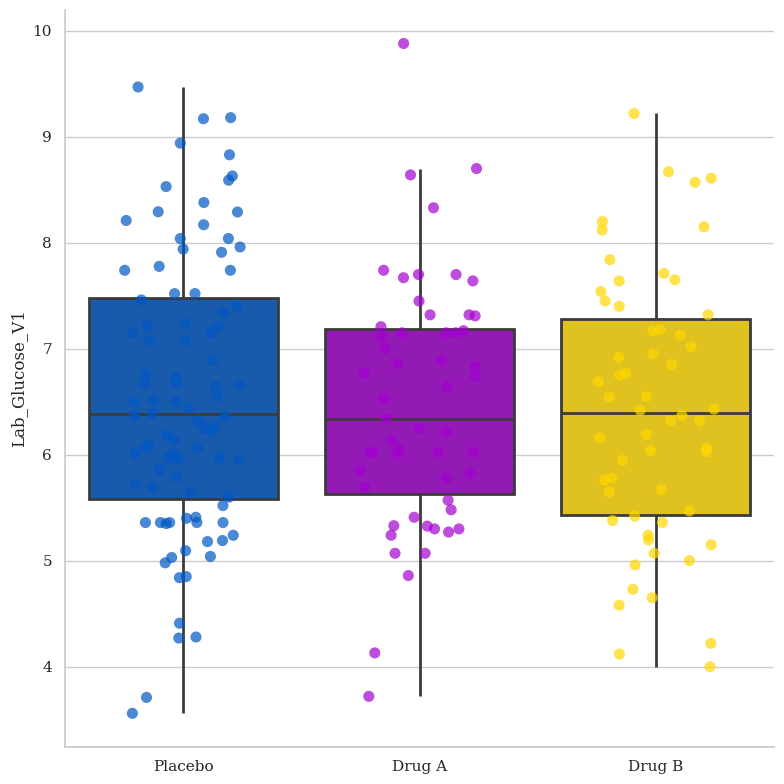

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


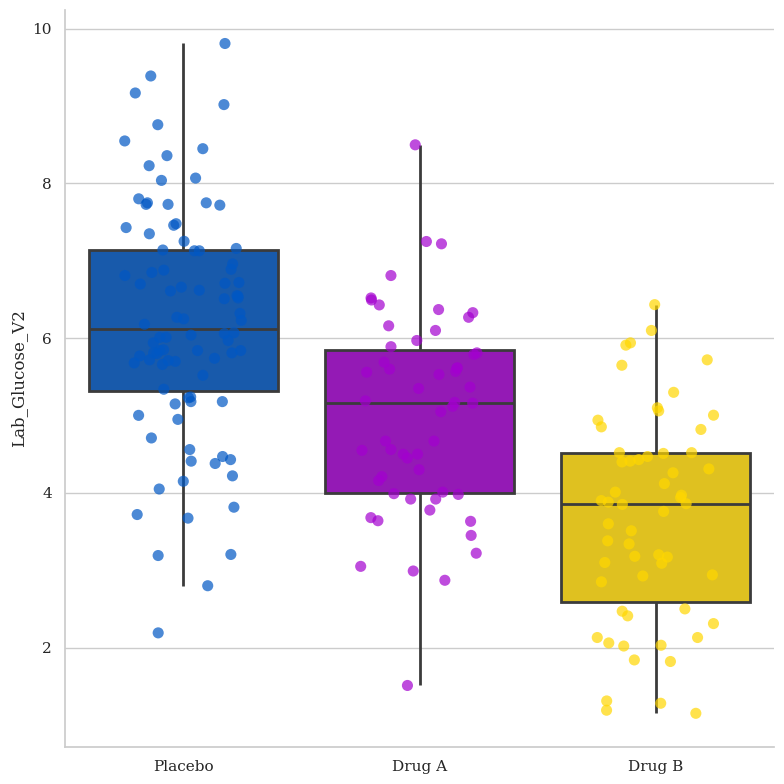

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


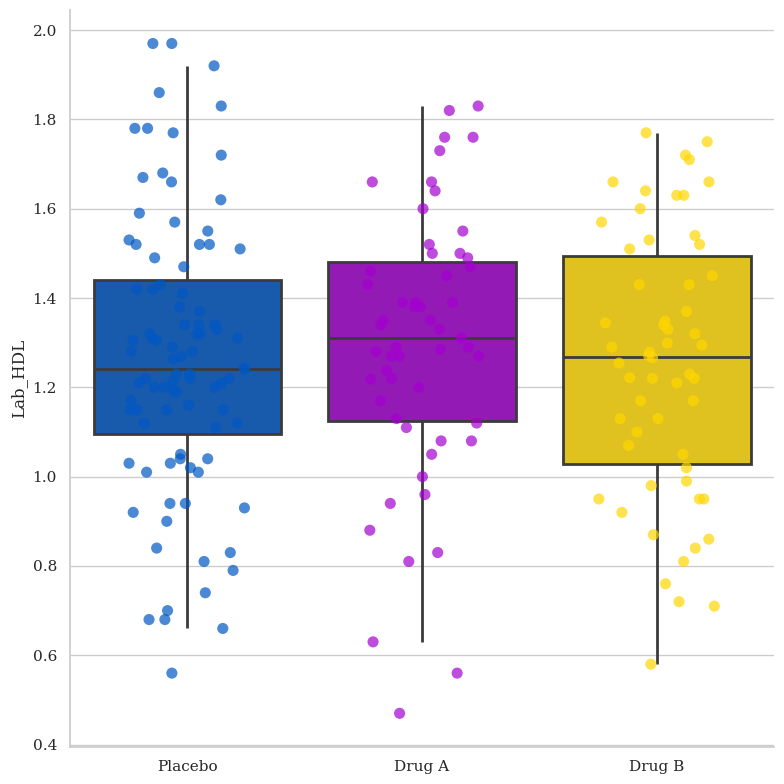

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


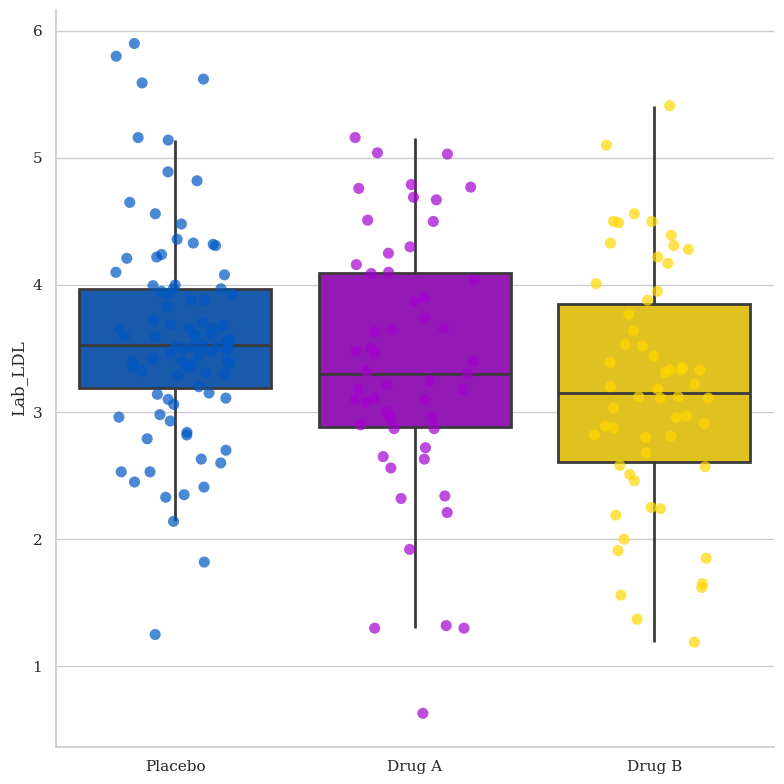

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


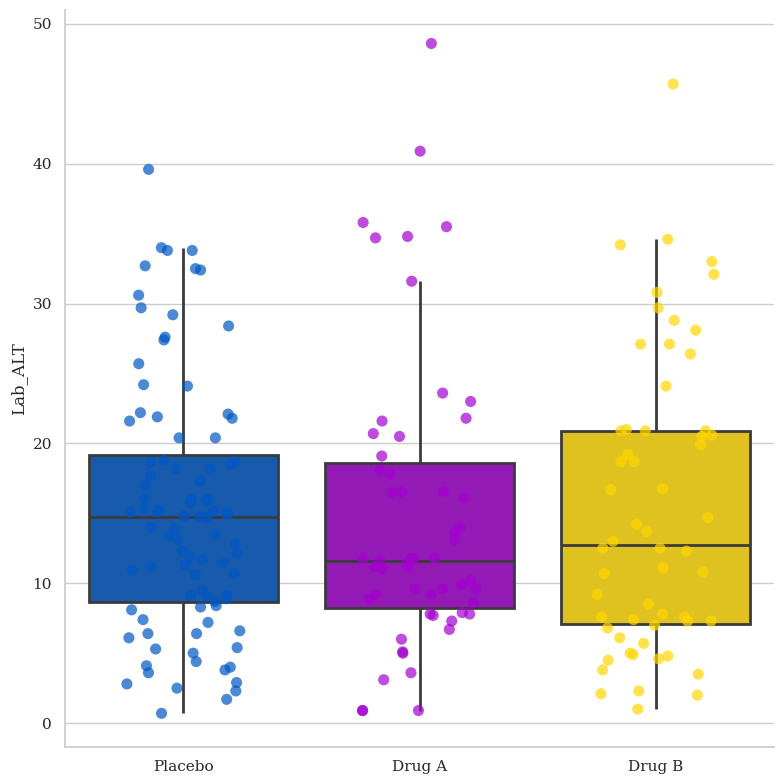

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


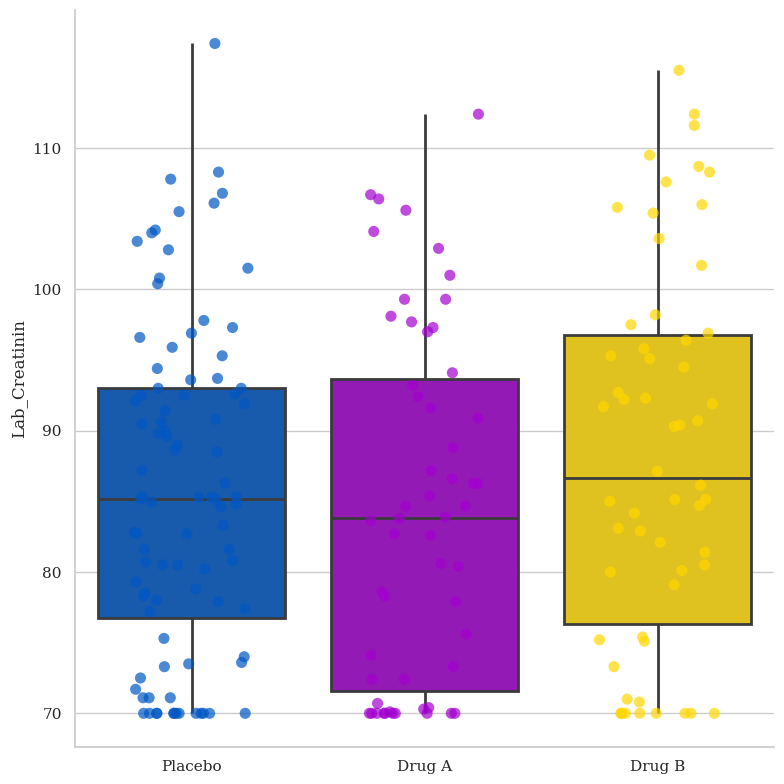

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)


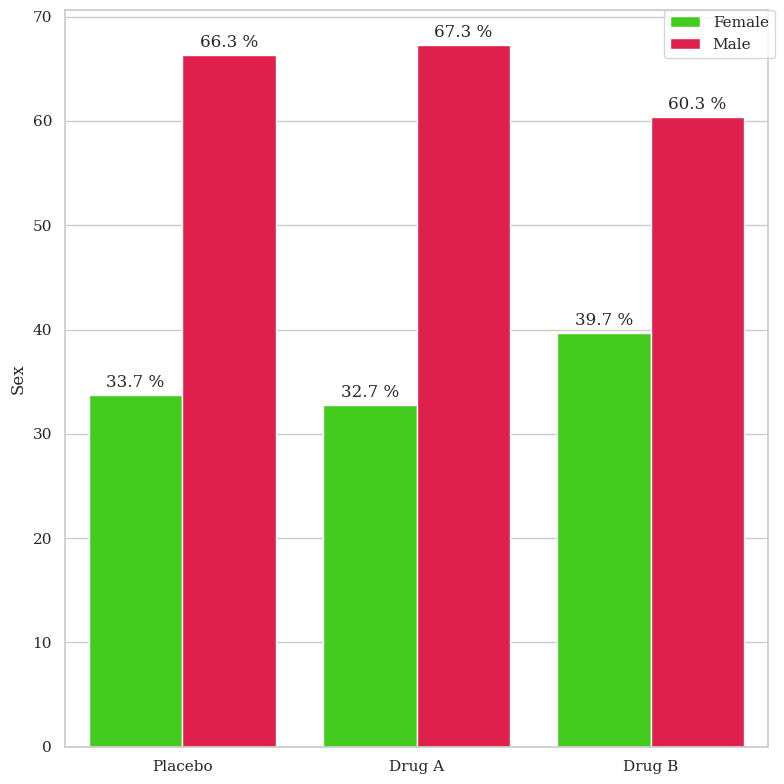

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)


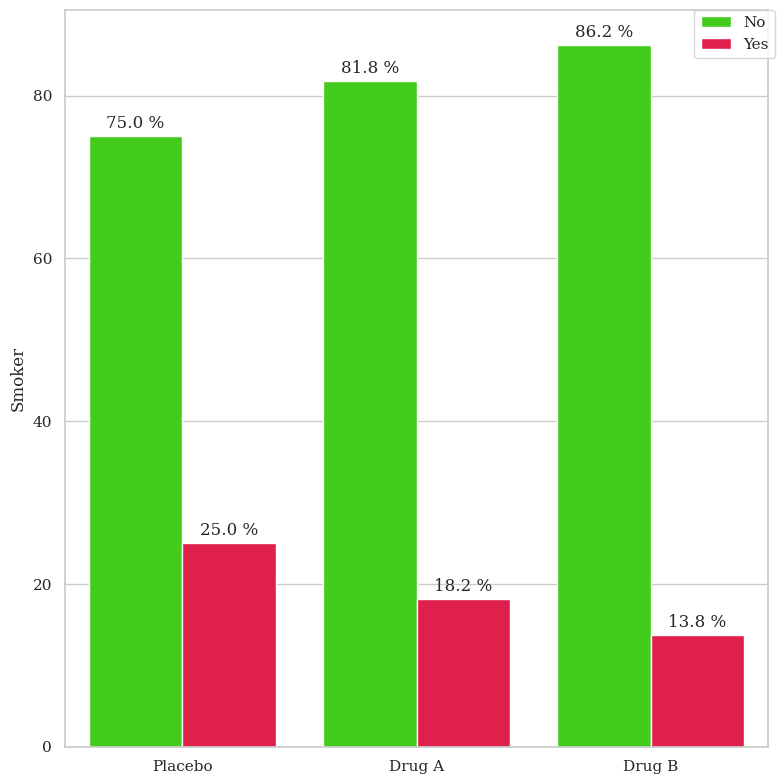

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)


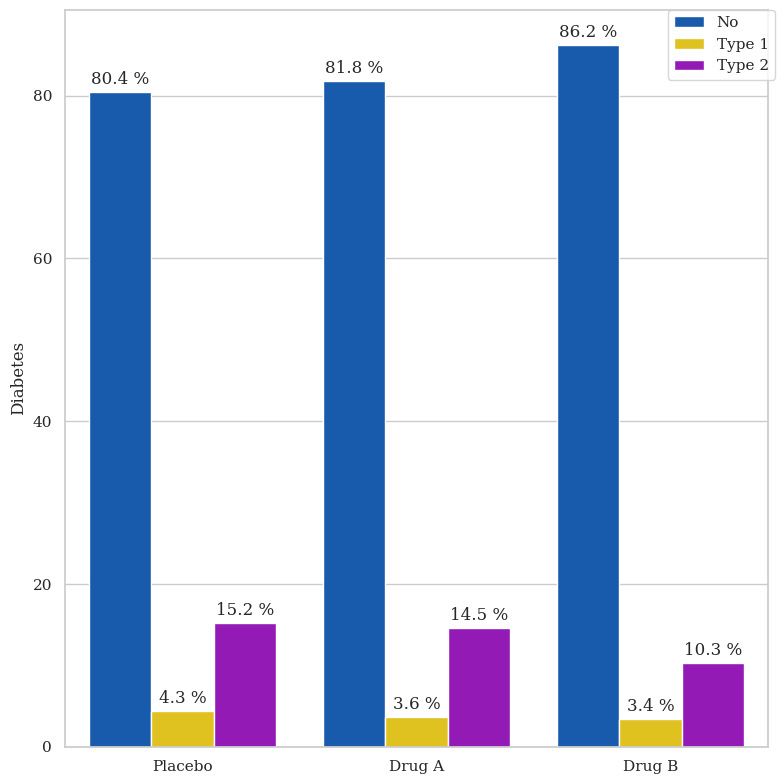

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)


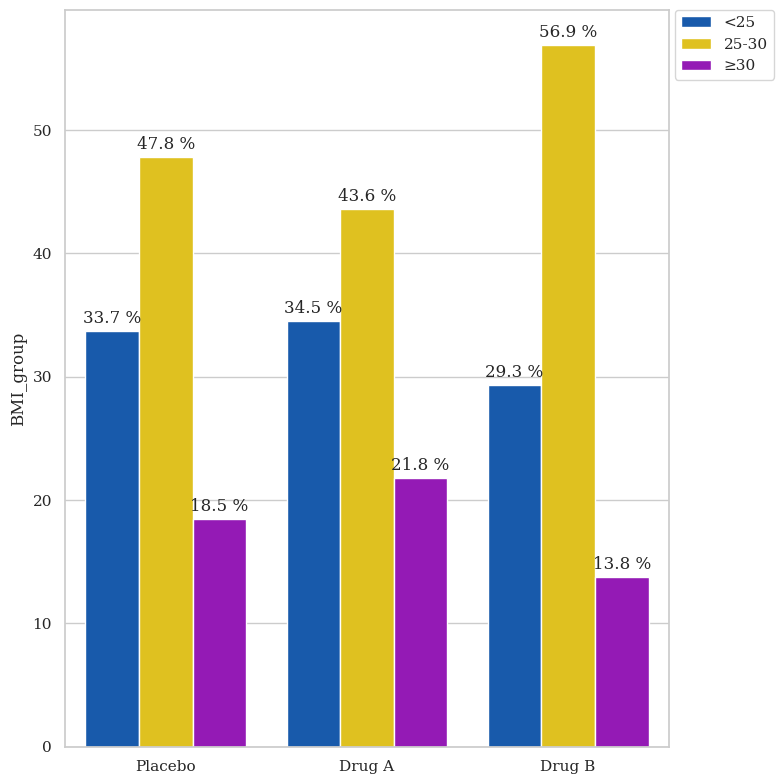

/tmp/ipykernel_70865/102464935.py:102: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(ser)
/tmp/ipykernel_70865/102464935.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.boxplot(
/tmp/ipykernel_70865/102464935.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


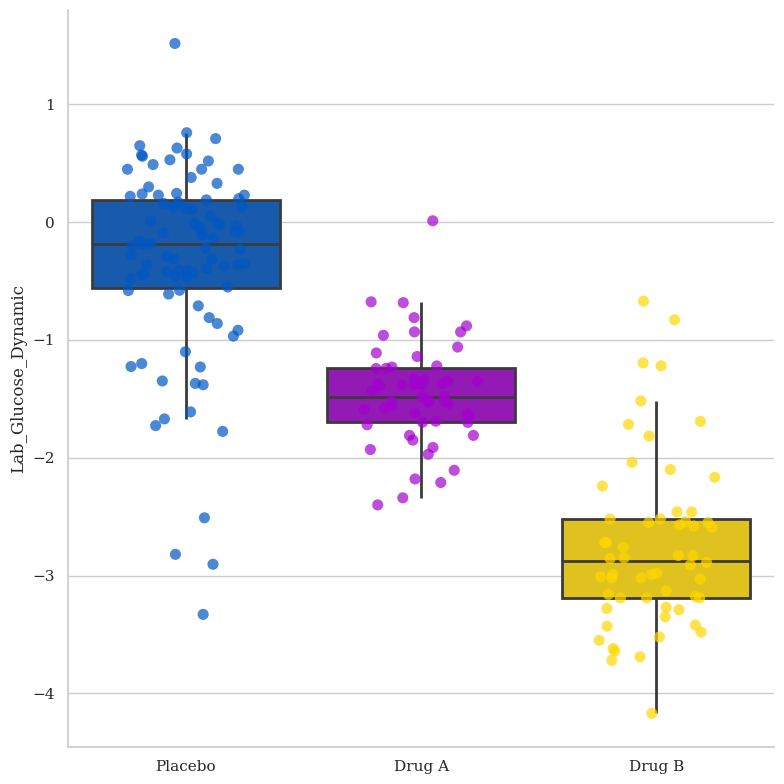

In [61]:
draw_data_frame_group(df_imputed, list(df_imputed.drop('Therapy', axis = 'columns').columns), 'Therapy', pict_sav=False)

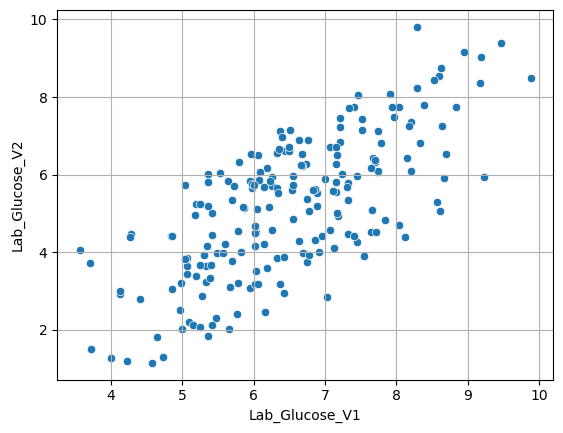

In [497]:
sns.scatterplot(
    x = df_imputed["Lab_Glucose_V1"], y = df_imputed["Lab_Glucose_V2"]
)
plt.grid()

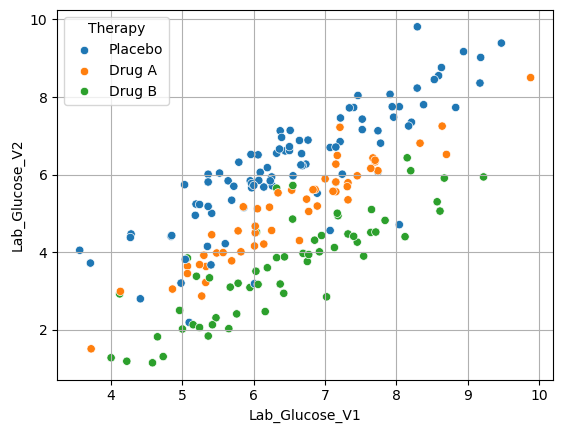

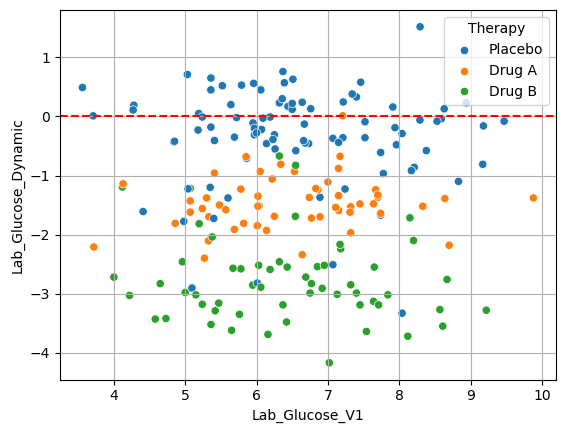

In [498]:
sns.scatterplot(
    x = df_imputed["Lab_Glucose_V1"], y = df_imputed["Lab_Glucose_V2"],
    hue = df_imputed["Therapy"]
)
plt.grid()
plt.show()

sns.scatterplot(
    x = df_imputed["Lab_Glucose_V1"], y = df_imputed["Lab_Glucose_Dynamic"],
    hue = df_imputed["Therapy"]
)
plt.axhline(0, linestyle = "--", color = "red")
plt.grid()
plt.show()

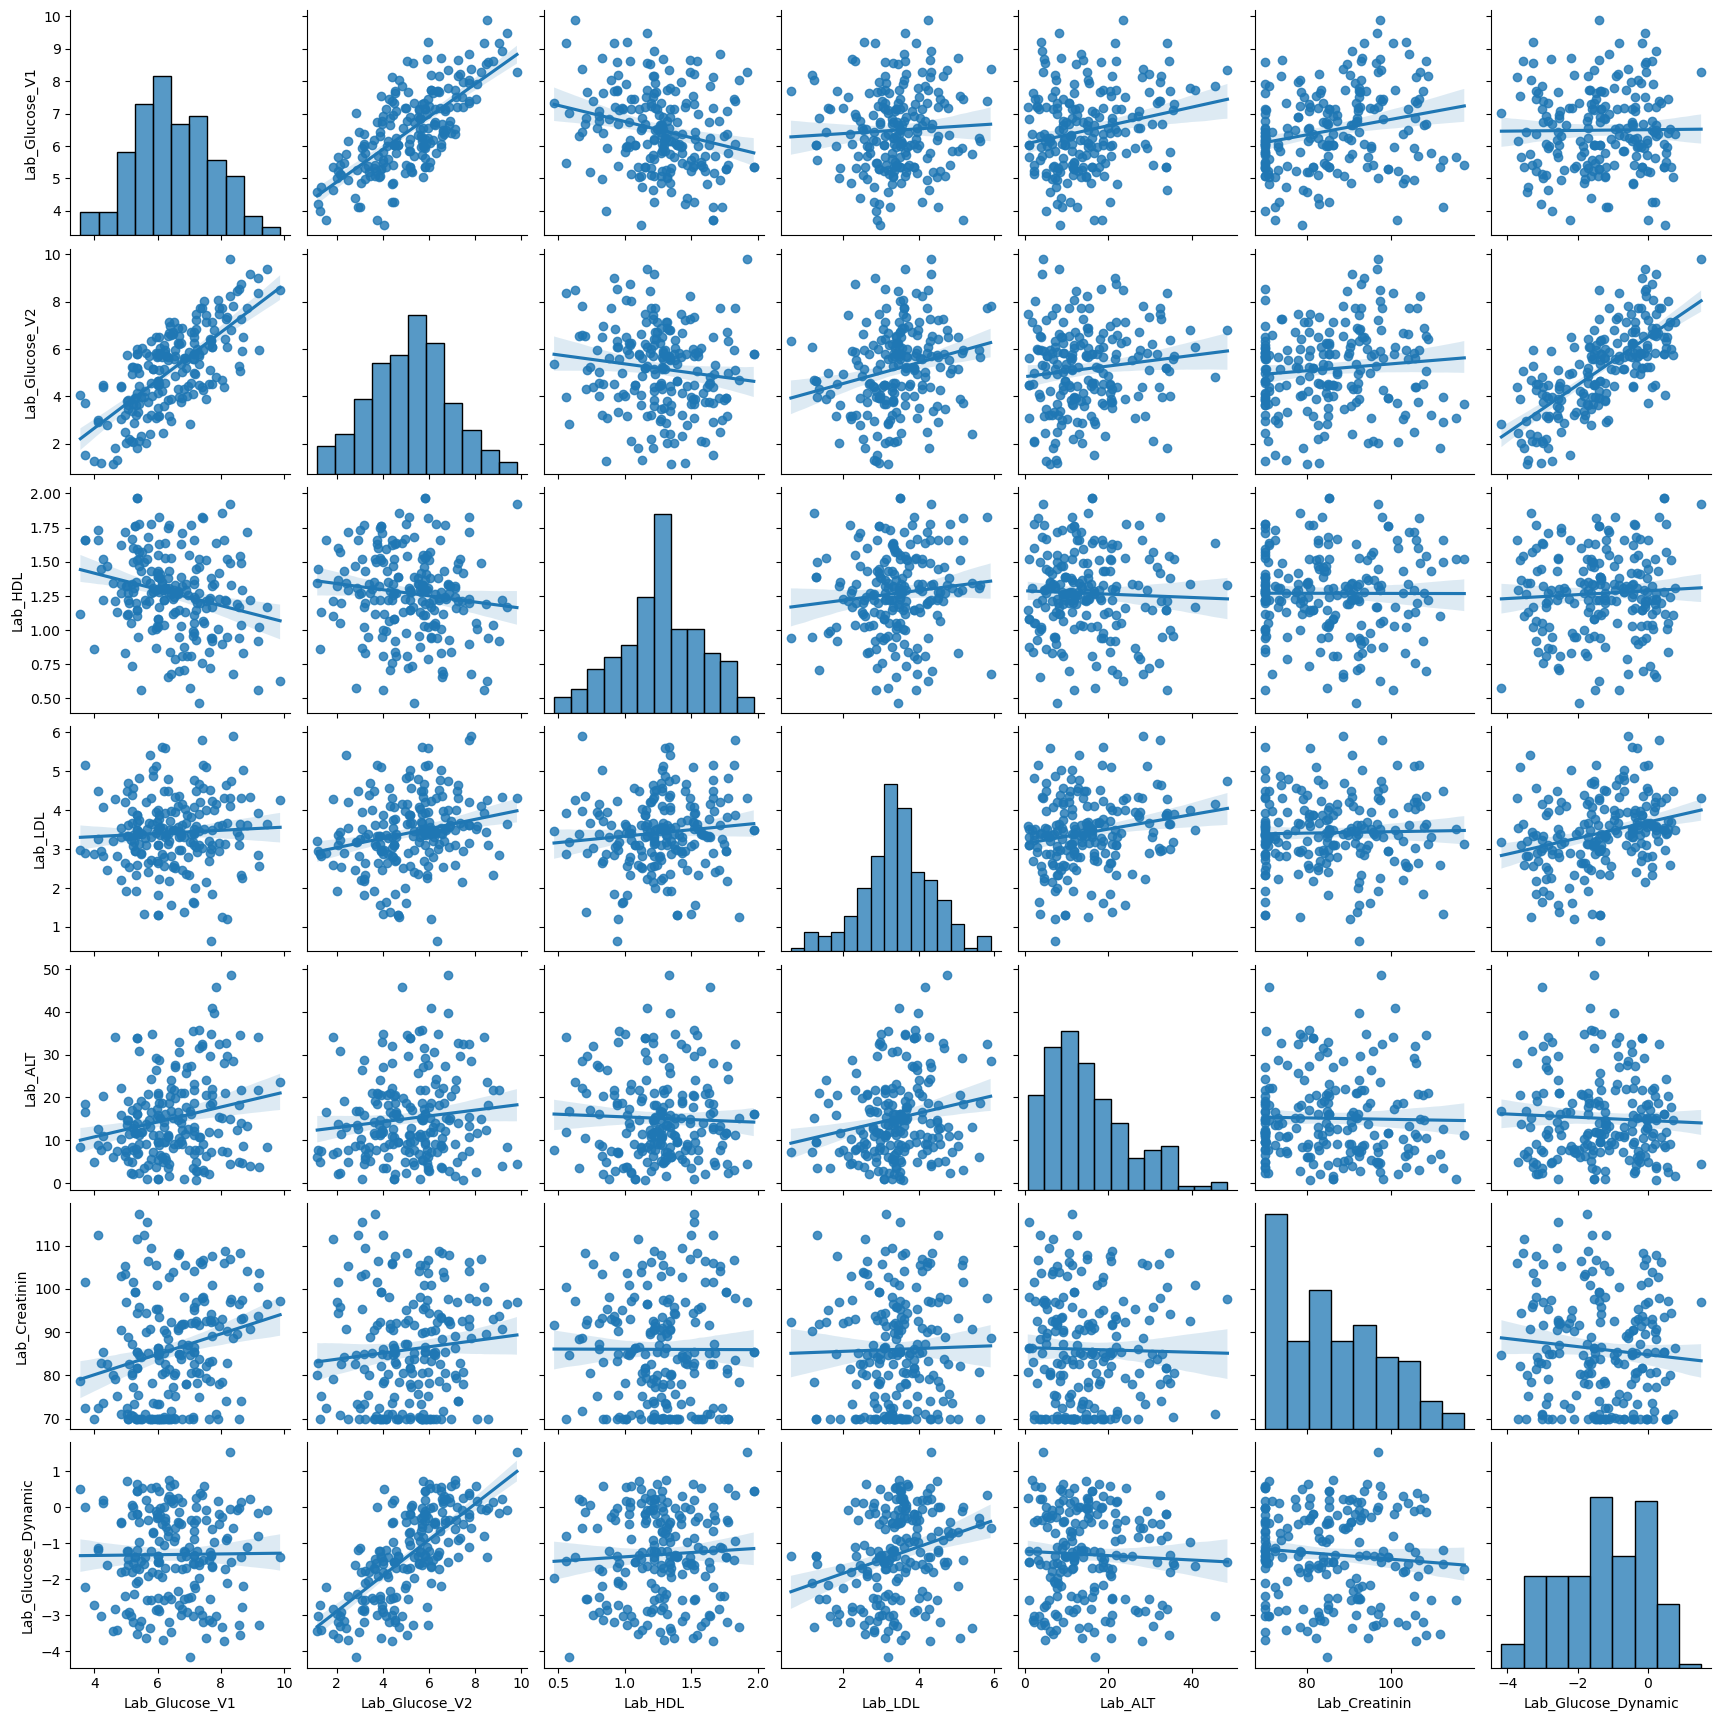

In [499]:
sns.pairplot(df_imputed, kind="reg")
plt.show()

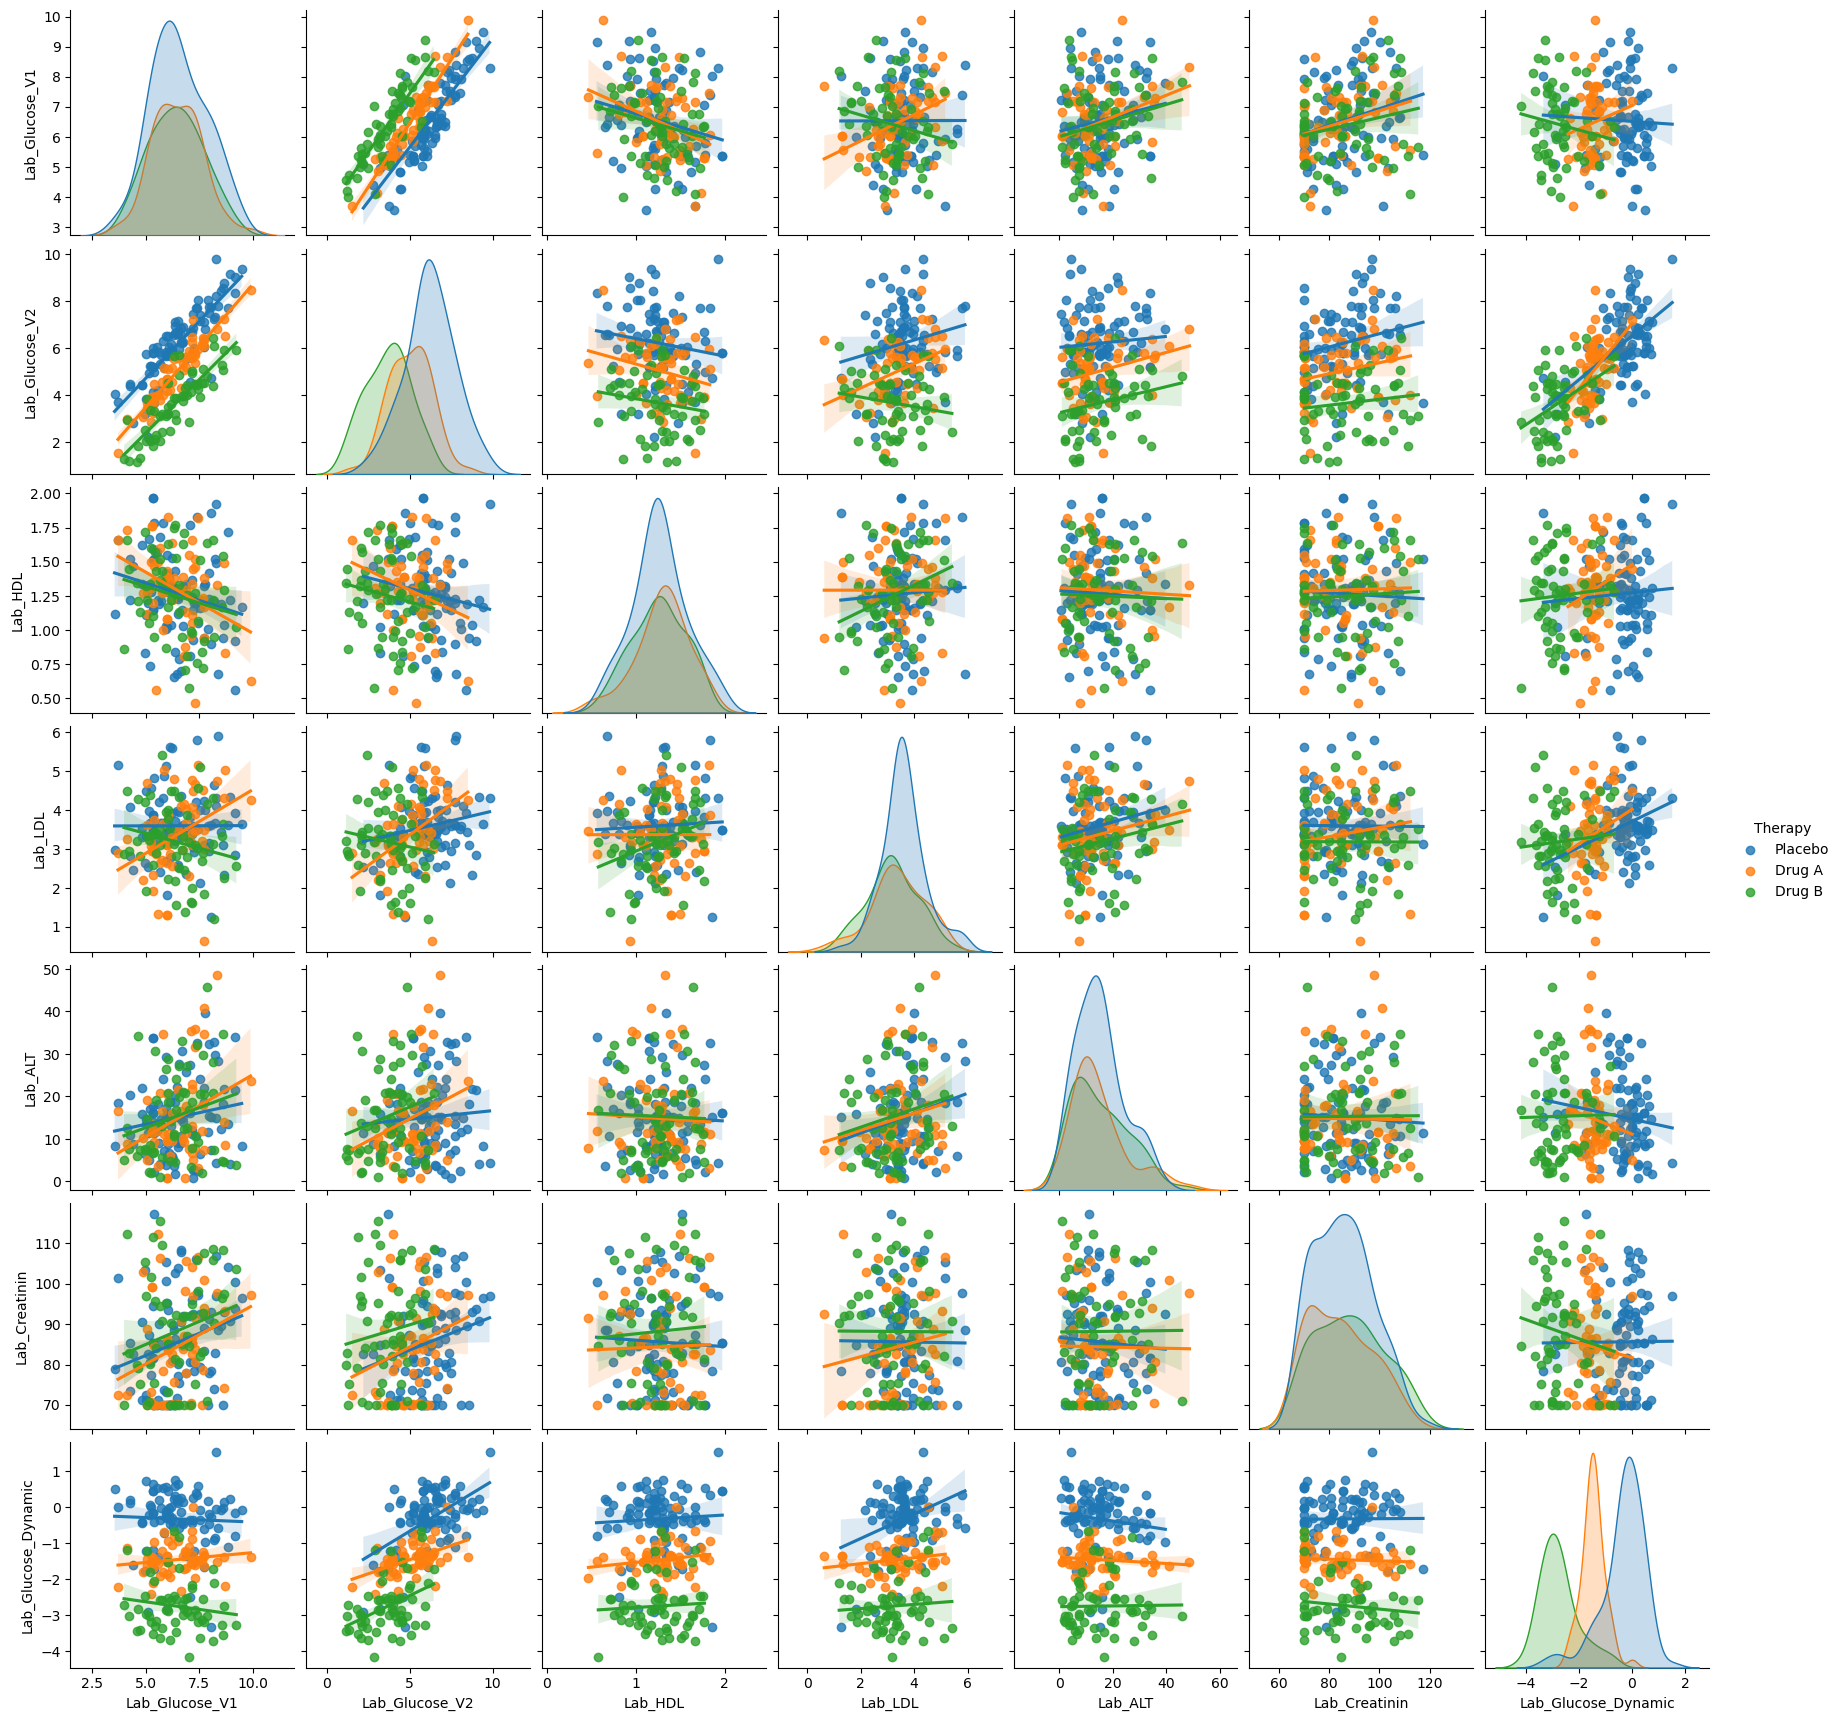

In [500]:
sns.pairplot(df_imputed, kind="reg", hue="Therapy")
plt.show()

In [501]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing          import OneHotEncoder
from sklearn.compose                import ColumnTransformer
from sklearn.pipeline               import Pipeline
from sklearn.utils                  import Bunch
import pandas as pd
import numpy as np

def calc_vif(df: pd.DataFrame,
             target: str,
             thresh: float = 5.0,          # «красная зона»
             drop_const: bool = True) -> Bunch:
    """
    Возвращает DataFrame со значениями VIF и список «проблемных» признаков
    (VIF ≥ thresh).

    Схема:
        •  численные признаки  – без изменений
        •  бинарные            – без изменений (0/1)
        •  номинальные         – OneHot, drop_first
    """
    X = df.drop(columns=[target]).copy()

    # --- делим признаки по типу ----------------------------------------
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    cat_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    # удаляем константы, если нужно
    if drop_const:
        const_cols = [c for c in num_cols if X[c].nunique(dropna=False) <= 1]
        X.drop(columns=const_cols, inplace=True)
        num_cols = [c for c in num_cols if c not in const_cols]

    # --- трансформации --------------------------------------------------
    ct = ColumnTransformer(
        transformers=[
            ("num", "passthrough", num_cols),
            ("cat", OneHotEncoder(drop="first"), cat_cols)
        ],
        remainder="drop"
    )

    X_encoded = ct.fit_transform(X)
    feature_names = (num_cols +
                     list(ct.named_transformers_["cat"].get_feature_names_out(cat_cols)))

    # --- вычисляем VIF --------------------------------------------------
    vif_vals = [variance_inflation_factor(X_encoded, i)
                for i in range(X_encoded.shape[1])]

    vif_tbl = (pd.DataFrame({"Feature": feature_names,
                             "VIF": np.array(vif_vals)})
                 .sort_values("VIF", ascending=False)
                 .reset_index(drop=True))

    return Bunch(vif_table=vif_tbl,
                 low_vif=vif_tbl.loc[vif_tbl["VIF"] < thresh, "Feature"].tolist())

In [502]:
out = calc_vif(df_imputed, target="Lab_Glucose_Dynamic", thresh=5)

print("Топ-10 по VIF:")
display(out.vif_table.head(100))

print("\nПризнаки с VIF < 5:", list(out.low_vif))


Топ-10 по VIF:


,Feature,VIF
0,Lab_Glucose_V1,110.110803
1,Lab_Glucose_V2,63.498534
2,Lab_Creatinin,45.024629
3,Lab_LDL,20.018608
4,Lab_HDL,19.181738
5,Lab_ALT,3.917322
6,Therapy_Placebo,3.799360
7,Therapy_Drug B,3.108201
8,Sex_Male,2.983494
9,BMI_group_<25,1.810513



Признаки с VIF < 5: ['Lab_ALT', 'Therapy_Placebo', 'Therapy_Drug B', 'Sex_Male', 'BMI_group_<25', 'Smoker_Yes', 'Diabetes_Type 2', 'BMI_group_≥30', 'Diabetes_Type 1']


In [440]:
df_imputed[['Lab_Glucose_Dynamic', 'Lab_ALT', 'Therapy', 'Sex', 'BMI_group', 'Smoker', 'Diabetes']]

,Lab_Glucose_Dynamic,Lab_ALT,Therapy,Sex,BMI_group,Smoker,Diabetes
0,0.52,11.900000,Placebo,Female,NaN,Yes,No
1,-2.83,34.200000,Drug B,Female,NaN,No,No
2,-2.58,5.700000,Drug B,Male,NaN,No,Type 2
3,0.24,14.800000,Placebo,Female,NaN,No,Type 2
4,-3.27,4.900000,Drug B,Male,NaN,No,Type 2
...,...,...,...,...,...,...,...
200,-1.52,0.900000,Drug A,Female,NaN,No,No
201,-1.38,11.749368,Drug A,Male,NaN,No,No
202,-1.35,9.600000,Drug A,Male,NaN,No,No
203,-0.18,33.800000,Placebo,Male,NaN,Yes,No


In [408]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [412]:
def univariate_lineareg(df: pd.DataFrame,
                        target: str,
                        predictors: list[str],
                        *,
                        normalize_numeric: bool = True,
                        digits: int = 3) -> pd.DataFrame:
    """
    Однофакторный линейный регрессионный анализ.

    • Для числовых признаков (n unique > 2) – один коэффициент (β);
      при `normalize_numeric=True` предварительно стандартизируется.
    • Для категориальных автоматически создаются dummy-переменные
      (statsmodels: `C(var)`), на каждый уровень → отдельная строка.

    Возвращает таблицу:

    Переменная | Категории | Коэффициент | 95% ДИ | R² | p-значение
    """
    rows = []

    for var in predictors:
        sub = df[[target, var]].dropna()
        if sub.empty:
            continue

        # ── числовой / категориальный? ──────────────────────────────
        is_num = is_numeric_dtype(sub[var]) and sub[var].nunique() > 2
        formula = f"{target} ~ {var}" if is_num else f"{target} ~ C({var})"

        # ── опциональная стандартизация числовых ───────────────────
        if is_num and normalize_numeric:
            mu, sd = sub[var].mean(), sub[var].std(ddof=0)
            if sd > 0:
                sub[var] = (sub[var] - mu) / sd

        # ── модель --------------------------------------------------
        model = smf.ols(formula, data=sub).fit()
        r2   = round(model.rsquared, digits)
        pmod = round(model.f_pvalue, digits)

        # коэффициенты без Intercept
        params = model.params.drop('Intercept', errors='ignore')
        ci     = model.conf_int().drop('Intercept', errors='ignore')

        for coef_name, beta in params.items():
            # ---- расшифровываем название коэффициента -------------
            if is_num:
                cat_label = None
                beta_name = var                       # для CI
            else:
                # пример имени: C(Therapy)[T.Drug A]
                cat_label = coef_name.split('T.', 1)[-1].rstrip(']')
                beta_name = coef_name

            ci_lo, ci_hi = ci.loc[beta_name]

            rows.append({
                "Переменная": var,
                "Категории":  cat_label,
                "Коэффициент": round(beta, digits),
                "95% ДИ": f"[{ci_lo:.{digits}f}; {ci_hi:.{digits}f}]",
                "R²": r2,
                "p-значение": pmod
            })

    return (pd.DataFrame(rows)
              .sort_values("p-значение")
              .reset_index(drop=True))

In [413]:
df_regr = df_imputed[['Lab_Glucose_Dynamic', 'Lab_ALT',
                       'Therapy', 'Sex', 'BMI_group',
                       'Smoker', 'Diabetes']]

table = univariate_lineareg(
    df_regr,
    target="Lab_Glucose_Dynamic",
    predictors=['Lab_ALT', 'Therapy', 'Sex', 'BMI_group', 'Smoker', 'Diabetes'],
    normalize_numeric=True
)

print(table.to_markdown(index=False))

| Переменная   | Категории   |   Коэффициент | 95% ДИ           |    R² |   p-значение |
|:-------------|:------------|--------------:|:-----------------|------:|-------------:|
| Therapy      | Drug B      |        -1.29  | [-1.555; -1.026] | 0.671 |        0     |
| Therapy      | Placebo     |         1.127 | [0.888; 1.366]   | 0.671 |        0     |
| Smoker       | Yes         |         0.586 | [0.167; 1.005]   | 0.036 |        0.006 |
| Lab_ALT      |             |        -0.059 | [-0.230; 0.111]  | 0.002 |        0.494 |
| Diabetes     | Type 1      |         0.217 | [-0.667; 1.102]  | 0.004 |        0.681 |
| Diabetes     | Type 2      |         0.194 | [-0.305; 0.693]  | 0.004 |        0.681 |
| BMI_group    | <25         |         0.154 | [-0.231; 0.539]  | 0.003 |        0.734 |
| BMI_group    | ≥30         |         0.064 | [-0.406; 0.534]  | 0.003 |        0.734 |
| Sex          | Male        |        -0.033 | [-0.391; 0.324]  | 0     |        0.856 |


In [503]:
formula = f"Lab_Glucose_Dynamic ~ C(Therapy) + C(Smoker)"
model = smf.ols(formula, data=df_regr).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     Lab_Glucose_Dynamic   R-squared:                       0.680
Model:                             OLS   Adj. R-squared:                  0.675
Method:                  Least Squares   F-statistic:                     142.4
Date:                  Пт, 19 сен 2025   Prob (F-statistic):           1.68e-49
Time:                         17:20:52   Log-Likelihood:                -217.07
No. Observations:                  205   AIC:                             442.1
Df Residuals:                      201   BIC:                             455.4
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -1.5111      0.098    -15.477      0.000      -1.704      -1.319
C(Therapy)[T.Drug B]     -1.2776      0.133     -9.627      0.000      -1.539      -1.016
C(Therapy)[T.Placebo]     1.1072      0.120      9.197      0.000       0.870       1.345
C(Smoker)[T.Yes]          0.2909      0.124      2.347      0.020       0.047       0.535
==============================================================================
Omnibus:                       28.629   Durbin-Watson:                   1.923
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               70.577
Skew:                          -0.603   Prob(JB):                     4.72e-16
Kurtosis:                       5.609   Cond. No.                         4.26
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [504]:
def regression_report(y_true,
                      y_pred,
                      *,
                      title: str = "Real vs. Predicted",
                      figsize_scatter=(6, 6),
                      figsize_hist=(6, 6),
                      figsize_qq=(6, 6),
                      dpi: int = 100) -> pd.Series:
    """
    Сводка по модели + 3 графика:
      1. Observed vs. Predicted  (диагональ 45°)
      2. Гистограмма остатков
      3. QQ-plot остатков

    Возвращает Series с основными метриками.
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    if y_true.shape != y_pred.shape:
        raise ValueError("`y_true` и `y_pred` разной длины")

    resid = y_true - y_pred

    # ── метрики ---------------------------------------------------------
    med_err = np.median(resid)
    mean_err = resid.mean()
    max_abs = np.abs(resid).max()
    desc = pd.Series(resid).describe([.25, .5, .75])
    resid_std = resid.std(ddof=1)

    metrics = pd.Series({
        "Median error":   med_err,
        "Mean error":     mean_err,
        "Max |error|":    max_abs,
        "Residual min":   desc["min"],
        "Residual Q1":    desc["25%"],
        "Residual median":desc["50%"],
        "Residual Q3":    desc["75%"],
        "Residual max":   desc["max"],
        "Residual std":   resid_std
    }).round(4)

    # =====================  PLOTS  =====================================

    # 1) Observed vs Predicted
    plt.figure(figsize=figsize_scatter, dpi=dpi)
    sns.scatterplot(x=y_true, y=y_pred, alpha=.7)
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, '--', color='royalblue')
    plt.xlim(lims); plt.ylim(lims)
    plt.gca().set_aspect('equal', 'box')
    plt.xlabel("Observed"); plt.ylabel("Predicted")
    plt.title(title)
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

    # 2) Histogram of residuals
    plt.figure(figsize=figsize_hist, dpi=dpi)
    sns.histplot(resid, kde=True, bins="auto", color="#888888")
    plt.xlabel("Residuals (Observed – Predicted)")
    plt.title("Residual histogram")
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

    # 3) QQ-plot
    plt.figure(figsize=figsize_qq, dpi=dpi)
    sm.qqplot(resid, line="s", ax=plt.gca(), color="#d62728")
    plt.title("QQ-plot of residuals")
    plt.grid(alpha=.2)
    plt.tight_layout()
    plt.show()

    return metrics

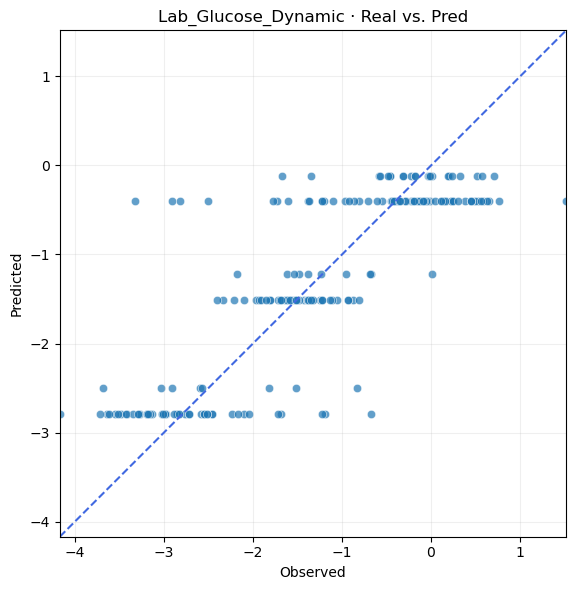

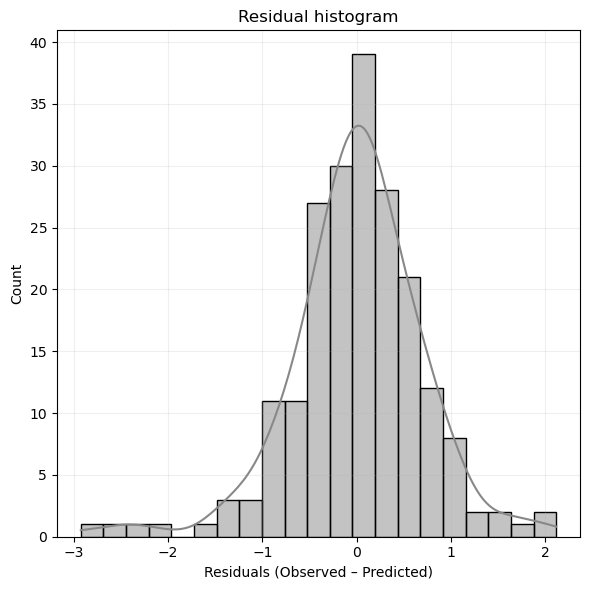

/home/guest/anaconda3/envs/mlenv_test/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


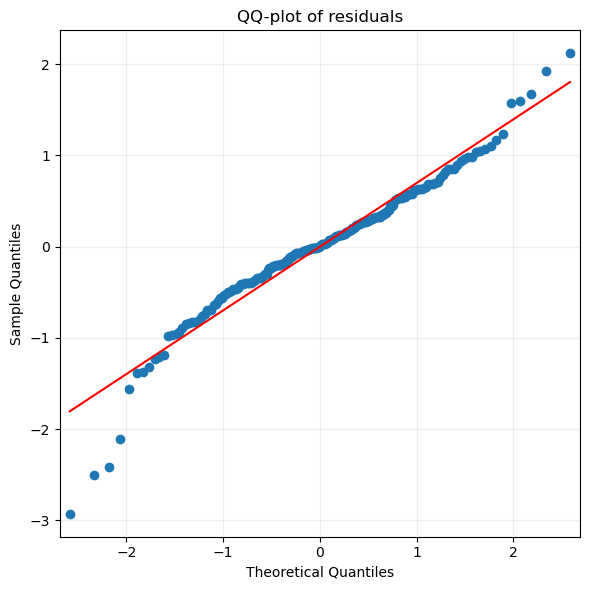

Median error       0.0111
Mean error         0.0000
Max |error|        2.9261
Residual min      -2.9261
Residual Q1       -0.3670
Residual median    0.0111
Residual Q3        0.3639
Residual max       2.1188
Residual std       0.6993
dtype: float64


In [ ]:
y_true = df_imputed["Lab_Glucose_Dynamic"]
y_pred = model.predict(df_imputed[['Therapy', 'Smoker']])

report = regression_report(y_true, y_pred,
                           title="Lab_Glucose_Dynamic · Real vs. Pred")
print(report)



## **Логистическая регрессия и введение клинически разумного порога**

Введем клинически разумный порог о том, что клинически значимое изменение глюкозы, например, снижение на **-2 ммоль/л**

Такой порог устанавливают исследователи на основании рекомендаций, литературного поиска, решения экспертной панели и т.д. Клинический порог должен всегда быть обоснован. 

In [520]:
df_imputed['Lab_Glucose_Dynamic_Cat'] = pd.Categorical((df_imputed['Lab_Glucose_Dynamic'] > -2).astype(int))

In [521]:
compare_all(df_imputed[['Lab_Glucose_Dynamic_Cat', "Therapy"]], "Therapy")

/tmp/ipykernel_1883815/2295281768.py:85: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(wk[group_var]):
/tmp/ipykernel_1883815/2295281768.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  valid_n = (wk.groupby(group_var)[var]


,id,Фактор,Статистика,Placebo,Drug A,Drug B,n1,n2,n3,Статистический тест,"Значимость, р"
0,1,Lab_Glucose_Dynamic_Cat,1,88 (95.7%),50 (90.9%),8 (13.8%),92,55,58,Точный тест Фишера (R),0.000
1,2,,0,4 (4.3%),5 (9.1%),50 (86.2%),92,55,58,,


In [522]:
pairwise_comparisons(df_imputed[['Lab_Glucose_Dynamic_Cat', "Therapy"]], "Therapy", "holm")

,id,Factor,Placebo - Drug B,Placebo - Drug A,Drug B - Drug A
0,1,Lab_Glucose_Dynamic_Cat,0.0,0.295,0.0


In [ ]:
def univariate_logreg(df: pd.DataFrame,
                      target: str,
                      predictors: list[str],
                      *,
                      normalize_numeric: bool = True,
                      digits: int = 3) -> pd.DataFrame:
    """
    Однофакторный ЛОГИСТИЧЕСКИЙ регрессионный анализ
    (binary outcome 0/1).

    Таблица-вывод
    -------------
    Переменная | Категории | Отношение шансов | 95% ДИ | R² | p-значение

    • Для числовых признаков (n>2 уникальных) можно стандартизировать.
    • Для категориальных автоматически строятся dummy-переменные
      (statsmodels:  C(var) ).
    • OR и доверительный интервал получаются из exp(coef ± CI).
    • Pseudo-R² = McFadden (model.prsquared).
    • p-value – LRT p-value (model.llr_pvalue).
    """
    rows = []

    for var in predictors:
        sub = df[[target, var]].dropna()
        if sub.empty:
            continue

        # —- определяем тип признака
        is_num = is_numeric_dtype(sub[var]) and sub[var].nunique() > 2
        formula = f"{target} ~ {var}" if is_num else f"{target} ~ C({var})"

        # —- стандартизация числовых
        if is_num and normalize_numeric:
            mu, sd = sub[var].mean(), sub[var].std(ddof=0)
            if sd > 0:
                sub[var] = (sub[var] - mu) / sd

        # —- логистическая модель
        try:
            model = smf.logit(formula, data=sub).fit(disp=False)
        except Exception as e:            # например perfect separation
            print(f"{var}: не удалось подогнать модель ({e})")
            continue

        pseudo_r2 = round(model.prsquared, digits)
        pmod      = round(model.llr_pvalue, digits)

        # коэффициенты без интерсепта
        params = model.params.drop("Intercept", errors="ignore")
        ci     = model.conf_int().drop("Intercept", errors="ignore")

        for coef_name, beta in params.items():
            if is_num:
                cat_label = None
                idx_name  = var            # ключ для CI
            else:
                # название вида C(var)[T.level]
                cat_label = coef_name.split("T.", 1)[-1].rstrip("]")
                idx_name  = coef_name

            ci_lo, ci_hi = ci.loc[idx_name]

            rows.append({
                "Переменная": var,
                "Категории":  cat_label,
                "Отношение шансов": round(np.exp(beta), digits),
                "95% ДИ": f"[{np.exp(ci_lo):.{digits}f}; {np.exp(ci_hi):.{digits}f}]",
                "R²": pseudo_r2,
                "p-значение": pmod
            })

    return (pd.DataFrame(rows)
              .sort_values("p-значение")
              .reset_index(drop=True))

In [523]:
predictors = ['Lab_ALT', 'Therapy', 'Sex', 'BMI_group', 'Smoker', 'Diabetes']
df_imputed['Lab_Glucose_Dynamic_Cat'] = pd.to_numeric(df_imputed['Lab_Glucose_Dynamic_Cat'])

out_tbl = univariate_logreg(df_imputed,
                            target='Lab_Glucose_Dynamic_Cat',      # бинарный таргет 0/1
                            predictors=predictors,
                            normalize_numeric=True)

print(out_tbl.to_markdown(index=False))

| Переменная   | Категории   |   Отношение шансов | 95% ДИ         |    R² |   p-значение |
|:-------------|:------------|-------------------:|:---------------|------:|-------------:|
| Therapy      | Drug A      |              0.455 | [0.117; 1.771] | 0.541 |        0     |
| Therapy      | Drug B      |              0.007 | [0.002; 0.025] | 0.541 |        0     |
| Smoker       | Yes         |              2.785 | [1.104; 7.030] | 0.023 |        0.019 |
| BMI_group    | 25-30       |              0.701 | [0.352; 1.396] | 0.006 |        0.475 |
| BMI_group    | ≥30         |              1.058 | [0.417; 2.684] | 0.006 |        0.475 |
| Diabetes     | Type 1      |              1.297 | [0.253; 6.642] | 0.004 |        0.607 |
| Diabetes     | Type 2      |              1.585 | [0.606; 4.141] | 0.004 |        0.607 |
| Lab_ALT      |             |              1.033 | [0.762; 1.400] | 0     |        0.835 |
| Sex          | Male        |              1.029 | [0.547; 1.937] | 0     |    

In [533]:
formula = f"Lab_Glucose_Dynamic_Cat ~ C(Therapy) + C(Smoker)"
model = smf.logit(formula, data=df_imputed).fit()
print(model.summary2())
summ = model.summary2()
tab  = summ.tables[1]                         # коэффициенты
tab["OR"]      = np.exp(tab["Coef."])
tab["OR_low"]  = np.exp(tab["[0.025"])
tab["OR_high"] = np.exp(tab["0.975]"])
print(tab[["OR","OR_low","OR_high","P>|z|"]][1:].round(3))

Optimization terminated successfully.
         Current function value: 0.266324
         Iterations 7
                             Results: Logit
Model:              Logit                   Method:           MLE       
Dependent Variable: Lab_Glucose_Dynamic_Cat Pseudo R-squared: 0.556     
Date:               2025-09-19 18:00        AIC:              117.1928  
No. Observations:   205                     BIC:              130.4849  
Df Model:           3                       Log-Likelihood:   -54.596   
Df Residuals:       201                     LL-Null:          -123.04   
Converged:          1.0000                  LLR p-value:      1.7800e-29
No. Iterations:     7.0000                  Scale:            1.0000    
------------------------------------------------------------------------
                          Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------------
Intercept                 2.8764   0.5167  5.5670 0

Функции:

In [7]:
###############################################################################
#  SUMMARY TABLE (numeric + categorical-by-level)
###############################################################################
import pandas as pd
import numpy as np
from scipy.stats import shapiro


def _table_shapiro(df, digits):
    """Return p-values of Shapiro–Wilk for every numeric column."""
    num_cols = df.select_dtypes(include=[np.number]).columns
    pvals = {
        col: (shapiro(df[col].dropna())[1]          # p-value
              if 3 <= df[col].notna().sum() <= 5000 else np.nan)
        for col in num_cols
    }
    return (
        pd.Series(pvals, name="Тест Ш-У, значимость")
        .round(digits)
        .reset_index()
        .rename(columns={"index": "Показатель"})
    )


def _fmt_mean_sd(series, d):      # mean ± sd
    return f"{series.mean():.{d}f} ± {series.std(ddof=1):.{d}f}" if series.size else "NA"


def _fmt_median_iqr(series, d):   # median [p25; p75]
    if series.size == 0:
        return "NA"
    q25, q75 = np.percentile(series, [25, 75])
    return f"{series.median():.{d}f} [{q25:.{d}f}; {q75:.{d}f}]"


def _fmt_min(series, d):          # min with NA fallback
    return f"{series.min():.{d}f}" if series.size else "NA"


def _fmt_max(series, d):          # max with NA fallback
    return f"{series.max():.{d}f}" if series.size else "NA"


def _fmt_n_pct(n, total, d):
    pct = n / total * 100 if total else 0
    return f"{n} ({pct:.{d}f}%)"


def summary_all(data: pd.DataFrame, digits: int = 1) -> pd.DataFrame:
    """Mimic the R `summary_all()` with per-level rows for categoricals."""
    # 1. Normality test on numeric columns
    shapiro_df = _table_shapiro(data, digits)

    rows = []

    for col in data.columns:
        s = data[col].dropna()
        total_n = s.size
        is_num = pd.api.types.is_numeric_dtype(s)

        # -------- NUMERIC --------------------------------------------------
        if is_num:
            rows.append(
                {
                    "Показатель": col,
                    "Валидные,N": total_n,
                    "Абс,доля,%": "-",
                    "Среднее, ст.откл": _fmt_mean_sd(s, digits),
                    "Медиана и размахи": _fmt_median_iqr(s, digits),
                    "Мин": _fmt_min(s, digits),
                    "Макс": _fmt_max(s, digits),
                }
            )
        # -------- CATEGORICAL ----------------------------------------------
        else:
            # header-like line for the variable itself
            rows.append(
                {
                    "Показатель": col,
                    "Валидные,N": "NA",
                    "Абс,доля,%": "NA",
                    "Среднее, ст.откл": "NA",
                    "Медиана и размахи": "NA",
                    "Мин": "NA",
                    "Макс": "NA",
                }
            )

            # one row per category
            counts = s.value_counts(dropna=False).sort_index()
            for level, n in counts.items():
                level_name = str(level)
                rows.append(
                    {
                        "Показатель": level_name,
                        "Валидные,N": total_n,
                        "Абс,доля,%": _fmt_n_pct(n, total_n, digits),
                        "Среднее, ст.откл": "-",
                        "Медиана и размахи": "-",
                        "Мин": "-",
                        "Макс": "-",
                    }
                )

    # 2. Build DataFrame
    df = pd.DataFrame(rows)

    # 3. Merge with Shapiro p-values → only numeric rows keep the number
    df = df.merge(shapiro_df, on="Показатель", how="left")

    # 4. Add running index & reorder columns
    df.insert(0, "Индекс", range(1, len(df) + 1))
    final_cols = [
        "Индекс",
        "Показатель",
        "Валидные,N",
        "Абс,доля,%",
        "Среднее, ст.откл",
        "Медиана и размахи",
        "Мин",
        "Макс",
        "Тест Ш-У, значимость",
    ]
    return df[final_cols]

In [63]:
summary_all(df)

,Индекс,Показатель,"Валидные,N","Абс,доля,%","Среднее, ст.откл",Медиана и размахи,Мин,Макс,"Тест Ш-У, значимость"
0,1,Group,NA,NA,NA,NA,NA,NA,NaN
1,2,Group_A,80,20 (25.0%),-,-,-,-,NaN
2,3,Group_B,80,20 (25.0%),-,-,-,-,NaN
3,4,Group_C,80,20 (25.0%),-,-,-,-,NaN
4,5,Group_D,80,20 (25.0%),-,-,-,-,NaN
5,6,Numeric_1,80,-,46.6 ± 30.6,43.6 [18.4; 74.2],0.6,98.7,0.0
6,7,Numeric_2,80,-,18.9 ± 18.1,13.5 [5.7; 28.3],0.1,84.9,0.0
7,8,Numeric_3,80,-,50.4 ± 14.0,52.7 [37.7; 58.5],25.9,90.8,0.1
8,9,Numeric_4,80,-,48.0 ± 27.8,50.6 [26.6; 70.3],1.4,97.6,0.0
9,10,Numeric_5,80,-,20.9 ± 18.9,16.5 [6.9; 31.2],0.2,93.1,0.0


In [12]:
import pandas as pd


def factor_transformer(data_frame: pd.DataFrame,
                       min_factor_levels: int = 7) -> pd.DataFrame:
    """
    Convert every column that has ≤ `min_factor_levels` distinct non-NA values
    to pandas 'category' type (using pd.Categorical) and return the new frame.

    Parameters
    ----------
    data_frame : pd.DataFrame
        Source data.
    min_factor_levels : int, default 7
        Upper threshold for the number of distinct levels
        at or below which a column becomes categorical.

    Returns
    -------
    pd.DataFrame
        A copy of `data_frame` with selected columns converted
        to categorical dtype.
    """
    # 1. Count distinct non-missing values per column
    unique_counts = data_frame.nunique(dropna=True)

    # 2. Columns that meet the threshold
    cols_to_convert = unique_counts[unique_counts <= min_factor_levels].index

    # 3. Build and return a copy with those columns cast to category
    return data_frame.assign(
        **{col: pd.Categorical(data_frame[col]) for col in cols_to_convert}
    )



In [61]:
import re
import numpy as np
import pandas as pd
from scipy import stats


def fisher_exact_r(cont: pd.DataFrame, seed=1000) -> tuple[str, float | None]:
    """
    Run Fisher's exact test via R for ANY sized contingency table with sparse cells.
    Uses simulation for larger tables to avoid computational issues.
    
    Parameters
    ----------
    cont : pd.DataFrame - contingency table of any size (m × n)
    seed : int - random seed for reproducibility
    
    Returns
    -------
    (test_name, p_value)
    """
    np.random.seed(seed)
    try:
        import rpy2.robjects as ro
        from rpy2.robjects import pandas2ri
        from rpy2.robjects.packages import importr

        # Activate pandas-to-R conversion
        pandas2ri.activate()
        stats_r = importr('stats')
        
        # Convert the contingency table to an R matrix
        r_matrix = pandas2ri.py2rpy(cont)
        
        # For 2×k tables use exact method
        if cont.shape[0] == 2:
            result = stats_r.fisher_test(r_matrix)
            p_value = result.rx2('p.value')[0]
            return "Точный тест Фишера (R)", float(p_value)
        
        # For larger tables use Monte Carlo simulation
        else:
            ro.r(f'set.seed({seed})')
            result = stats_r.fisher_test(r_matrix, simulate_p_value=True)
            p_value = result.rx2('p.value')[0]
            return "Точный тест Фишера (R, симуляция)", float(p_value)
            
    except Exception as e:
        # Fallback to chi-square with correction
        chi2, p_val, *_ = stats.chi2_contingency(cont, correction=True)
        return f"R не найден → Χ²-тест", p_val


def _shapiro_ok(x: np.ndarray) -> bool:
    """TRUE ⇢ p > .05 (looks Normal) – reproduces R part."""
    x = x[~np.isnan(x)]
    if x.size < 3 or x.size > 5000 or np.unique(x).size < 3:
        return False
    try:
        return stats.shapiro(x).pvalue > 0.05
    except Exception:
        return False


def compare_all(
    df: pd.DataFrame,
    group_var: str,
    digits: int = 1,
    add_minmax: bool = False,
) -> pd.DataFrame:
    """
    Python re-implementation of the R function `compare_all`.

    Parameters
    ----------
    df         : pd.DataFrame
    group_var  : str              – name of the grouping column
    digits     : int, default 1   – decimals in formatted output
    add_minmax : bool, default False
                                   – include 'min-max' row for numerics

    Returns
    -------
    pd.DataFrame – summary table (ready for copy/paste to docs)
    """
    # ------------------------------------------------------------ #
    # 0. Preparation                                               #
    # ------------------------------------------------------------ #
    wk = df.copy(deep=True)   # never touch the caller's frame!

    # keep the original order of groups (factor levels first, else order of appearance)
    if pd.api.types.is_categorical_dtype(wk[group_var]):
        groups = list(wk[group_var].cat.categories)
    else:
        groups = list(pd.unique(wk[group_var]))
    n_groups = len(groups)

    # temporary fix: columns starting with a digit -> prepend 'firstnum_'
    newcols = {
        col: f"firstnum_{col}" if re.match(r"^\d", str(col)) else col
        for col in wk.columns
    }
    wk.rename(columns=newcols, inplace=True)

    # mapping to restore names only for the 'Фактор' column later
    reverse_fix = {v: k for k, v in newcols.items()}

    # helper format strings
    fmt_mean_sd = lambda m, s: f"{m:.{digits}f} ± {s:.{digits}f}"
    fmt_med_iqr = lambda d, q1, q3: f"{d:.{digits}f} [{q1:.{digits}f}, {q3:.{digits}f}]"
    fmt_minmax = lambda mn, mx: f"({mn:.{digits}f}; {mx:.{digits}f})"
    fmt_pval = lambda p: f"{p:.3f}" if p is not None and not np.isnan(p) else ""

    rows = []
    row_id = 1

    # ------------------------------------------------------------ #
    # 1. Iterate over every variable except the group var          #
    # ------------------------------------------------------------ #
    for var in [c for c in wk.columns if c != group_var]:

        col_ser = wk[var]
        # ---------- NUMERIC ------------------------------------------------
        if pd.api.types.is_numeric_dtype(col_ser):

            # per-group descriptive stats
            desc = (
                wk.groupby(group_var)[var]
                .agg(
                    mean="mean",
                    sd="std",
                    median="median",
                    q1=lambda x: x.quantile(0.25),
                    q3=lambda x: x.quantile(0.75),
                    mn="min",
                    mx="max",
                    N=lambda x: x.notna().sum(),
                )
                .reindex(groups)  # keep original order
            )

            # global normality decision
            is_normal = all(_shapiro_ok(wk.loc[wk[group_var] == g, var].to_numpy())
                            for g in groups)

            # choose the right inferential test
            p_val = None
            test_name = ""
            # all groups must contain at least 2 distinct values
            valid_groups = [
                wk.loc[wk[group_var] == g, var].dropna().nunique() > 1 for g in groups
            ]

            if not all(valid_groups):
                test_name = "Недостаточно данных (нулевая дисперсия в группе)"
            else:
                try:
                    if n_groups == 2:
                        g1, g2 = [wk.loc[wk[group_var] == g, var].dropna() for g in groups]
                        if is_normal:
                            p_val = stats.ttest_ind(g1, g2, equal_var=False).pvalue
                            test_name = "t-тест Стьюдента"
                        else:
                            p_val = stats.mannwhitneyu(g1, g2, alternative="two-sided").pvalue
                            test_name = "Тест Вилкоксона"
                    else:  # > 2 groups
                        arrays = [wk.loc[wk[group_var] == g, var].dropna() for g in groups]
                        if any(len(a) <= 1 for a in arrays):
                            test_name = "Невозможно выполнить тест: недостаточно наблюдений"
                        elif is_normal:
                            p_val = stats.f_oneway(*arrays).pvalue
                            test_name = "ANOVA"
                        else:
                            p_val = stats.kruskal(*arrays).pvalue
                            test_name = "Тест Краскела-Уоллиса"
                except Exception:
                    test_name = "Ошибка при выполнении теста"
                    p_val = None

            # ---------- assemble rows ----------------------------------
            stat_rows = [
                ("среднее ± СО",
                 [fmt_mean_sd(desc.loc[g, 'mean'], desc.loc[g, 'sd']) for g in groups]),
                ("медиана [25%; 75%]",
                 [fmt_med_iqr(desc.loc[g, 'median'], desc.loc[g, 'q1'], desc.loc[g, 'q3'])
                  for g in groups]),
            ]
            if add_minmax:
                stat_rows.append(
                    ("Мин - Макс",
                     [fmt_minmax(desc.loc[g, 'mn'], desc.loc[g, 'mx']) for g in groups])
                )

            for ix, (stat_name, stat_values) in enumerate(stat_rows):
                row = {
                    "id": row_id,
                    "Фактор": var if ix == 0 else "",
                    "Статистика": stat_name,
                    **{g: stat_values[i] for i, g in enumerate(groups)},
                    **{f"n{i+1}": int(desc.loc[groups[i], "N"]) for i in range(n_groups)},
                    "test_used": test_name if ix == 0 else "",
                    "p_value": fmt_pval(p_val) if ix == 0 else "",
                }
                rows.append(row)
                row_id += 1

        # ---------- CATEGORICAL (factor) -----------------------------------
        else:
            levels = pd.unique(col_ser.dropna())
            cont = pd.crosstab(wk[var], wk[group_var], dropna=True) \
                    .reindex(index=levels, columns=groups, fill_value=0)

            # ------- choose the inferential test -------------------------
            if cont.shape[0] < 2 or cont.shape[1] < 2:
                test_name, p_val = "Недостаточно данных для теста", None

            # Any table with sparse cells - use Fisher's test via R
            elif (cont.values < 5).any():
                test_name, p_val = fisher_exact_r(cont)

            else:
                # Well-populated table - use regular chi-square
                chi2, p_val, *_ = stats.chi2_contingency(cont)
                test_name = "Χ²-тест"

            # group-wise denominators
            valid_n = wk.groupby(group_var)[var] \
                        .count().reindex(groups).fillna(0).astype(int)

            # -------- one output row per category level ------------------
            for j, level in enumerate(levels):
                counts = cont.loc[level]
                row = {
                    "id": row_id,
                    "Фактор": var if j == 0 else "",
                    "Статистика": level,
                    **{
                        g: f"{counts[g]} "
                           f"({(counts[g]/valid_n[g]*100 if valid_n[g] else 0):.{digits}f}%)"
                        for g in groups
                    },
                    **{f"n{i+1}": int(valid_n[groups[i]]) for i in range(n_groups)},
                    "test_used": test_name if j == 0 else "",
                    "p_value": (f"{p_val:.3f}" if j == 0 and p_val is not None else "")
                }
                rows.append(row)
                row_id += 1

    # ------------------------------------------------------------ #
    # 2. Wrap-up                                                  #
    # ------------------------------------------------------------ #
    out = pd.DataFrame(rows)

    # Final column order
    out = out[
        ["id", "Фактор", "Статистика", *groups,
         *[f"n{i+1}" for i in range(n_groups)], "test_used", "p_value"]
    ]

    # polish column headers
    out.rename(columns={
        "test_used": "Статистический тест",
        "p_value": "Значимость, р"
    }, inplace=True)

    # restore original variable names (remove the temporary prefix)
    out["Фактор"] = out["Фактор"].replace(reverse_fix)

    return out

In [97]:
# ---------------------------------------------------------------
#  Pairwise group–wise comparisons (Python version of the R helper)
# ---------------------------------------------------------------
import warnings
from itertools import combinations
from typing import List

import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype
from scipy import stats
from statsmodels.stats import multitest


# ----------------------------------------------------------------
#  We assume the universal Fisher helper is already in memory
#     from fisher_exact_r import fisher_exact_r
# ----------------------------------------------------------------


def _pair_names(groups: List[str]) -> List[str]:
    """Return ``['g1 - g2', 'g1 - g3', …]`` in the order of combinations."""
    return [f"{g1} - {g2}" for g1, g2 in combinations(groups, 2)]


def pairwise_comparisons(
        data: pd.DataFrame,
        group_var: str,
        p_adjust_method: str = "none"
) -> pd.DataFrame:
    """
    Perform pairwise comparisons (numeric & categorical) for every variable
    against a multi-level grouping factor.

    Parameters
    ----------
    data : pd.DataFrame
    group_var : str
        Column name that defines the groups (must contain >2 levels).
    p_adjust_method : str
        'none' (default) or any method accepted by
        statsmodels.stats.multitest.multipletests
        ('bonferroni', 'holm', 'fdr_bh', …).

    Returns
    -------
    pd.DataFrame
        One row per analysed variable, columns = every pair of groups.
        Cells hold raw or adjusted p-values (NaN if test not applicable).
    """
    # 0. sanity ----------------------------------------------------------------

    if group_var not in data.columns:
        raise KeyError(f"'{group_var}' not found in DataFrame")

    groups = data[group_var].dropna().unique()
    if len(groups) <= 2:
        raise ValueError("Grouping variable must have more than 2 levels")

    group_pairs = list(combinations(groups, 2))
    pair_cols = _pair_names(groups)

    # 1. iterate over variables -----------------------------------------------
    out_rows = []
    idx = 1

    for var in [c for c in data.columns if c != group_var]:

        col = data[var]
        if col.isna().all():
            continue                                                   # skip N/A only

        p_raw = [np.nan] * len(pair_cols)                              # placeholder

        # -------- numeric -----------------------------------------------------
        if pd.api.types.is_numeric_dtype(col):
            # single Shapiro on all non-NA values (same as original R helper)
            try:
                vals = col.dropna()
                normal = len(vals) >= 3 and len(vals) <= 5000 \
                         and stats.shapiro(vals).pvalue > .05
            except Exception:
                normal = False

            for ix, (g1, g2) in enumerate(group_pairs):
                x, y = (data.loc[data[group_var] == g, var].dropna() for g in (g1, g2))
                if len(x) < 2 or len(y) < 2:
                    continue

                try:
                    if normal:
                        p = stats.ttest_ind(x, y, equal_var=False).pvalue
                    else:
                        p = stats.mannwhitneyu(x, y, alternative="two-sided",
                              method="asymptotic").pvalue
                    p_raw[ix] = float(p)
                except Exception as e:
                    warnings.warn(f"{var}: test failed for {g1}-{g2} → {e}")

        # -------- categorical -------------------------------------------------
        else:
            # ensure categorical dtype (remove future-warning)
            if not isinstance(col.dtype, CategoricalDtype):
                col = col.astype("category")

            for ix, (g1, g2) in enumerate(group_pairs):
                sub = data[data[group_var].isin([g1, g2])]
                table = pd.crosstab(sub[var], sub[group_var])

                if table.shape[0] < 2 or table.shape[1] < 2:
                    continue

                try:
                    if (table.values < 5).any():
                        _, p = fisher_exact_r(table)                   # tuple(name, p)
                    else:
                        p = stats.chi2_contingency(table)[1]
                    p_raw[ix] = float(p)
                except Exception as e:
                    warnings.warn(f"{var}: categorical test failed for {g1}-{g2} → {e}")

        # -------- assemble row -----------------------------------------------
        if not np.isnan(p_raw).all():
            row = {"id": idx, "Factor": var, **dict(zip(pair_cols, p_raw))}

            # adjust if requested
            if p_adjust_method.lower() != "none":
                valid_idx = [i for i, p in enumerate(p_raw) if not np.isnan(p)]
                if valid_idx:
                    adj = multitest.multipletests(
                        [p_raw[i] for i in valid_idx],
                        method=p_adjust_method.lower()
                    )[1]
                    for i, adj_p in zip(valid_idx, adj):
                        row[pair_cols[i]] = adj_p

            out_rows.append(row)
            idx += 1

    return pd.DataFrame(out_rows)

In [101]:
pairwise_comparisons(df, "Group", p_adjust_method = "none")

,id,Factor,Group_A - Group_B,Group_A - Group_C,Group_A - Group_D,Group_B - Group_C,Group_B - Group_D,Group_C - Group_D
0,1,Numeric_1,0.989209,0.797197,0.946084,0.839232,0.967635,0.797197
1,2,Numeric_2,0.735268,0.989209,0.616775,1.000000,0.616775,0.675014
2,3,Numeric_3,0.979383,0.267520,0.682187,0.214578,0.666298,0.083422
3,4,Numeric_4,0.119856,0.261616,0.029441,0.675014,0.490334,0.297677
4,5,Numeric_5,0.946084,0.285305,0.989209,0.101729,0.797197,0.297677
5,6,Numeric_6,0.183322,0.474489,0.842267,0.816138,0.353146,0.616616
6,7,Numeric_7,0.456951,0.046792,0.946084,0.000758,0.250297,0.027483
7,8,Numeric_8,0.336915,0.490334,0.946084,0.989209,0.228694,0.440750
8,9,Numeric_9,0.939757,0.732988,0.364712,0.825690,0.458622,0.540019
9,10,Numeric_10,0.016669,0.076431,0.072045,0.924573,0.490334,0.818149


In [84]:
import pandas as pd
import numpy as np

def create_sample_dataframe():
    """
    Create a sample DataFrame with:
    - 4 groups (n=20 in each)
    - 20 variables: 10 numeric, 5 binary, 5 categorical with 3 categories
    """
    np.random.seed(42)  # For reproducibility


    
    # Total number of observations
    n_total = 80  # 4 groups × 20 each
    
    # Create group variable
    groups = ['Group_A', 'Group_B', 'Group_C', 'Group_D']
    group_col = np.repeat(groups, 20)
    
    # Create numeric variables (10 variables)
    numeric_data = {}
    for i in range(1, 11):
        # Different distributions for variety
        if i % 3 == 0:
            # Normal distribution
            numeric_data[f'Numeric_{i}'] = np.random.normal(50, 15, n_total)
        elif i % 3 == 1:
            # Uniform distribution
            numeric_data[f'Numeric_{i}'] = np.random.uniform(0, 100, n_total)
        else:
            # Exponential distribution
            numeric_data[f'Numeric_{i}'] = np.random.exponential(20, n_total)
    
    # Create binary variables (5 variables)
    binary_data = {}
    for i in range(1, 6):
        # Different probabilities for variety
        prob = 0.3 + 0.1 * i  # Varying probabilities from 0.4 to 0.8
        binary_data[f'Binary_{i}'] = np.random.choice([0, 1], size=n_total, p=[1-prob, prob])
    
    # Create categorical variables with 3 categories (5 variables)
    categorical_data = {}
    categories = ['Low', 'Medium', 'High']
    
    for i in range(1, 6):
        # Different probability distributions for each categorical variable
        if i == 1:
            probs = [0.6, 0.3, 0.1]  # Mostly Low
        elif i == 2:
            probs = [0.2, 0.5, 0.3]  # Mostly Medium
        elif i == 3:
            probs = [0.1, 0.2, 0.7]  # Mostly High
        elif i == 4:
            probs = [0.4, 0.4, 0.2]  # Balanced Low/Medium
        else:
            probs = [0.33, 0.33, 0.34]  # Almost equal
        
        categorical_data[f'Category_{i}'] = np.random.choice(categories, size=n_total, p=probs)
    
    # Create the DataFrame
    df = pd.DataFrame({
        'Group': group_col,
        **numeric_data,
        **binary_data,
        **categorical_data
    })
    
    return df

# Create and display the sample DataFrame
df = create_sample_dataframe()


In [81]:
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri

compare_all(df, "Group")

df.to_excel('samp_df.xlsx')

/tmp/ipykernel_1883815/2284525482.py:91: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(wk[group_var]):


Рандомизация

In [ ]:


def stratified_randomisation(n_subjects: int,
                             group_ratio,
                             strata_probs: dict,
                             *,
                             exact_strata_counts: bool = False,
                             seed: int | None = None):
    """
    Parameters
    ----------
    …
    exact_strata_counts : bool (default False)
        • False  → sample strata independently, multinomially  (old behaviour)
        • True   → create the precise *expected* counts for each
                    stratum combination (quota sampling)

    Returns
    -------
    assignments : pd.DataFrame
    summary      : dict (same keys as before)
    """
    rng = np.random.default_rng(seed)

    # --------------------- group handling --------------------------------
    ratio = np.asarray(group_ratio, dtype=float)
    if np.isclose(ratio.sum(), 1.0):  # user provided probabilities
        ratio = ratio / np.min(ratio)
    n_groups   = len(ratio)
    grp_labels = [f"Group_{i+1}" for i in range(n_groups)]
    blocksize  = int(ratio.sum())

    # --------------------- build strata grid -----------------------------
    strata_cols = list(strata_probs.keys())
    strata_levels = [list(levels) for levels in
                     (prob_dict.keys() for prob_dict in strata_probs.values())]

    strata_df = pd.DataFrame(list(product(*strata_levels)),
                             columns=strata_cols)

    # Add probabilities (assuming independence)
    prob = np.ones(len(strata_df), dtype=float)
    for col in strata_cols:
        prob *= strata_df[col].map(strata_probs[col]).values
    strata_df['prob'] = prob

    # Determine counts for each combination ------------------------------
    if exact_strata_counts:
        # Exact expected counts (using largest remainder to guarantee sum)
        exact_raw = n_subjects * strata_df['prob'].values
        base      = np.floor(exact_raw).astype(int)
        remainder = exact_raw - base
        missing   = n_subjects - base.sum()

        # distribute remaining subjects to cells with largest fractional part
        if missing:
            add_idx = np.argsort(-remainder)[:missing]
            base[add_idx] += 1
        cell_counts = base
    else:
        # Multinomial draw
        cell_counts = rng.multinomial(n_subjects, strata_df['prob'].values)

    strata_df['n'] = cell_counts
    assert strata_df['n'].sum() == n_subjects

    # --------------------- expand subjects -------------------------------
    df_list = []
    subj_id = 1
    for _, row in strata_df.iterrows():
        if row['n'] == 0:
            continue
        block = pd.DataFrame({
            'Subject': np.arange(subj_id, subj_id + row['n'])
        })
        for col in strata_cols:
            block[col] = row[col]
        df_list.append(block)
        subj_id += row['n']

    df = pd.concat(df_list, ignore_index=True)

    # --------------------- group allocation ------------------------------
    df['Group'] = None
    for combo_vals, idx in df.groupby(strata_cols, sort=False).groups.items():
        n_combo = len(idx)
        n_blocks = ceil(n_combo / blocksize)
        sequence = []
        for _ in range(n_blocks):
            block = np.concatenate([[lab] * int(rep)
                                    for lab, rep in zip(grp_labels, ratio)])
            rng.shuffle(block)
            sequence.extend(block)
        df.loc[idx, 'Group'] = sequence[:n_combo]

    # --------------------- summaries -------------------------------------
    grp_counts = (df['Group']
                  .value_counts()
                  .rename_axis('Group')
                  .reset_index(name='n'))

    str_counts = {s: (df[s]
                      .value_counts()
                      .rename_axis(s)
                      .reset_index(name='n'))
                  for s in strata_cols}

    rand_lists = {combo: list(df.loc[idx]
                              .sort_values('Subject')['Group'].values)
                  for combo, idx in df.groupby(strata_cols,
                                               sort=False).groups.items()}

    summary = dict(total_n      = n_subjects,
                   group_counts = grp_counts,
                   strata_counts= str_counts,
                   rand_lists   = rand_lists)

    return df, summary

In [5]:
strata = {
    "Sex":        {"Male": .5,  "Female": .5},
    "Age group":  {"18-39": .5, "40-65": .3, "65+": .2}
}

assignments, info = stratified_randomisation(
                       n_subjects = 300,
                       group_ratio= [.8, .2],
                       strata_probs=strata,
                       exact_strata_counts=True,  # <── key line
                       seed=2024)

print(assignments.drop('Subject', axis=1)
                  .groupby(['Sex', 'Age group', 'Group'])
                  .size())

Sex     Age group  Group  
Female  18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Male    18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
dtype: int64


In [6]:
assignments.drop('Subject', axis = 'columns').groupby(['Sex',	'Age group',	'Group']).value_counts()

Sex     Age group  Group  
Female  18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Male    18-39      Group_1    60
                   Group_2    15
        40-65      Group_1    36
                   Group_2     9
        65+        Group_1    24
                   Group_2     6
Name: count, dtype: int64

Создание таблицы с даннными:

In [16]:
# Параметры датасета
np.random.seed(RS)  # для воспроизводимости
n = 50  # общее количество наблюдений

# Создаем базовый датафрейм
df = pd.DataFrame({
    'Group': ['Trt'] * (n//2) + ['Ctrl'] * (n//2)
})

# Добавляем возрастные группы с разными вероятностями для каждой группы
def assign_age_group(group):
    if group == 'Trt':
        return np.random.choice(['18-39', '40-65', '65 +'], 
                               p=[0.6, 0.2, 0.2])
    else:
        return np.random.choice(['18-39', '40-65', '65 +'], 
                               p=[0.3, 0.4, 0.3])

df['Age_Group'] = df['Group'].apply(assign_age_group)

# Добавляем пол (равномерное распределение)
df['Gender'] = np.random.choice(['Мужчина', 'Женщина'], size=n)

# Функция для генерации роста в зависимости от пола и возраста
def generate_height(gender, age_group):
    if gender == 'Мужчина':
        if age_group == '18-39':
            mean_height = 178
            std_height = 7
        elif age_group == '40-65':
            mean_height = 176
            std_height = 6
        else:  # 65 +
            mean_height = 173
            std_height = 6
    else:  # Женщина
        if age_group == '18-39':
            mean_height = 165
            std_height = 6
        elif age_group == '40-65':
            mean_height = 163
            std_height = 5
        else:  # 65 +
            mean_height = 160
            std_height = 5
    
    height = np.random.normal(mean_height, std_height)
    return round(max(150, min(210, height)))  # ограничиваем разумные пределы

# Функция для генерации веса в зависимости от пола, возраста и роста
def generate_weight(gender, age_group, height):
    # Рассчитываем идеальный вес по формуле Девина
    if gender == 'Мужчина':
        ideal_weight = 50 + 0.9 * (height - 152)
    else:
        ideal_weight = 45.5 + 0.9 * (height - 152)
    
    # Добавляем вариацию в зависимости от возраста
    if age_group == '18-39':
        weight_variation = np.random.normal(0, 8)
    elif age_group == '40-65':
        weight_variation = np.random.normal(5, 10)  # немного выше в среднем возрасте
    else:  # 65 +
        weight_variation = np.random.normal(-2, 9)  # немного ниже в пожилом возрасте
    
    weight = ideal_weight + weight_variation
    return round(max(40, min(150, weight)), 1)  # ограничиваем разумные пределы

# Генерируем рост
df['Рост, см'] = df.apply(lambda row: generate_height(row['Gender'], row['Age_Group']), axis=1)

# Генерируем вес
df['Вес, кг'] = df.apply(lambda row: generate_weight(row['Gender'], row['Age_Group'], row['Рост, см']), axis=1)

# Рассчитываем ИМТ
df['ИМТ, кг/м²'] = round(df['Вес, кг'] / ((df['Рост, см'] / 100) ** 2), 1)

# Базовая гликемия (исходный уровень)
base_glucose = 5.0

# Визит 1 - Гликемия
def calculate_visit1_glucose(row):
    glucose = base_glucose
    
    # Возрастной эффект (+2 ммоль для старших возрастных групп)
    if row['Age_Group'] in ['40-65', '65 +']:
        glucose += 2
    
    # Гендерный эффект (+2 ммоль для мужчин в старших возрастных группах)
    if row['Gender'] == 'Мужчина' and row['Age_Group'] in ['40-65', '65 +']:
        glucose += 2
    
    # Небольшой эффект от ИМТ
    glucose += (row['ИМТ, кг/м²'] - 25) * 0.1
    
    # Добавляем случайный шум
    glucose += np.random.normal(0, 0.5)
    
    return round(glucose, 1)

df['Визит 1 - Гликемия, ммоль/л'] = df.apply(calculate_visit1_glucose, axis=1)

# Визит 2 - Гликемия
def calculate_visit2_glucose(row):
    glucose = base_glucose
    
    # Возрастной эффект (+1 ммоль для старших возрастных групп)
    if row['Age_Group'] in ['40-65', '65 +']:
        glucose += 1
    
    # Гендерный эффект (+1 ммоль для мужчин в старших возрастных группах)
    if row['Gender'] == 'Мужчина' and row['Age_Group'] in ['40-65', '65 +']:
        glucose += 1
    
    # Эффект группы (+2 ммоль для Ctrl)
    if row['Group'] == 'Ctrl':
        glucose += 2
    
    # Небольшой эффект от ИМТ
    glucose += (row['ИМТ, кг/м²'] - 25) * 0.1
    
    # Добавляем случайный шум
    glucose += np.random.normal(0, 0.5)
    
    return round(glucose, 1)

df['Визит 2 - Гликемия, ммоль/л'] = df.apply(calculate_visit2_glucose, axis=1)

# Перемешиваем данные
df = df.sample(frac=1, random_state=RS).reset_index(drop=True)


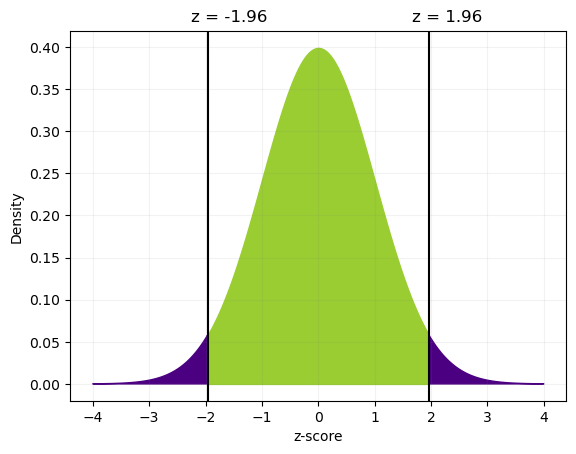

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# x values
x = np.linspace(-4, 4, 1000)

# standard normal pdf values
pdf = norm.pdf(x, 0, 1)

# z cutoff
z_l = -1.96
z_u = 1.96

# plot shaded areas
plt.grid(c = 'gray', alpha = 0.1)
plt.fill_between(x, pdf, where=((x <= z_l) | (x >= z_u)), color='indigo')  # left shaded region
plt.fill_between(x, pdf, where=((x > z_l) & (x < z_u)), color='yellowgreen')  # right shaded region

# vertical line at z
plt.axvline(z_l, color='black')
plt.axvline(z_u, color='black')

# annotation text
plt.text(z_l - 0.3, 0.43, 'z = ' + str(z_l), fontsize=12)
plt.text(z_u - 0.3, 0.43, 'z = ' + str(z_u), fontsize=12)

# axis labels
plt.xlabel('z-score')
plt.ylabel('Density')

plt.show()
